In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
import os
from IPython.display import display,Markdown

# **CONCLUSION**
An analysis of New York’s mobility ecosystem reveals a highly fragmented and specialized market. There is no single "clear winner"; instead, various services have carved out specific niches.\
Yellow Taxis endure as a convenient option for business travel, commanding higher fares for quick, short trips within Manhattan during the workweek. Meanwhile, FHVs (such as Uber and Lyft) have solved the "last-mile" and residential mobility challenge; they dominate weekends and capture demand in the outer boroughs—particularly the Bronx and Brooklyn—outperforming even Green Taxis, whose impact is largely confined to specific border areas like Harlem and western Queens.\
***Actionable Insight:***
- To maximize efficiency, the optimal transport model suggests that users should rely on Yellow Taxis for quick, executive-style trips within Manhattan on weekdays (where the average ride lasts 14 minutes) and turn to FHVs for longer journeys, weekend outings, and travel to or from the outer boroughs. For drivers, the key to profitability lies in positioning themselves in Manhattan during the week (Yellow Taxis) and shifting to residential areas on weekends (FHVs).

In [2]:
pd.set_option('display.max_columns', None)

## CONFIGURATION OF THE AI MODEL

In [3]:
api_key=os.environ.get('GOOGLE_API_KEY')
llm=ChatGoogleGenerativeAI(model='gemini-2.5-flash',temperature=0.3)

## IMPORTING OF THE DATAFRAMES

In [4]:
df_fhv=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/fhv_table.csv')
df_fhv.head(5)

,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag,year,month,totalDuration
0,B00821,2019-01-01T00:23:42.000Z,2019-01-01T00:42:51.000Z,NaN,265.0,NaN,2019,1,19
1,B00856,2019-01-01T00:16:19.000Z,2019-01-01T00:22:38.000Z,NaN,265.0,NaN,2019,1,6
2,B00887,2019-01-01T00:48:29.000Z,2019-01-01T01:06:21.000Z,NaN,265.0,NaN,2019,1,18
3,B01239,2019-01-01T00:45:32.000Z,2019-01-01T01:01:02.000Z,NaN,265.0,NaN,2019,1,16
4,B01726,2019-01-01T00:29:46.000Z,2019-01-01T00:32:51.000Z,NaN,265.0,NaN,2019,1,3


In [5]:
df_fhvhv=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/fhvhv_table.csv')
df_fhvhv.head(5)

,hvfhs_license_num,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag,month,totalDuration
0,HV0003,B02877,2019-10-01T00:44:38.000Z,2019-10-01T00:58:26.000Z,108,67,1.0,10,14
1,HV0003,B02682,2019-10-01T00:44:46.000Z,2019-10-01T01:09:23.000Z,100,257,NaN,10,25
2,HV0003,B02876,2019-10-01T00:37:44.000Z,2019-10-01T00:44:59.000Z,260,82,NaN,10,7
3,HV0003,B02764,2019-10-01T00:27:24.000Z,2019-10-01T00:41:40.000Z,37,61,NaN,10,14
4,HV0003,B02884,2019-10-01T00:27:25.000Z,2019-10-01T00:39:52.000Z,36,37,NaN,10,12


In [6]:
df_green=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/green_table.csv')
df_green.head(5)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration
0,2.0,2019-01-01T00:44:28.000Z,2019-01-01T00:50:10.000Z,1,181,228,1,1.08,6.0,0.5,0.5,0.00,0.0,0.3,7.30,5,1.0,NaN,1,6
1,2.0,2019-01-01T00:20:51.000Z,2019-01-01T00:29:36.000Z,1,41,74,1,0.93,7.0,0.5,0.5,0.00,0.0,0.3,8.30,5,1.0,NaN,1,9
2,2.0,2019-01-01T00:10:00.000Z,2019-01-01T00:22:54.000Z,1,97,80,1,3.44,13.5,0.5,0.5,2.96,0.0,0.3,17.76,1,1.0,NaN,1,12
3,1.0,2019-01-01T00:48:22.000Z,2019-01-01T00:50:08.000Z,1,49,49,1,0.40,3.5,0.5,0.5,1.88,0.0,0.3,6.68,1,1.0,NaN,1,2
4,2.0,2019-01-01T01:53:22.000Z,2019-01-01T02:14:06.000Z,1,25,79,2,3.94,16.5,0.5,0.5,2.50,0.0,0.3,20.30,1,1.0,NaN,1,21


In [7]:
df_yellow=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/yellow_table.csv')
df_yellow.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration
0,1.0,2019-03-01T00:08:38.000Z,2019-03-01T00:21:01.000Z,1.0,2.30,1.0,232,90,2.0,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13
1,1.0,2019-03-01T00:06:19.000Z,2019-03-01T00:12:08.000Z,1.0,1.10,1.0,229,230,1.0,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6
2,1.0,2019-03-01T00:30:06.000Z,2019-03-01T00:37:03.000Z,2.0,0.40,1.0,211,148,1.0,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7
3,2.0,2019-03-01T00:58:00.000Z,2019-03-01T01:21:28.000Z,2.0,5.91,1.0,48,87,2.0,20.5,0.5,0.5,0.00,0.0,0.3,24.30,2.5,3,23
4,1.0,2019-03-01T00:00:47.000Z,2019-03-01T00:09:24.000Z,1.0,1.40,1.0,162,164,2.0,7.5,3.0,0.5,0.00,0.0,0.3,11.30,2.5,3,9


In [159]:
df_yellow_total['extra'].value_counts()

extra
0.00    282845
0.50    156849
2.50    133975
1.00     88110
3.00     71311
3.50     43554
4.50      2568
2.00         4
3.73         4
0.11         1
Name: count, dtype: int64

# **DATASET ANALYSIS**

## **YELLOW TABLE ANALYSIS**

In [8]:
df_yellow.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration
0,1.0,2019-03-01T00:08:38.000Z,2019-03-01T00:21:01.000Z,1.0,2.30,1.0,232,90,2.0,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13
1,1.0,2019-03-01T00:06:19.000Z,2019-03-01T00:12:08.000Z,1.0,1.10,1.0,229,230,1.0,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6
2,1.0,2019-03-01T00:30:06.000Z,2019-03-01T00:37:03.000Z,2.0,0.40,1.0,211,148,1.0,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7
3,2.0,2019-03-01T00:58:00.000Z,2019-03-01T01:21:28.000Z,2.0,5.91,1.0,48,87,2.0,20.5,0.5,0.5,0.00,0.0,0.3,24.30,2.5,3,23
4,1.0,2019-03-01T00:00:47.000Z,2019-03-01T00:09:24.000Z,1.0,1.40,1.0,162,164,2.0,7.5,3.0,0.5,0.00,0.0,0.3,11.30,2.5,3,9


In [9]:
df_yellow.isnull().sum()

VendorID                 2300
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          2300
trip_distance               0
RatecodeID               2300
PULocationID                0
DOLocationID                0
payment_type             2300
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge        0
month                       0
totalDuration               0
dtype: int64

In [10]:
df_yellow.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration
count,783459.000000,783459.000000,785759.000000,783459.000000,785759.000000,785759.000000,783459.000000,785759.000000,785759.000000,785759.000000,785759.000000,785759.000000,785759.000000,785759.000000,785759.000000,785759.000000,785759.000000
mean,1.646649,1.566230,3.051428,1.046865,163.048464,161.123857,1.281156,13.268848,1.139330,0.497695,2.214140,0.383257,0.299964,19.225911,2.212046,6.681514,18.267454
std,0.492841,1.210026,3.958622,0.615424,65.910108,70.139988,0.465095,11.743155,1.265881,0.033949,2.743924,1.653223,0.003281,14.522768,0.798103,3.323718,70.509123
min,1.000000,0.000000,0.010000,1.000000,1.000000,1.000000,1.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.310000,0.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,114.000000,107.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,11.300000,2.500000,4.000000,7.000000
50%,2.000000,1.000000,1.660000,1.000000,162.000000,162.000000,1.000000,9.500000,0.500000,0.500000,1.920000,0.000000,0.300000,14.760000,2.500000,7.000000,11.000000
75%,2.000000,2.000000,3.100000,1.000000,233.000000,233.000000,2.000000,15.000000,2.500000,0.500000,2.960000,0.000000,0.300000,20.760000,2.500000,10.000000,19.000000
max,4.000000,7.000000,124.840000,99.000000,265.000000,265.000000,4.000000,563.000000,87.560000,1.440000,378.100000,98.190000,0.300000,760.020000,2.750000,12.000000,1440.000000


In [11]:
df_yellow.fillna({'passenger_count':1,'RatecodeID':99,'payment_type':5},inplace=True)

In [12]:
df_yellow.isnull().sum()

VendorID                 2300
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count             0
trip_distance               0
RatecodeID                  0
PULocationID                0
DOLocationID                0
payment_type                0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge        0
month                       0
totalDuration               0
dtype: int64

In [13]:
df_yellow['tpep_pickup_datetime']=pd.to_datetime(df_yellow['tpep_pickup_datetime'],format='mixed')
df_yellow['tpep_dropoff_datetime']=pd.to_datetime(df_yellow['tpep_dropoff_datetime'],format='mixed')

In [14]:
df_yellow=df_yellow.astype({'RatecodeID':'int','passenger_count':'int','payment_type':'int'})

### ANALIZING YELLOW DATAFRAME WITH AI

In [34]:
df_yellow_sample=df_yellow.sample(n=100,random_state=42)
df_yellow_dict=df_yellow_sample.to_dict(orient="records")
template = ChatPromptTemplate.from_messages([
    ("system","""You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."""),
    ("user","""Explain the dataset to me clearly and also tell me what mean all the columns. The dataset is: {dataset}""")
])
chain=template|llm
response=chain.invoke({"dataset":df_yellow_dict})
display(Markdown(response.content))

This dataset contains records of individual taxi trips, likely from New York City, providing detailed information about each ride, its cost, and logistics.

Here's a breakdown of each column:

*   **`VendorID`**: An identifier for the taxi technology provider (e.g., 1 for Creative Mobile Technologies, LLC; 2 for VeriFone Inc.).
*   **`tpep_pickup_datetime`**: The date and time when the passenger was picked up (in UTC).
*   **`tpep_dropoff_datetime`**: The date and time when the passenger was dropped off (in UTC).
*   **`passenger_count`**: The number of passengers in the vehicle for the trip.
*   **`trip_distance`**: The elapsed trip distance in miles reported by the taximeter.
*   **`RatecodeID`**: The final rate code in effect at the end of the trip. Common values include:
    *   1: Standard rate
    *   2: JFK (airport)
    *   3: Newark (airport)
    *   4: Nassau or Westchester
    *   5: Negotiated fare
    *   6: Group ride
*   **`PULocationID`**: A unique identifier for the taxi zone where the trip started (Pickup Location ID).
*   **`DOLocationID`**: A unique identifier for the taxi zone where the trip ended (Dropoff Location ID).
*   **`payment_type`**: A numeric code indicating how the passenger paid for the trip. Common values include:
    *   1: Credit card
    *   2: Cash
    *   3: No charge
    *   4: Dispute
    *   5: Unknown
    *   6: Voided trip
*   **`fare_amount`**: The time-and-distance fare calculated by the meter.
*   **`extra`**: Miscellaneous extras and surcharges. This might include peak-hour or night surcharges.
*   **`mta_tax`**: Metropolitan Transportation Authority tax.
*   **`tip_amount`**: The amount of tip paid by the passenger.
*   **`tolls_amount`**: Total amount of all tolls paid in the trip.
*   **`improvement_surcharge`**: A surcharge for taxi improvements.
*   **`total_amount`**: The total amount charged to the passenger, including all components (fare, extras, taxes, tolls, tips, surcharges).
*   **`congestion_surcharge`**: A surcharge applied for trips within congested areas (e.g., Manhattan south of 96th Street).
*   **`month`**: The month in which the trip occurred, derived from `tpep_pickup_datetime`.
*   **`totalDuration`**: The total duration of the trip in minutes, derived from the difference between `tpep_dropoff_datetime` and `tpep_pickup_datetime`.

**Professional Perspective & Recommendations:**

This dataset is rich for analyzing taxi trip patterns, pricing, and operational efficiency.

1.  **Data Quality Check:**
    *   **`passenger_count`**: Note the presence of `0.0` passenger counts (e.g., row 40, 55). This might indicate data entry errors, non-revenue trips, or specific scenarios like a driver repositioning. Investigate or filter these out for analyses focused on passenger behavior.
    *   **`trip_distance` vs. `totalDuration`**: A `totalDuration` of 1-3 minutes for `trip_distance` values like 0.67 or 1.02 (e.g., row 2, 12) suggests very short, possibly high-speed trips or potential data rounding/truncation. Ensure these derived metrics align logically.
    *   **`total_amount` calculation**: Verify that `total_amount` correctly sums all individual charge components (`fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`). Discrepancies could indicate data errors or unlisted charges.

2.  **Potential Analyses:**
    *   **Demand Analysis**: Analyze `tpep_pickup_datetime`, `PULocationID`, and `DOLocationID` to understand peak hours, popular routes, and demand hot-spots.
    *   **Pricing Strategy**: Evaluate the impact of `RatecodeID`, `congestion_surcharge`, and `extra` charges on `total_amount`.
    *   **Driver Performance/Earnings**: Analyze `tip_amount` and `total_amount` per trip, potentially correlating with `trip_distance` and `totalDuration`.
    *   **Geospatial Analysis**: Map `PULocationID` and `DOLocationID` to actual geographical areas to visualize trip flows and identify underserved or overserved zones.
    *   **Time-Series Analysis**: Use the `month` and datetime columns to identify seasonal trends or changes in trip behavior over time.

This dataset provides a solid foundation for understanding the dynamics of a ride-hailing or taxi service. Addressing data quality concerns early will ensure more robust and reliable insights.

## **EXPLORATORY DATA ANALYSIS (EDA)**

In [15]:
df_yellow.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.30,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.10,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.40,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7
3,2.0,2019-03-01 00:58:00+00:00,2019-03-01 01:21:28+00:00,2,5.91,1,48,87,2,20.5,0.5,0.5,0.00,0.0,0.3,24.30,2.5,3,23
4,1.0,2019-03-01 00:00:47+00:00,2019-03-01 00:09:24+00:00,1,1.40,1,162,164,2,7.5,3.0,0.5,0.00,0.0,0.3,11.30,2.5,3,9


In [16]:
print(f"trip median: {df_yellow['trip_distance'].median()}")
print(f"fare_amount median: {df_yellow['fare_amount'].median()}")
print(f"extra median: {df_yellow['extra'].median()}")
print(f"mta_tax median: {df_yellow['mta_tax'].median()}")
print(f"tip_amount median: {df_yellow['tip_amount'].median()}")
print(f"tolls_amount median: {df_yellow['tolls_amount'].median()}")
print(f"improvement_surcharge median: {df_yellow['improvement_surcharge'].median()}")
print(f"total_amount median: {df_yellow['total_amount'].median()}")
print(f"congestion_surcharge median: {df_yellow['congestion_surcharge'].median()}")
print(f"totalDuration median: {df_yellow['totalDuration'].median()}")

trip median: 1.66
fare_amount median: 9.5
extra median: 0.5
mta_tax median: 0.5
tip_amount median: 1.92
tolls_amount median: 0.0
improvement_surcharge median: 0.3
total_amount median: 14.76
congestion_surcharge median: 2.5
totalDuration median: 11.0


In [17]:
print(df_yellow['PULocationID'].value_counts().head(7))
print()
print(df_yellow['DOLocationID'].value_counts().head(7))

PULocationID
237    34061
161    32360
236    30958
162    28691
186    28218
230    26924
132    25220
Name: count, dtype: int64

DOLocationID
236    32039
161    30619
237    30597
170    24746
230    24443
162    23838
48     21769
Name: count, dtype: int64


In [18]:
print(df_yellow['passenger_count'].value_counts())
print()
print(df_yellow['RatecodeID'].value_counts())
print()
print(df_yellow['payment_type'].value_counts())

passenger_count
1    551043
2    119852
3     33659
5     31772
6     19035
4     16144
0     14253
7         1
Name: count, dtype: int64

RatecodeID
1     758624
2      20285
99      2324
5       2214
3       1712
4        600
Name: count, dtype: int64

payment_type
1    567826
2    211916
3      2793
5      2300
4       924
Name: count, dtype: int64


In [19]:
print(df_yellow['tpep_pickup_datetime'].dt.month.value_counts())
print()
print(df_yellow['tpep_pickup_datetime'].dt.day.value_counts().head(7))

tpep_pickup_datetime
3     77864
5     75161
4     73709
10    71148
2     69540
6     68366
11    68027
12    68017
9     64820
7     62095
8     59359
1     27653
Name: count, dtype: int64

tpep_pickup_datetime
22    27558
23    27086
21    26636
12    26618
13    26539
26    26258
6     26138
Name: count, dtype: int64


In [20]:
df_yellow.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.30,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.10,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.40,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7
3,2.0,2019-03-01 00:58:00+00:00,2019-03-01 01:21:28+00:00,2,5.91,1,48,87,2,20.5,0.5,0.5,0.00,0.0,0.3,24.30,2.5,3,23
4,1.0,2019-03-01 00:00:47+00:00,2019-03-01 00:09:24+00:00,1,1.40,1,162,164,2,7.5,3.0,0.5,0.00,0.0,0.3,11.30,2.5,3,9


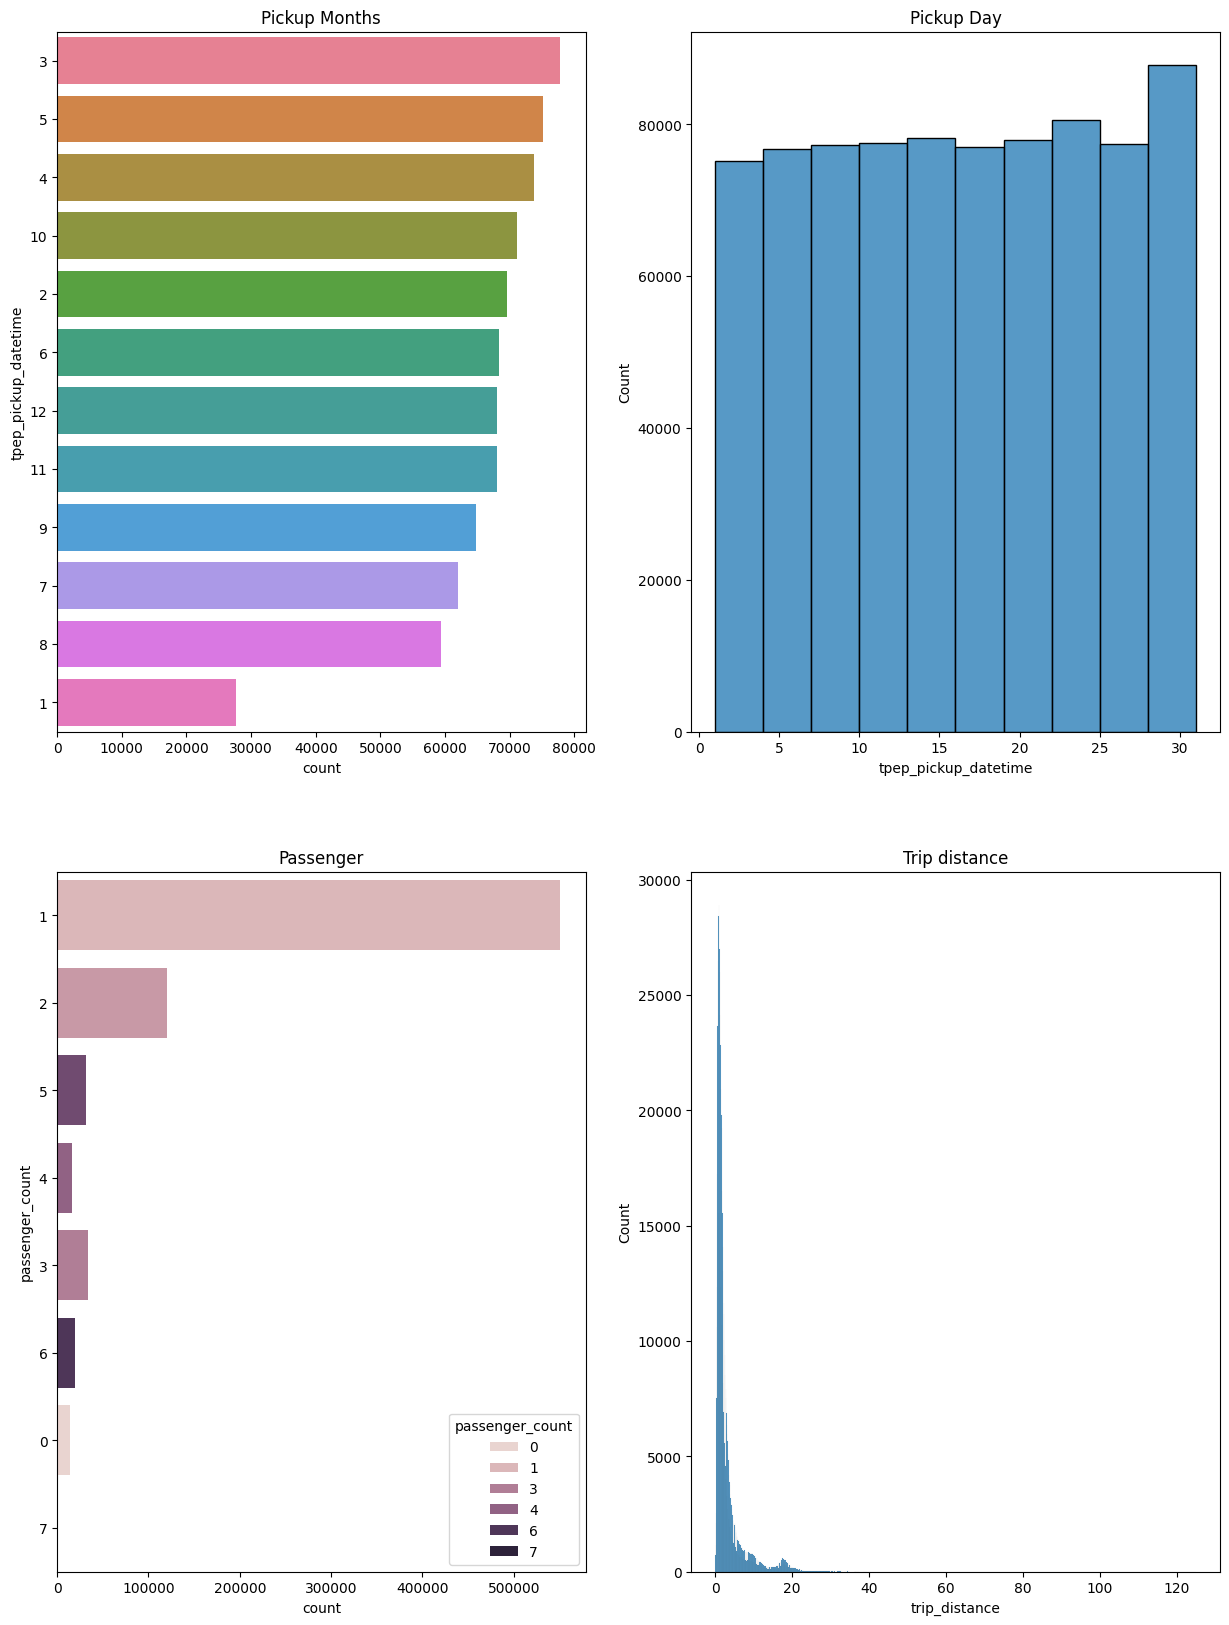

In [21]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('Pickup Months')
sns.countplot(data=df_yellow,y=df_yellow['tpep_pickup_datetime'].dt.month.astype('str'),hue=df_yellow['tpep_pickup_datetime'].dt.month.astype('str'),ax=ax1)

ax2.set_title('Pickup Day')
sns.histplot(data=df_yellow,x=df_yellow['tpep_pickup_datetime'].dt.day,bins=10,ax=ax2)

ax3.set_title('Passenger')
sns.countplot(data=df_yellow,y=df_yellow['passenger_count'].astype('str'),hue='passenger_count',ax=ax3)

ax4.set_title('Trip distance')
sns.histplot(data=df_yellow,x='trip_distance',ax=ax4);

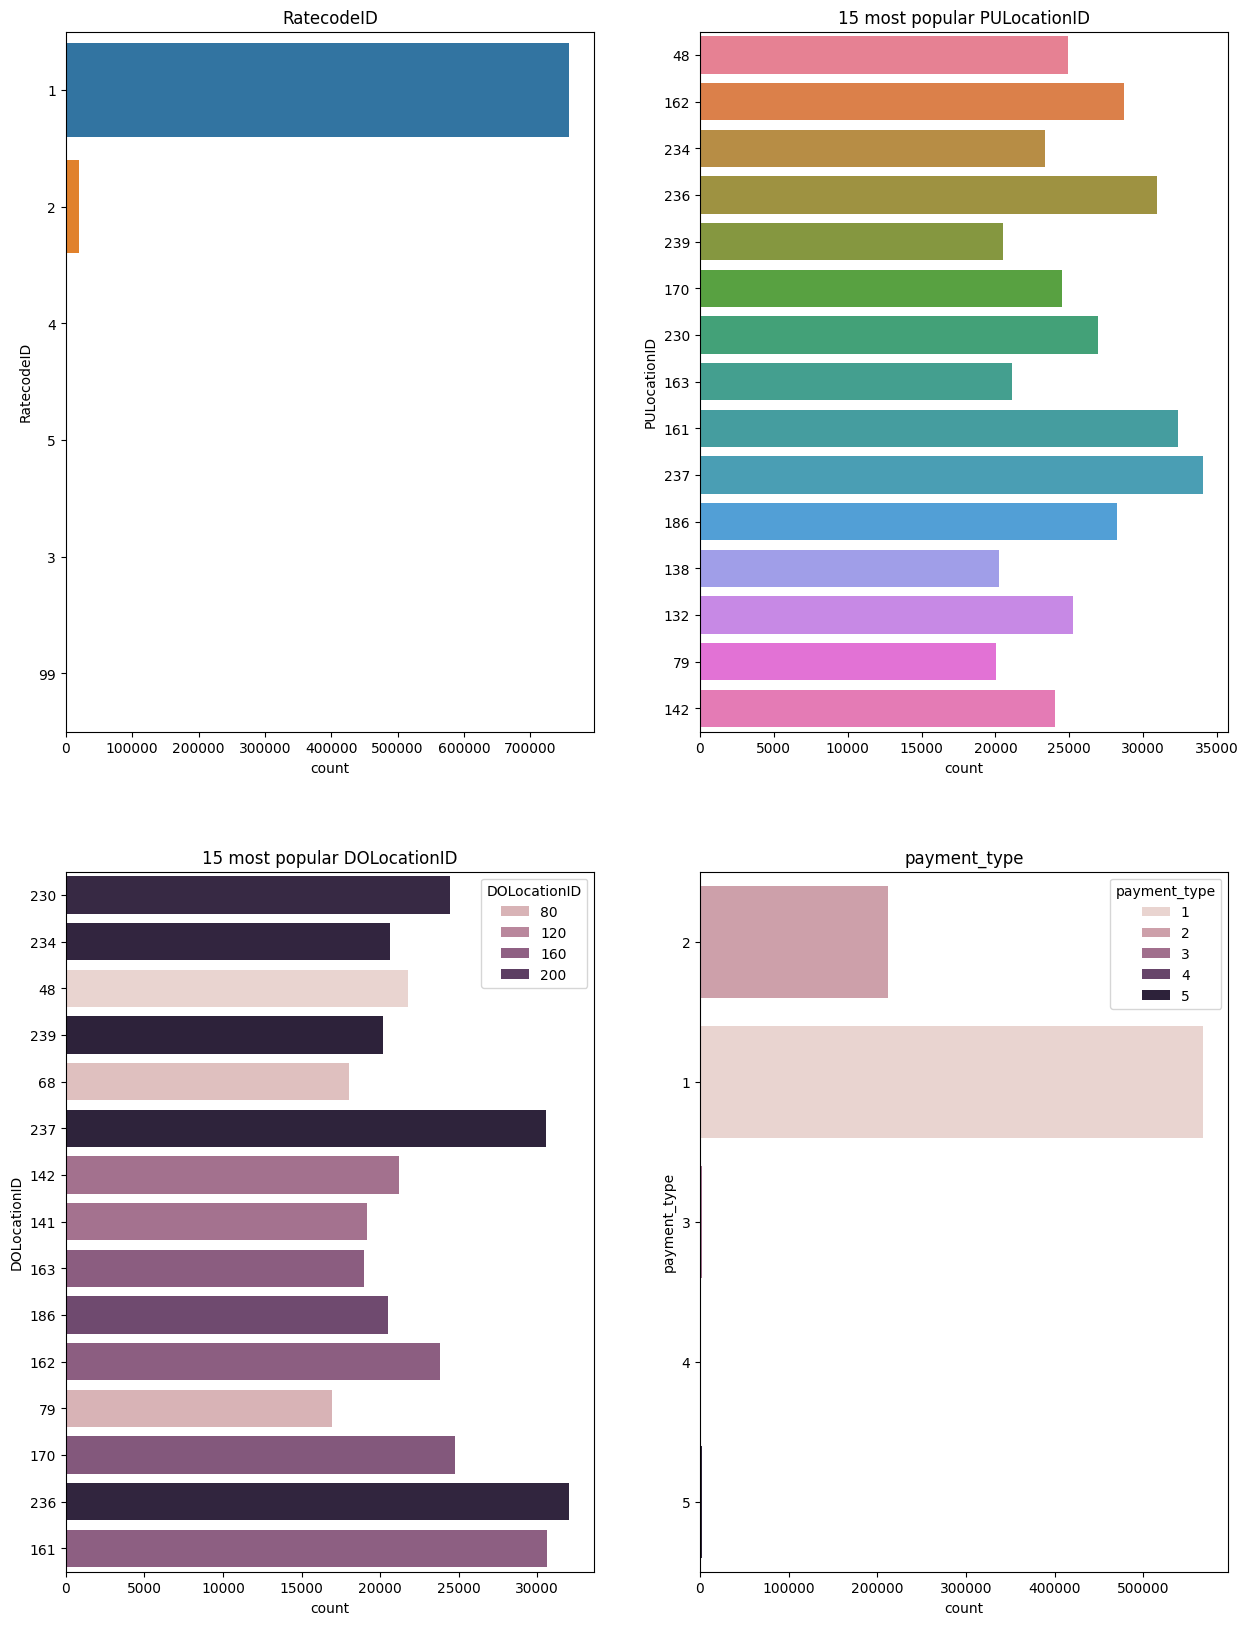

In [22]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('RatecodeID')
sns.countplot(data=df_yellow,y=df_yellow['RatecodeID'].astype('str'),hue=df_yellow['RatecodeID'].astype('str'),ax=ax1)

pulocation=df_yellow['PULocationID'].value_counts().head(15)
df_pulocation=df_yellow.loc[df_yellow['PULocationID'].isin(pulocation.index)]
ax2.set_title('15 most popular PULocationID')
sns.countplot(data=df_pulocation,y=df_pulocation['PULocationID'].astype('str'),hue=df_pulocation['PULocationID'].astype('str'),ax=ax2)

dolocation=df_yellow['DOLocationID'].value_counts().head(15)
df_dolocation=df_yellow.loc[df_yellow['DOLocationID'].isin(dolocation.index)]
ax3.set_title('15 most popular DOLocationID')
sns.countplot(data=df_dolocation,y=df_dolocation['DOLocationID'].astype('str'),hue='DOLocationID',ax=ax3)

ax4.set_title('payment_type')
sns.countplot(data=df_yellow,y=df_yellow['payment_type'].astype('str'),hue='payment_type',ax=ax4);

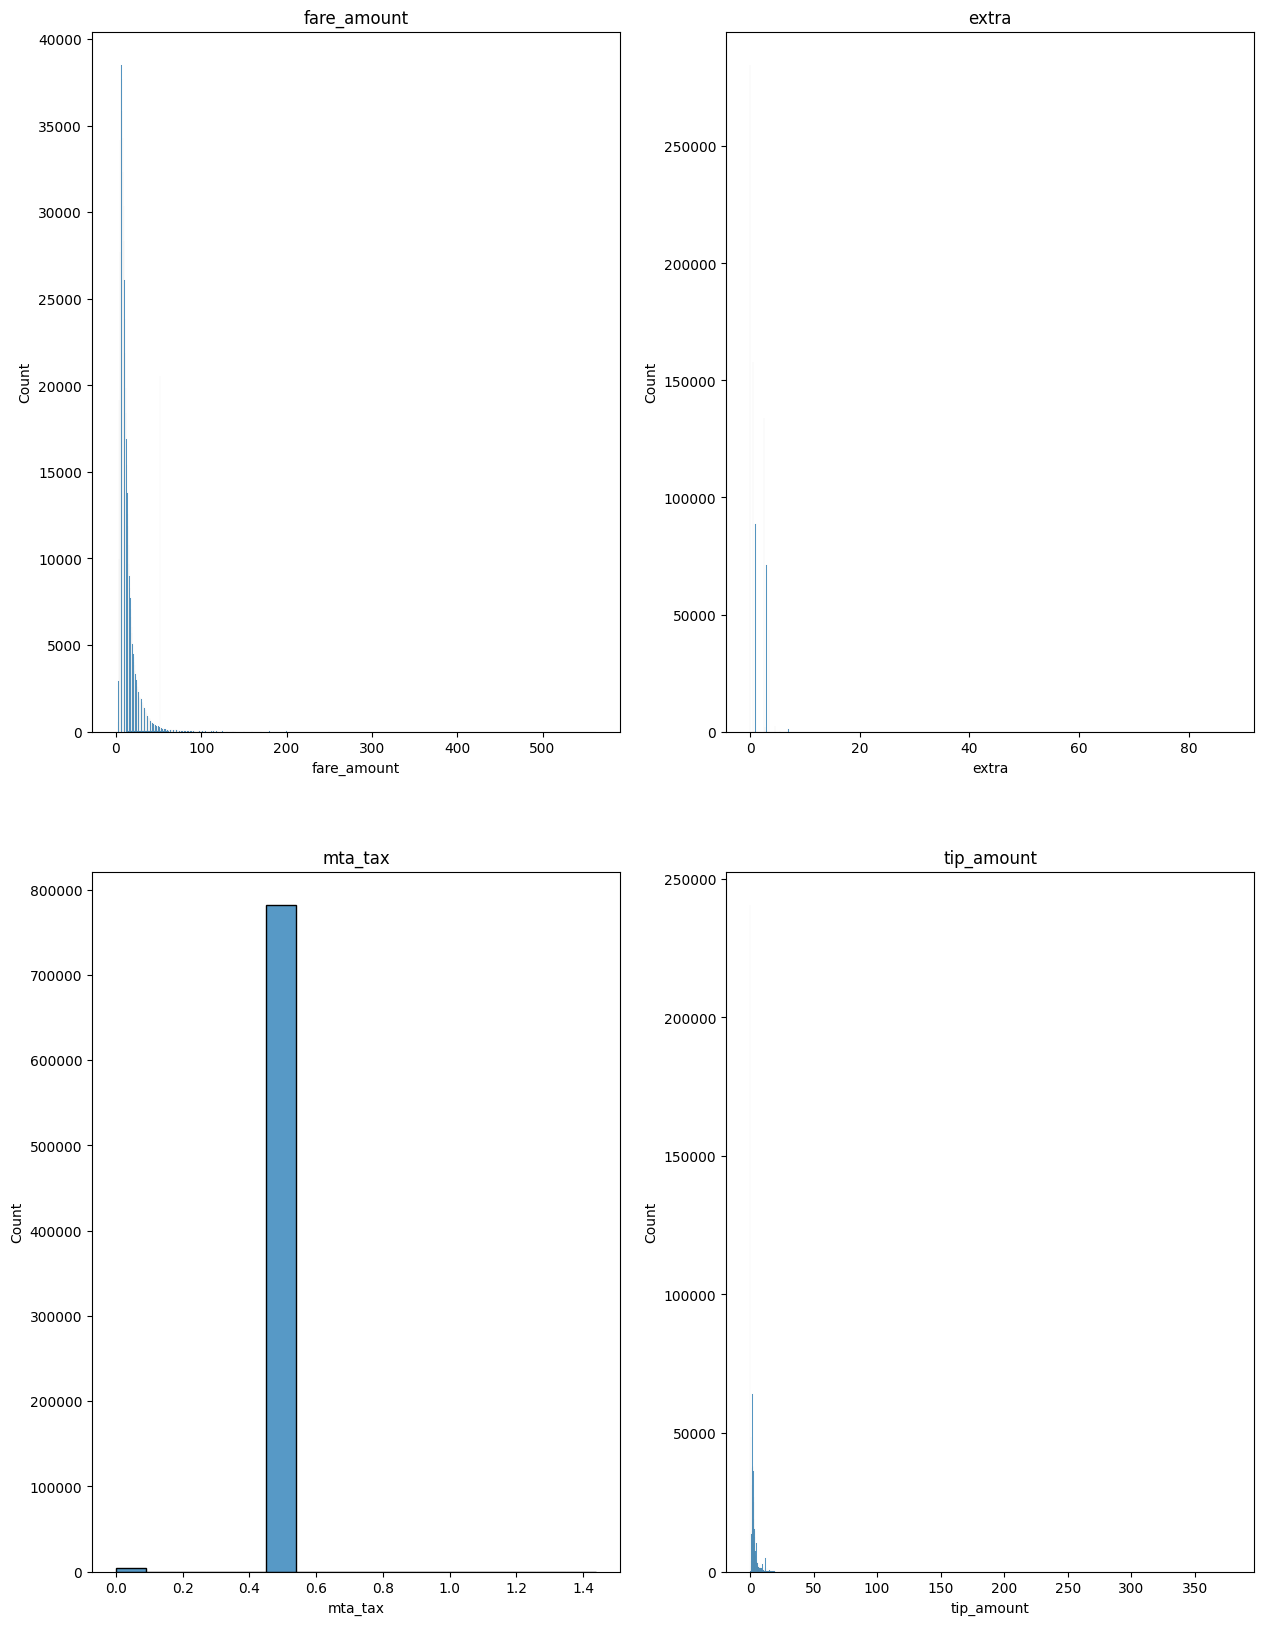

In [23]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('fare_amount')
sns.histplot(data=df_yellow,x='fare_amount',ax=ax1)

ax2.set_title('extra')
sns.histplot(data=df_yellow,x='extra',ax=ax2)

ax3.set_title('mta_tax')
sns.histplot(data=df_yellow,x='mta_tax',bins=16,ax=ax3)

ax4.set_title('tip_amount')
sns.histplot(data=df_yellow,x='tip_amount',ax=ax4);

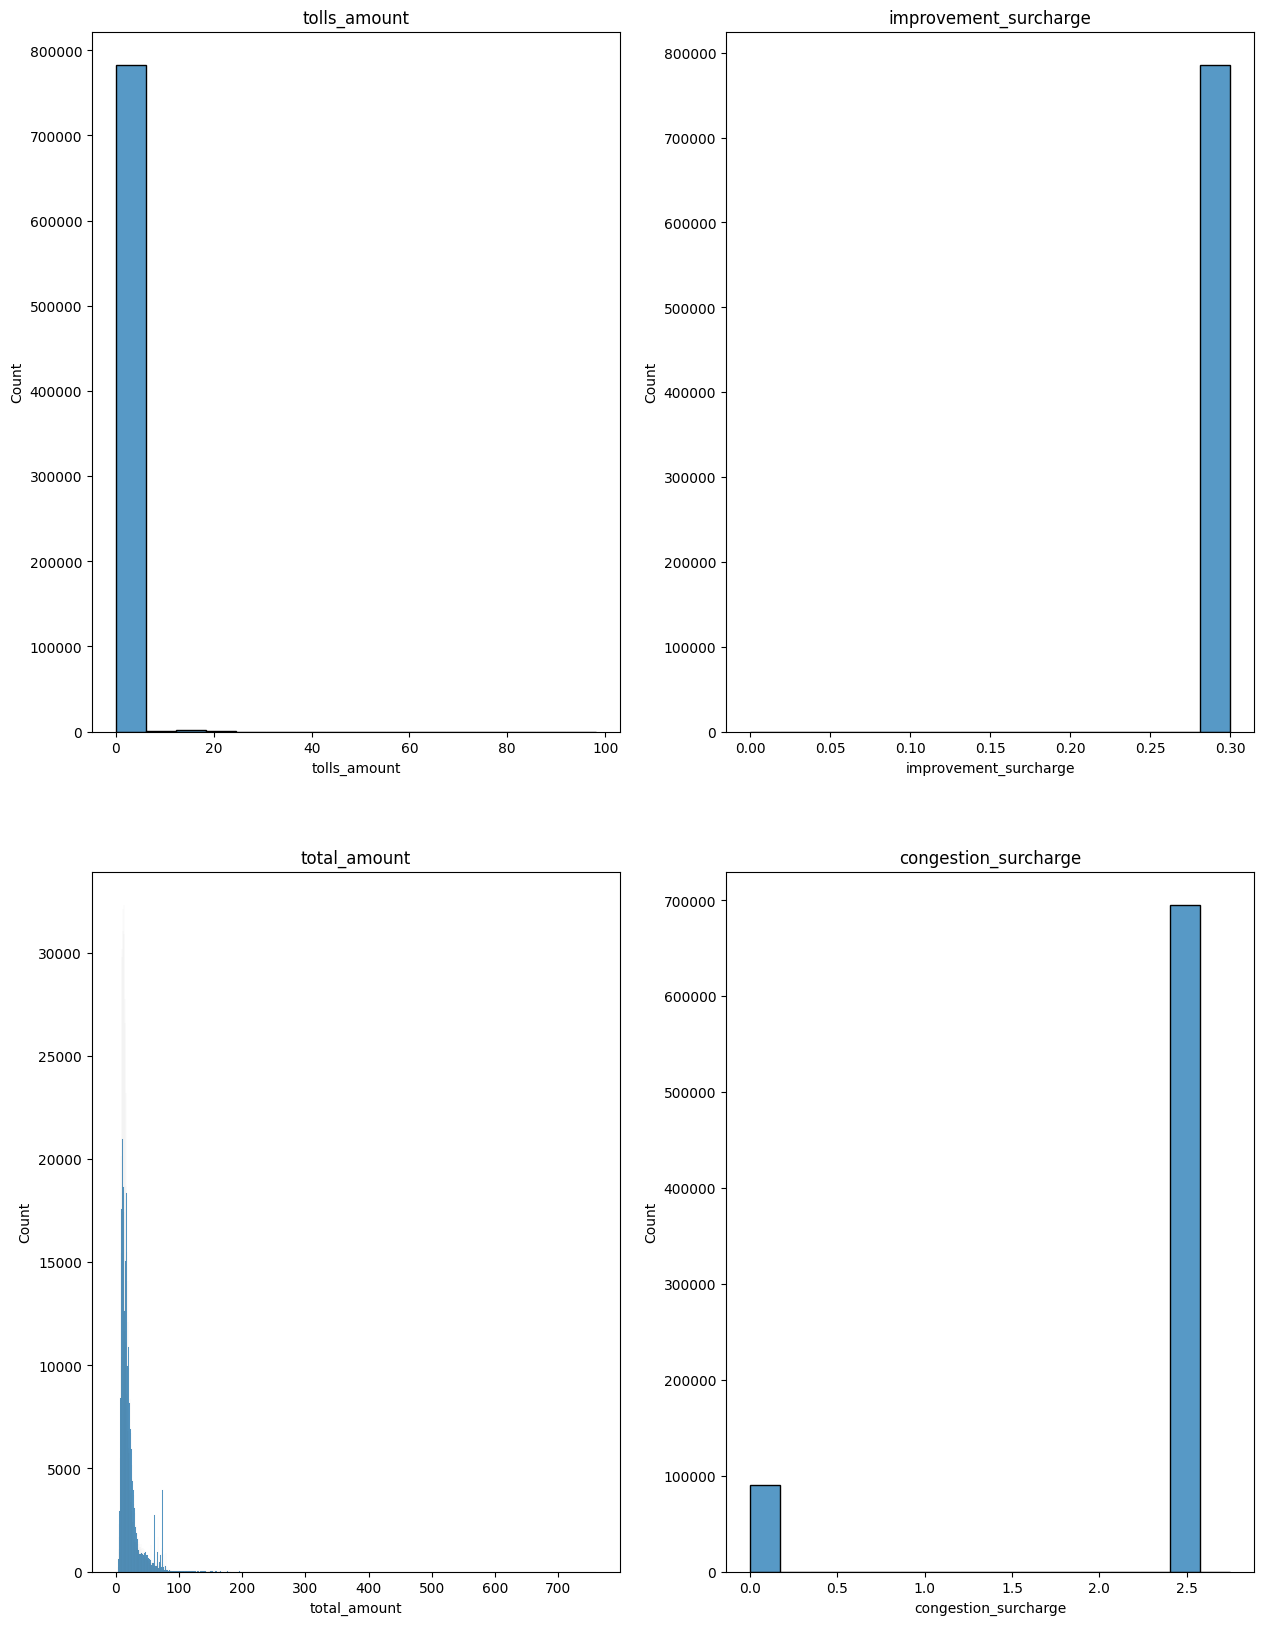

In [24]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('tolls_amount')
sns.histplot(data=df_yellow,x='tolls_amount',bins=16,ax=ax1)

ax2.set_title('improvement_surcharge')
sns.histplot(data=df_yellow,x='improvement_surcharge',bins=16,ax=ax2)

ax3.set_title('total_amount')
sns.histplot(data=df_yellow,x='total_amount',ax=ax3)

ax4.set_title('congestion_surcharge')
sns.histplot(data=df_yellow,x='congestion_surcharge',bins=16,ax=ax4);

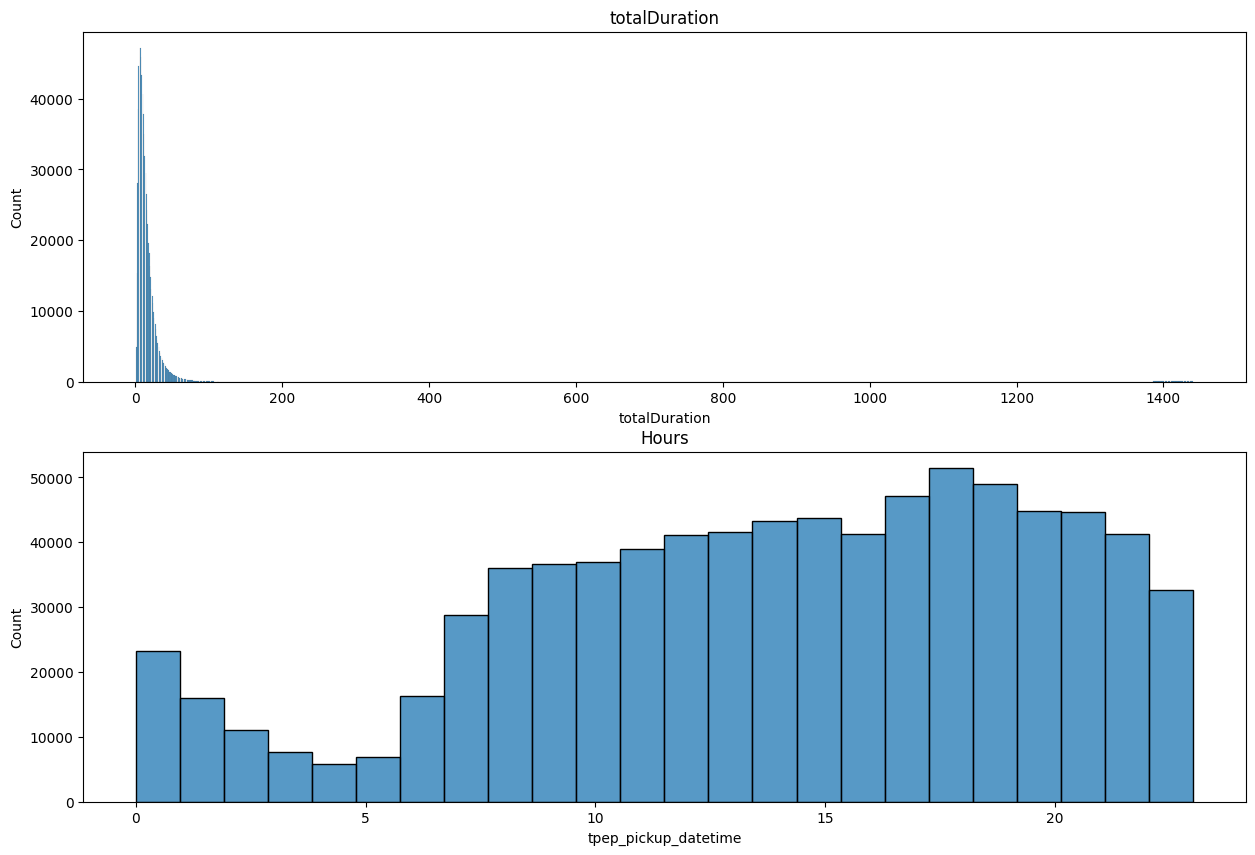

In [25]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(15,10))
ax1=ax[0];ax2=ax[1]

ax1.set_title('totalDuration')
sns.histplot(data=df_yellow,x='totalDuration',ax=ax1)

ax2.set_title('Hours')
sns.histplot(data=df_yellow,x=df_yellow['tpep_pickup_datetime'].dt.hour,bins=24,ax=ax2);

### OUTLIERS

In [26]:
df_yellow.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.30,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.10,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.40,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7
3,2.0,2019-03-01 00:58:00+00:00,2019-03-01 01:21:28+00:00,2,5.91,1,48,87,2,20.5,0.5,0.5,0.00,0.0,0.3,24.30,2.5,3,23
4,1.0,2019-03-01 00:00:47+00:00,2019-03-01 00:09:24+00:00,1,1.40,1,162,164,2,7.5,3.0,0.5,0.00,0.0,0.3,11.30,2.5,3,9


##### TRIP DISTANCE

In [27]:
len(df_yellow.loc[df_yellow['trip_distance'] > 60])


23

In [28]:
df_yellow=df_yellow.loc[df_yellow['trip_distance'] < 60]
len(df_yellow.loc[df_yellow['trip_distance'] > 60])

0

##### TOTAL DURATION

In [29]:
len(df_yellow.loc[df_yellow['totalDuration'] > 550])

1987

In [30]:
df_yellow=df_yellow.loc[df_yellow['totalDuration'] < 550]
len(df_yellow.loc[df_yellow['totalDuration'] > 550])

0

##### FARE AMOUNT

In [31]:
len(df_yellow.loc[df_yellow['fare_amount'] > 200])

47

In [32]:
df_yellow=df_yellow.loc[df_yellow['fare_amount'] < 200]
len(df_yellow.loc[df_yellow['fare_amount'] > 200])

0

##### EXTRA

In [33]:
len(df_yellow.loc[df_yellow['extra'] > 7])


14

In [34]:
df_yellow=df_yellow.loc[df_yellow['extra'] < 7]
len(df_yellow.loc[df_yellow['extra'] > 7])

0

##### MTA TAX

In [35]:
len(df_yellow.loc[df_yellow['mta_tax'] > 0.6])

4

In [36]:
df_yellow=df_yellow.loc[df_yellow['mta_tax'] < 0.6]
len(df_yellow.loc[df_yellow['mta_tax'] > 0.6])


0

##### TIP AMOUNT

In [37]:
len(df_yellow.loc[df_yellow['tip_amount'] > 25])

289

In [38]:
df_yellow=df_yellow.loc[df_yellow['tip_amount'] < 25]
len(df_yellow.loc[df_yellow['tip_amount'] > 25])

0

##### TOLLS AMOUNT

In [39]:
len(df_yellow.loc[df_yellow['tolls_amount'] > 20])


205

In [40]:
df_yellow=df_yellow.loc[df_yellow['tolls_amount'] < 20]
len(df_yellow.loc[df_yellow['tolls_amount'] > 20])

0

##### IMPROVEMENT SURCHARGE

In [41]:
len(df_yellow.loc[df_yellow['improvement_surcharge'] < 0.30])

89

In [42]:
df_yellow=df_yellow.loc[df_yellow['improvement_surcharge'] >= 0.3]
len(df_yellow.loc[df_yellow['improvement_surcharge'] < 0.30])

0

##### TOTAL AMOUNT

In [43]:
len(df_yellow.loc[df_yellow['total_amount'] > 120])


355

In [44]:
df_yellow=df_yellow.loc[df_yellow['total_amount'] < 120]
len(df_yellow.loc[df_yellow['total_amount'] > 120])

0

## **MULTIVARIABLE DATA ANALYSIS**

#### ¿Which are the hours and days of the week with more trips?
- **Days of the week with more trips:** *Thursday at the first place, following by Friday and Wednesday. The day with less trips was Sunday.*
- **Hours with more trips:** *There were more concentration of trips around 15-18 hours (3-6PM)*
#### ¿How is the demand between the laboral days and weekends?
- **Weekends:** *There are more concentrations of thrips during the early morning instead of the work days. But the distribution of the trips around the day is almost the same as the work days.*
- **Laboral days:** *Laboral days have more quantity of trips along the day, but the the distribution of the trips along the day is the same like weekends.*
#### ¿Which are the months with more concentration of trips?
**March,May and April were the months with more concentration of trips along the year.**

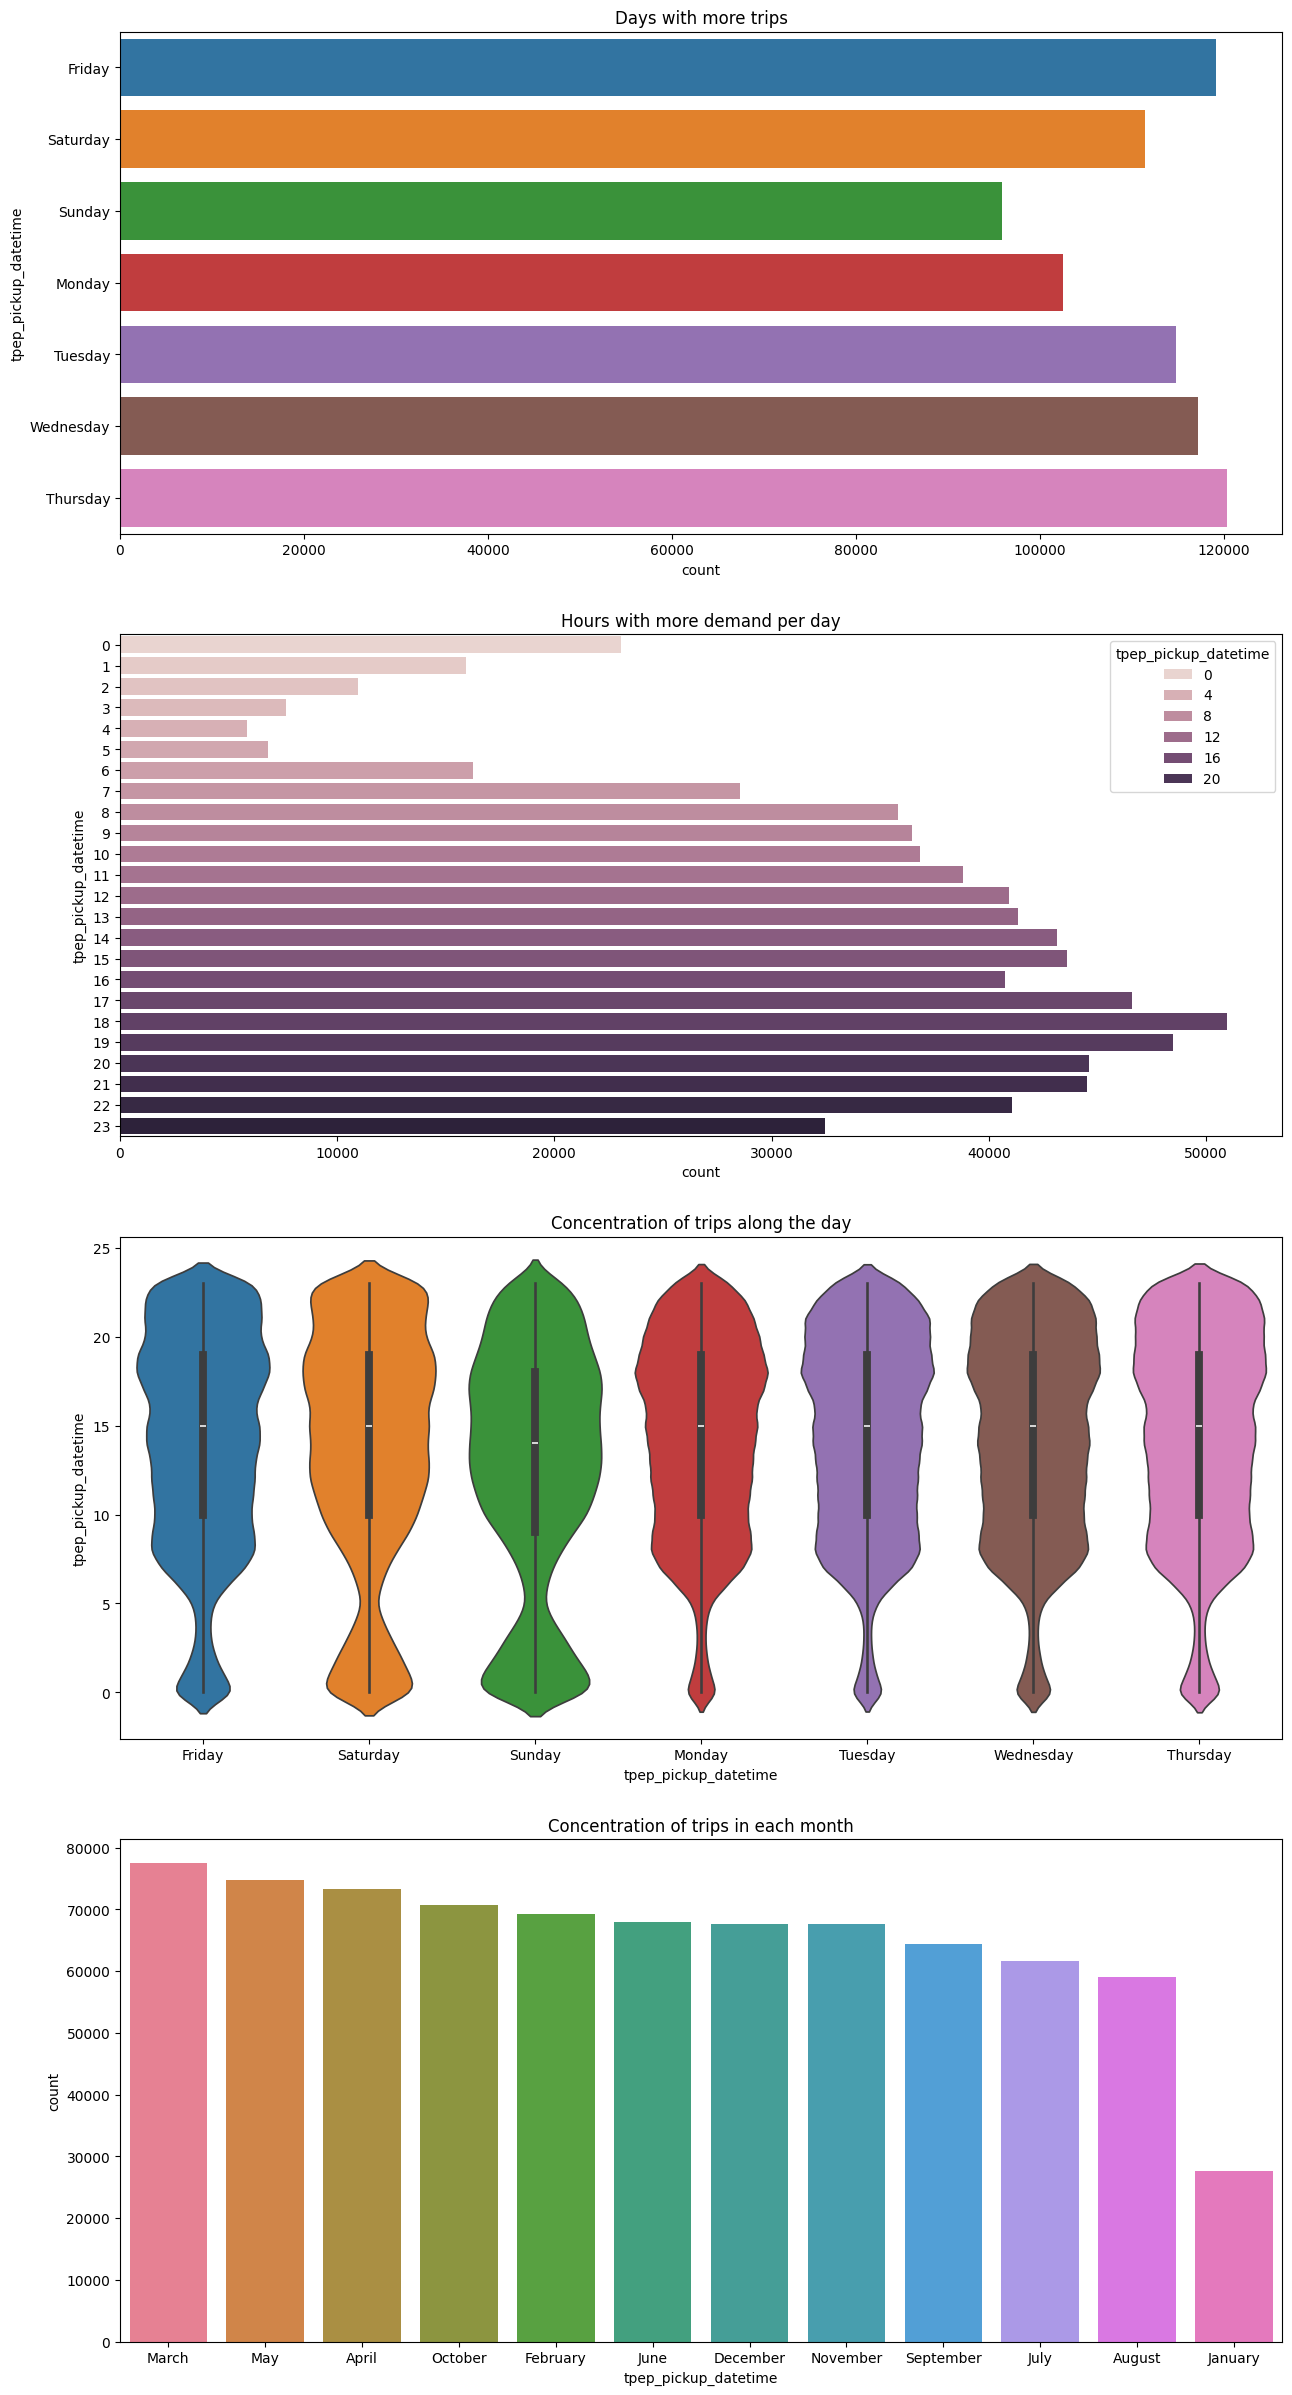

In [45]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3]

ax1.set_title('Days with more trips')
sns.countplot(data=df_yellow,y=df_yellow['tpep_pickup_datetime'].dt.day_name(),hue=df_yellow['tpep_pickup_datetime'].dt.day_name(),ax=ax1)

ax2.set_title('Hours with more demand per day')
sns.countplot(data=df_yellow,y=df_yellow['tpep_pickup_datetime'].dt.hour,hue=df_yellow['tpep_pickup_datetime'].dt.hour,ax=ax2)

ax3.set_title('Concentration of trips along the day')
sns.violinplot(data=df_yellow,x=df_yellow['tpep_pickup_datetime'].dt.day_name(),y=df_yellow['tpep_pickup_datetime'].dt.hour,
            hue=df_yellow['tpep_pickup_datetime'].dt.day_name(),ax=ax3)

ax4.set_title('Concentration of trips in each month')
sns.countplot(data=df_yellow,x=df_yellow['tpep_pickup_datetime'].dt.month_name(),hue=df_yellow['tpep_pickup_datetime'].dt.month_name(),ax=ax4);

In [46]:
df_yellow.groupby(df_yellow['tpep_pickup_datetime'].dt.month_name())['trip_distance'].mean()

tpep_pickup_datetime
April        2.944457
August       3.128949
December     2.984027
February     2.873768
January      2.750778
July         3.104026
June         3.053977
March        3.002580
May          3.029825
November     2.928337
October      2.992421
September    3.089547
Name: trip_distance, dtype: float64

In [47]:
print(df_yellow['tpep_pickup_datetime'].dt.day_name().value_counts())
print()
print(df_yellow['tpep_pickup_datetime'].dt.hour.value_counts())

tpep_pickup_datetime
Thursday     120386
Friday       119193
Wednesday    117188
Tuesday      114827
Saturday     111438
Monday       102589
Sunday        95910
Name: count, dtype: int64

tpep_pickup_datetime
18    50971
19    48505
17    46573
20    44618
21    44504
15    43582
14    43160
13    41364
22    41052
12    40931
16    40769
11    38835
10    36840
9     36483
8     35812
23    32442
7     28555
0     23050
6     16261
1     15940
2     10950
3      7668
5      6836
4      5830
Name: count, dtype: int64


In [48]:
df_yellow['tpep_pickup_datetime'].dt.hour.median()

np.float64(15.0)

### **¿What are the 10 most crowded places?**
- **Pickup zones:** *Upper East Side South', 'Midtown Center', 'Upper East Side North','Midtown East', 'Penn Station/Madison Sq West',
       'Times Sq/Theatre District', 'Clinton East', 'JFK Airport','Murray Hill', 'Lincoln Square East', 'Union Sq', 'Midtown North',
       'Upper West Side South', 'LaGuardia Airport', 'East Village'.*
- **Dropoff zones:** *'Upper East Side North', 'Midtown Center', 'Upper East Side South','Murray Hill', 'Times Sq/Theatre District', 'Midtown East',
       'Clinton East', 'Lincoln Square East', 'Union Sq','Penn Station/Madison Sq West', 'Upper West Side South',
       'Lenox Hill West', 'Midtown North', 'East Chelsea', 'East Village'.*

In [49]:
df_taxizone=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/taxi_zone.csv')
df_taxizone.head(5)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [50]:
df_yellow_total=pd.merge(
    df_yellow,
    df_taxizone[['LocationID','Zone','Borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='inner').rename(columns={'Zone':'PULocation_zone','Borough':'PULocation_borough'})
df_yellow_total=df_yellow_total.drop(columns=['LocationID'])
df_yellow_total.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan


In [51]:
df_yellow_total=pd.merge(df_yellow_total,df_taxizone[['LocationID','Zone','Borough']],
                        left_on='DOLocationID',
                        right_on='LocationID',
                        how='inner').rename(columns={'Zone':'DOLocation_zone','Borough':'DOLocation_borough'})
df_yellow_total=df_yellow_total.drop(columns=['LocationID'])
df_yellow_total.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan,Flatiron,Manhattan
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan


In [52]:
# PICKUP ZONE
pickup_zone=df_yellow_total['PULocation_zone'].value_counts().head(15)

#PICKUP BOROUGH
pickup_borough=df_yellow_total['PULocation_borough'].value_counts()

# DROPOFF ZONE
dropoff_zone=df_yellow_total['DOLocation_zone'].value_counts().head(15)

# DROPOFF BOROUGH
dropoff_borough=df_yellow_total['DOLocation_borough'].value_counts()

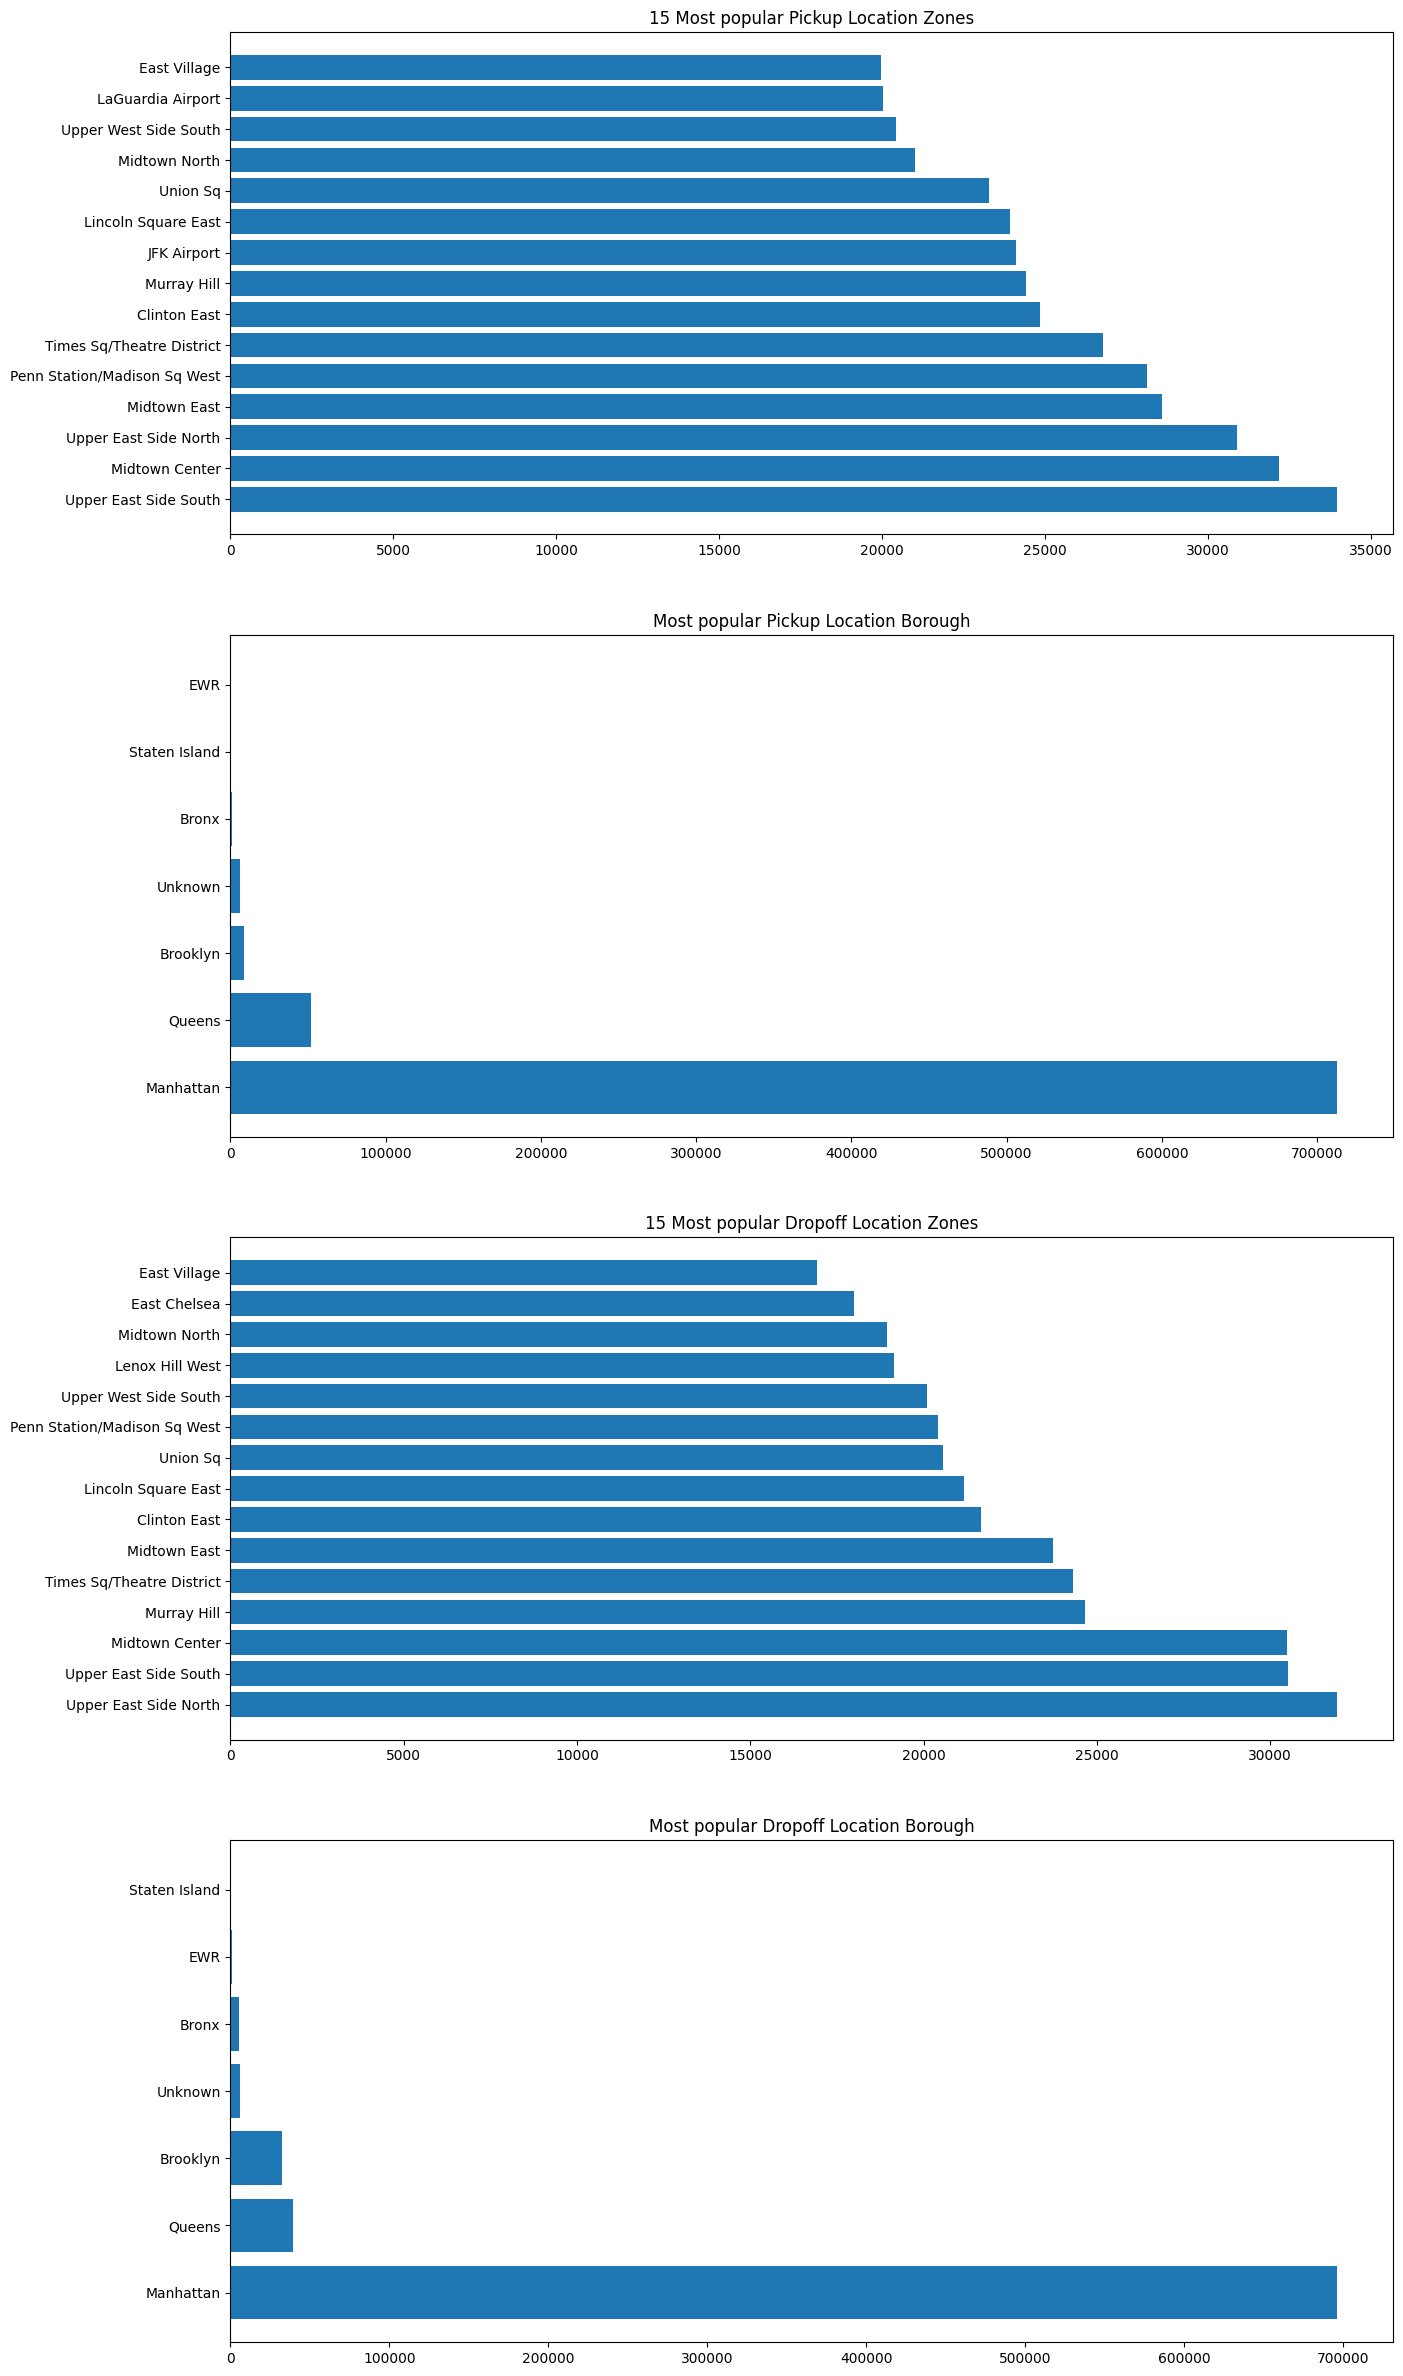

In [53]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(15,30))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3]

ax1.set_title('15 Most popular Pickup Location Zones')
ax1.barh(pickup_zone.index,width=pickup_zone.values)

ax2.set_title('Most popular Pickup Location Borough')
ax2.barh(pickup_borough.index,width=pickup_borough.values)

ax3.set_title('15 Most popular Dropoff Location Zones')
ax3.barh(dropoff_zone.index,width=dropoff_zone.values)

ax4.set_title('Most popular Dropoff Location Borough')
ax4.barh(dropoff_borough.index,width=dropoff_borough.values);

### **¿Which routes had the most heavy traffic?**
- **Concurred routes (most popular routes):** *The most concurred routes were:'Upper East Side South'-'Upper East Side North','Upper East Side North'-'Upper East Side South','Upper East Side North'-'Upper East Side North','Upper East Side South'-'Upper East Side South','Upper West Side South'-'Upper West Side North','Upper West Side South'-'Lincoln Square East','Upper East Side South'-'Midtown East','Upper East Side South'-'Midtown Center','Lincoln Square East'-'Upper West Side South'. This is interesting because although these had a lot of concurrency by the users, this don't mean that they were the slowest routes.*
- **The slowest routes:** *The 3 routes with more traffic or slowest were 'Central Harlem North' to 'Manhattanville' with 8.8 miles/hour, followed by 'Garment District' to 'Stuy Town/Peter Cooper Village' with 9 miles/hour,'East Village' to 'Downtown Brooklyn/MetroTech' with 12.5 miles/hour.*

In [54]:
df_yellow_total['miles_hour']=(df_yellow_total['trip_distance'])/(df_yellow_total['totalDuration']/60)
df_yellow_total.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough,miles_hour
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan,Flatiron,Manhattan,10.615385
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan,11.000000
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan,3.428571


In [55]:
# LUGARES MAS CONCURRIDOS
routes_yellow=df_yellow_total[['PULocation_zone','DOLocation_zone']].value_counts().sort_values(ascending=False)
#routes_yellow=routes_yellow.loc[routes_yellow['count']>50]
routes_yellow=routes_yellow.loc[routes_yellow.values>50]
routes_popular=routes_yellow.head(10)

In [56]:
# RUTAS QUE HICIERON MAS TIEMPO
#time_two=df_yellow_total.loc[df_yellow_total['PULocation_zone'].isin(routes_yellow['PULocation_zone']) & df_yellow_total['DOLocation_zone'].isin(routes_yellow['DOLocation_zone'])]
time_two=df_yellow_total.groupby(['PULocation_zone','DOLocation_zone'])['miles_hour'].mean().sort_values(ascending=True)
time=time_two.loc[routes_yellow.tail(10).index]
time=time.sort_values(ascending=True)
time

PULocation_zone            DOLocation_zone               
Garment District           Stuy Town/Peter Cooper Village     9.069820
Union Sq                   Chinatown                          9.344206
Financial District South   Two Bridges/Seward Park           12.659116
Manhattanville             Upper West Side North             12.804578
West Chelsea/Hudson Yards  Financial District South          12.850672
Midtown East               Steinway                          14.620532
Times Sq/Theatre District  Brooklyn Heights                  15.427310
Battery Park City          Upper East Side South             16.237516
Financial District North   Yorkville East                    20.777569
Financial District South   UN/Turtle Bay South               22.267445
Name: miles_hour, dtype: float64

In [57]:
# RUTAS MAS POPULARES Y EL TIEMPO
popular_time=time_two.loc[routes_popular.index].sort_values(ascending=True)
popular_time

PULocation_zone        DOLocation_zone      
Upper East Side South  Midtown Center            7.327748
                       Midtown East              8.013779
                       Upper East Side South     8.689665
Upper East Side North  Upper East Side South     9.196426
                       Upper East Side North     9.850680
Upper West Side South  Lincoln Square East      10.209294
Lincoln Square East    Upper West Side South    10.598549
Upper East Side South  Upper East Side North    10.648671
NV                     NV                       11.267512
Upper West Side South  Upper West Side North    11.429579
Name: miles_hour, dtype: float64

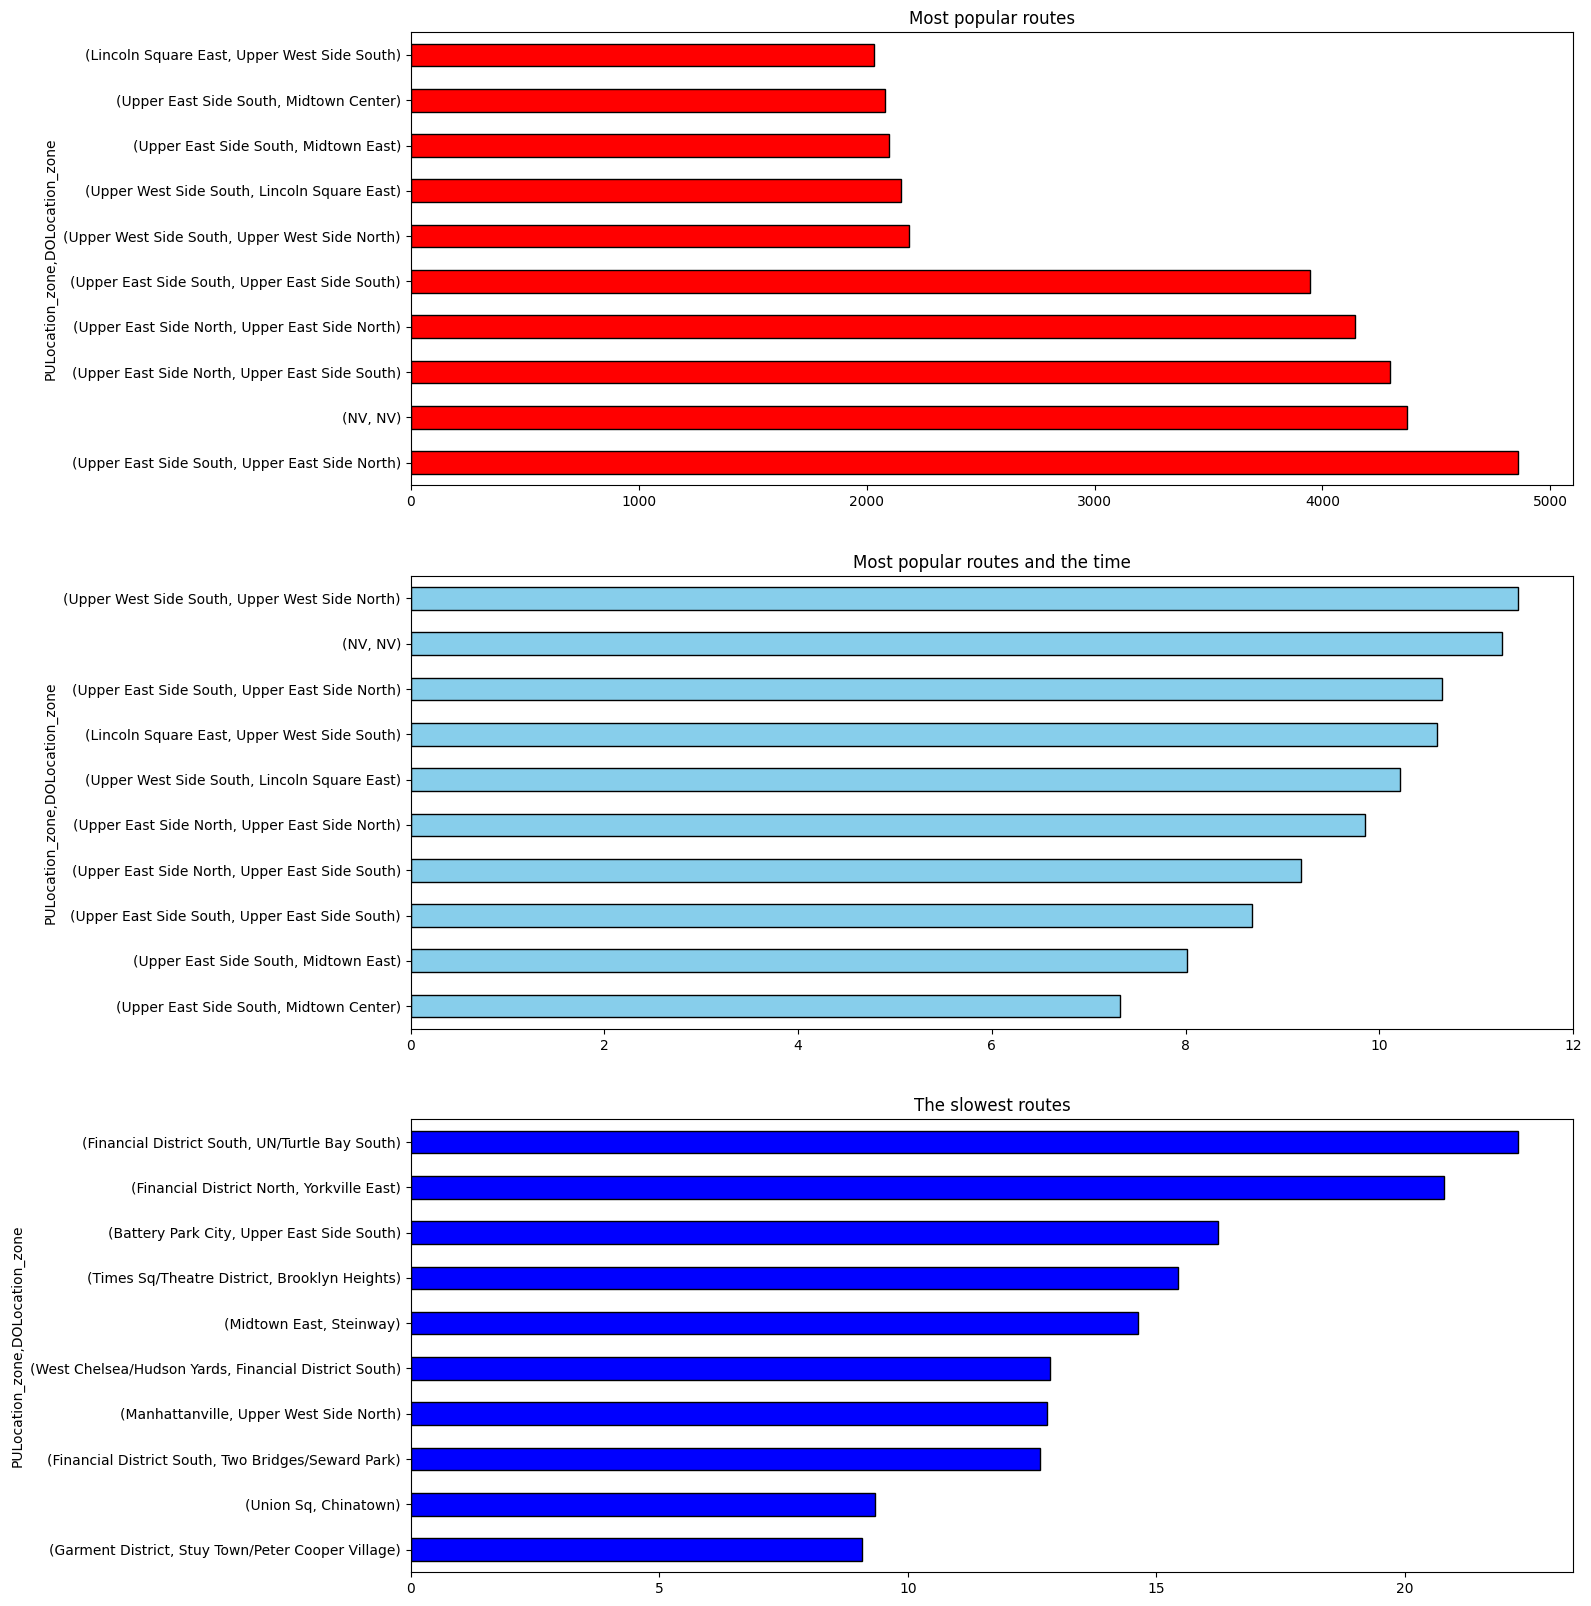

In [58]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,20))
ax1=ax[0];ax2=ax[1];ax3=ax[2]

ax1.set_title('Most popular routes')
routes_popular.plot(kind='barh', color='red', edgecolor='black',ax=ax1)

ax2.set_title('Most popular routes and the time')
popular_time.plot(kind='barh', color='skyblue', edgecolor='black',ax=ax2)

ax3.set_title('The slowest routes')
time.plot(kind='barh', color='blue', edgecolor='black',ax=ax3);

In [59]:
df_velocidades = (
    df_yellow_total
    .groupby(['PULocation_zone', 'DOLocation_zone'])['miles_hour']
    .mean()
    .reset_index(name='velocidad_media')
)

df_top_rutas = (
    df_yellow_total[['PULocation_zone', 'DOLocation_zone']]
    .value_counts()
    .head(15)
    .reset_index(name='total_viajes')
)

resultado = pd.merge(df_top_rutas, df_velocidades, on=['PULocation_zone', 'DOLocation_zone'])
resultado

,PULocation_zone,DOLocation_zone,total_viajes,velocidad_media
0,Upper East Side South,Upper East Side North,4857,10.648671
1,NV,NV,4369,11.267512
2,Upper East Side North,Upper East Side South,4297,9.196426
3,Upper East Side North,Upper East Side North,4143,9.850680
4,Upper East Side South,Upper East Side South,3946,8.689665
5,Upper West Side South,Upper West Side North,2187,11.429579
6,Upper West Side South,Lincoln Square East,2151,10.209294
7,Upper East Side South,Midtown East,2099,8.013779
8,Upper East Side South,Midtown Center,2082,7.327748
9,Lincoln Square East,Upper West Side South,2034,10.598549


### **¿How changed the cost per mile in the different tariff?**
*The concentration of the majority of trips were in 'Standard Rate'. The highest cost was by the 'Standard Rate' with 9 dollars per mile, followed by 'Newark' with 5.7 dollars per mile, 'Negotiated fare' with 5 dollar per mile, 'Nassau or Westchester' with 4.6 dollars per mile and finally 'JFK' with 4 dollars per mile.*

In [60]:
df_rate=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/taxi_rate.csv')
df_rate.head(5)

,RateCodeID,RateCodeDesc
0,1,Standard Rate
1,2,JFK
2,3,Newark
3,4,Nassau or Westchester
4,5,Negotiated fare


In [61]:
df_yellow_total=pd.merge(df_yellow_total,df_rate[['RateCodeID','RateCodeDesc']],how='inner',left_on='RatecodeID',right_on='RateCodeID')

In [62]:
#df_yellow_total=df_yellow_total.drop(columns=['RateCodeDesc_x','RateCodeID_x','RateCodeDesc_y','RateCodeID_y'])
df_yellow_total=df_yellow_total.drop(columns=['RateCodeID'])
df_yellow_total.head(3)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough,miles_hour,RateCodeDesc
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan,Flatiron,Manhattan,10.615385,Standard Rate
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan,11.000000,Standard Rate
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan,3.428571,Standard Rate


In [63]:
df_yellow_total['cost_per_mile']=df_yellow_total['total_amount']/df_yellow_total['trip_distance']

In [64]:
df_yellow_total.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough,miles_hour,RateCodeDesc,cost_per_mile
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan,Flatiron,Manhattan,10.615385,Standard Rate,6.217391
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan,11.000000,Standard Rate,10.681818
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan,3.428571,Standard Rate,24.500000


In [65]:
df_cost_per_mile=df_yellow_total.loc[df_yellow_total['cost_per_mile']<30]

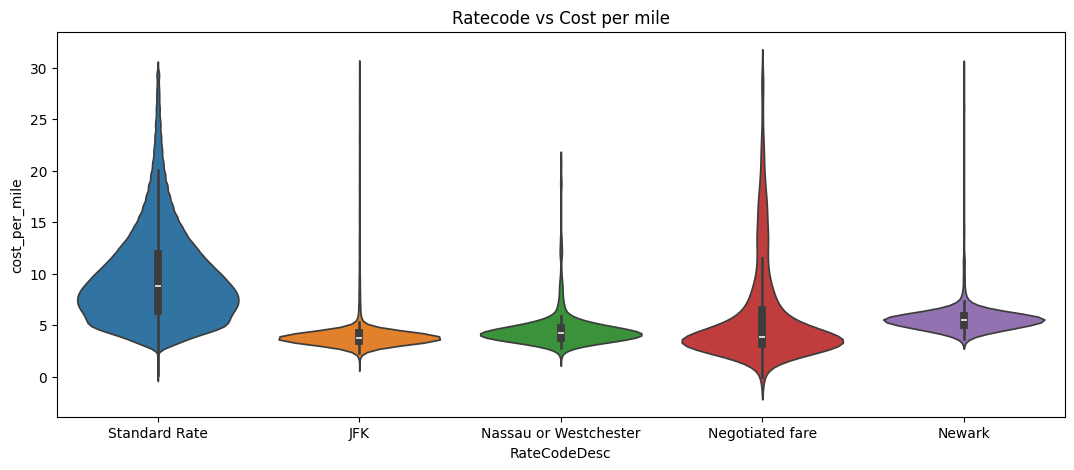

In [66]:
plt.figure(figsize=(13,5))
plt.title('Ratecode vs Cost per mile')
sns.violinplot(data=df_cost_per_mile,x=df_cost_per_mile['RateCodeDesc'].astype('str'),y='cost_per_mile',
               hue=df_cost_per_mile['RateCodeDesc'].astype('str'));

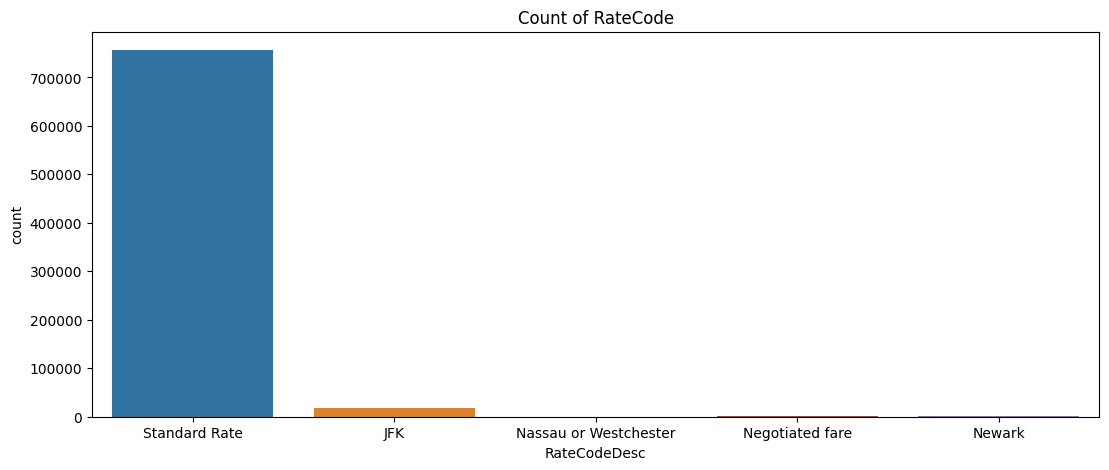

In [67]:
plt.figure(figsize=(13,5))
plt.title('Count of RateCode')
sns.countplot(data=df_yellow_total,x='RateCodeDesc',hue='RateCodeDesc');

In [68]:
display(Markdown("### The cost per mile in the different services"))
print(df_cost_per_mile.groupby('RateCodeDesc')['cost_per_mile'].agg(['mean','median']))

### The cost per mile in the different services

                           mean    median
RateCodeDesc                             
JFK                    4.211742  3.795429
Nassau or Westchester  4.610920  4.241346
Negotiated fare        5.928514  3.821847
Newark                 5.732064  5.518987
Standard Rate          9.677762  8.761905


### **¿What percentage of the total amount represent the tips?**
*The average percentage of the tip (card payment) is: 14.99%*

In [69]:

df_yellow_total['tip_percent'] = np.where(
    df_yellow_total['total_amount'] > 0,
    (df_yellow_total['tip_amount'] / df_yellow_total['total_amount']) * 100,
    0.0
)

df_card_trips = df_yellow_total[
    (df_yellow_total['payment_type'] == 1) & 
    (df_yellow_total['total_amount'] > 0)
]

promedio_propina = df_card_trips['tip_percent'].mean()
display(Markdown(f"#### The average percentage of the tip (card payment) is: *{promedio_propina:.2f}%*"))

#### The average percentage of the tip (card payment) is: *14.99%*

### **¿There are relationship in the time of the day or distance and the tips?**
- **Hour:** *There was relationship between the time of the day and tips. Early in the morning, like before at 6am, the tips were more lower than after 6am and the tips stabilized starting at 10 a.m.*
- **Distance:** *Tips vary according to distance: they were higher for shorter distances and decreased as the distance increased.*

In [70]:

df_tips = df_yellow_total[
    (df_yellow_total['payment_type'] == 1) & 
    (df_yellow_total['fare_amount'] > 0) & 
    (df_yellow_total['trip_distance'] > 0) &
    (df_yellow_total['trip_distance'] <= 50) &
    (df_yellow_total['tip_percent'] <= 100)
].copy()

df_tips['pickup_hour'] = df_tips['tpep_pickup_datetime'].dt.hour

df_tips.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough,miles_hour,RateCodeDesc,cost_per_mile,tip_percent,pickup_hour
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.10,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan,11.000000,Standard Rate,10.681818,16.595745,0
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.40,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan,3.428571,Standard Rate,24.500000,0.000000,0
5,2.0,2019-03-01 00:14:39+00:00,2019-03-01 00:19:56+00:00,1,0.80,1,249,114,1,5.5,0.5,0.5,1.58,0.0,0.3,10.88,2.5,3,5,West Village,Manhattan,Greenwich Village South,Manhattan,9.600000,Standard Rate,13.600000,14.522059,0
6,2.0,2019-03-01 00:29:35+00:00,2019-03-01 00:32:17+00:00,5,0.61,1,234,234,1,4.0,0.5,0.5,1.00,0.0,0.3,8.80,2.5,3,3,Union Sq,Manhattan,Union Sq,Manhattan,12.200000,Standard Rate,14.426230,11.363636,0
7,2.0,2019-03-01 00:02:44+00:00,2019-03-01 00:09:18+00:00,1,1.23,1,249,107,1,6.5,0.5,0.5,2.06,0.0,0.3,12.36,2.5,3,7,West Village,Manhattan,Gramercy,Manhattan,10.542857,Standard Rate,10.048780,16.666667,0


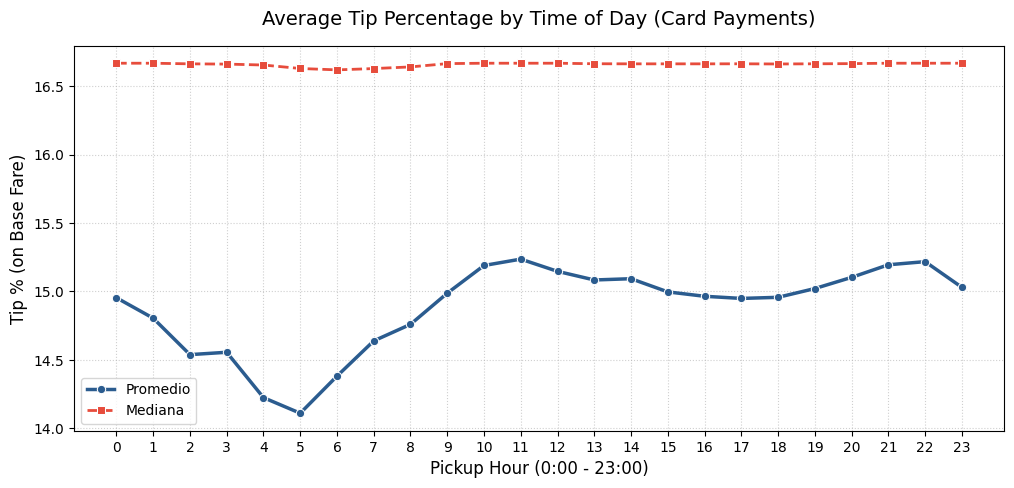

In [71]:

hourly_tips = df_tips.groupby('pickup_hour')['tip_percent'].agg(['mean', 'median', 'count']).reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_tips, x='pickup_hour', y='mean', marker='o', linewidth=2.5, color='#2b5c8f', label='Promedio')
sns.lineplot(data=hourly_tips, x='pickup_hour', y='median', marker='s', linewidth=2, color='#e74c3c', linestyle='--', label='Mediana')

plt.title('Average Tip Percentage by Time of Day (Card Payments)', fontsize=14, pad=15)
plt.xlabel('Pickup Hour (0:00 - 23:00)', fontsize=12)
plt.ylabel('Tip % (on Base Fare)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

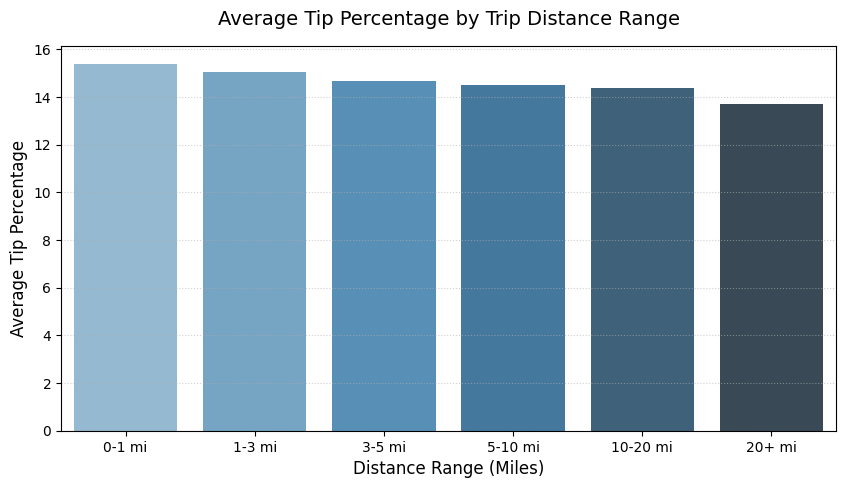

Pearson Correlation (Distance vs. Tip %): -0.0547
Spearman Correlation (Distance vs. Tip %): -0.0484


In [72]:

bins = [0, 1, 3, 5, 10, 20, 50]
labels = ['0-1 mi', '1-3 mi', '3-5 mi', '5-10 mi', '10-20 mi', '20+ mi']
df_tips['distance_group'] = pd.cut(df_tips['trip_distance'], bins=bins, labels=labels)

distance_tips = df_tips.groupby('distance_group', observed=False)['tip_percent'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=distance_tips, x='distance_group', y='mean', hue='distance_group',palette='Blues_d')

plt.title('Average Tip Percentage by Trip Distance Range', fontsize=14, pad=15)
plt.xlabel('Distance Range (Miles)', fontsize=12)
plt.ylabel('Average Tip Percentage', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

corr_pearson = df_tips['trip_distance'].corr(df_tips['tip_percent'], method='pearson')
corr_spearman = df_tips['trip_distance'].corr(df_tips['tip_percent'], method='spearman')

print(f"Pearson Correlation (Distance vs. Tip %): {corr_pearson:.4f}")
print(f"Spearman Correlation (Distance vs. Tip %): {corr_spearman:.4f}")

### **¿How influence the payment method in the tips?**
*As we expected, the tips were only registered in the case of credit card payment. So in this case the average tip was around 3 dollars per trip.*

In [79]:
df_payment=pd.read_csv('C:/Users/EfrenMariscal/Documents/data scientific/DataBricksAnalisis/nyctaxi/taxi_payment.csv')
df_payment.head(5)

,payment_type,payment_desc
0,1,Credit card
1,2,Cash
2,3,No Charge
3,4,Dispute
4,5,Unknown


In [80]:
df_yellow_total=pd.merge(df_yellow_total,df_payment,
                        how='inner',on=['payment_type'])

In [81]:
df_yellow_total.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough,miles_hour,RateCodeDesc,cost_per_mile,tip_percent,payment_desc
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan,Flatiron,Manhattan,10.615385,Standard Rate,6.217391,0.000000,Cash
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan,11.000000,Standard Rate,10.681818,16.595745,Credit card
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan,3.428571,Standard Rate,24.500000,0.000000,Credit card


In [82]:
df_tip_amount=df_yellow_total.loc[df_yellow_total['tip_amount']<20]
df_tip_amount.head(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,month,totalDuration,PULocation_zone,PULocation_borough,DOLocation_zone,DOLocation_borough,miles_hour,RateCodeDesc,cost_per_mile,tip_percent,payment_desc
0,1.0,2019-03-01 00:08:38+00:00,2019-03-01 00:21:01+00:00,1,2.3,1,232,90,2,10.5,3.0,0.5,0.00,0.0,0.3,14.30,2.5,3,13,Two Bridges/Seward Park,Manhattan,Flatiron,Manhattan,10.615385,Standard Rate,6.217391,0.000000,Cash
1,1.0,2019-03-01 00:06:19+00:00,2019-03-01 00:12:08+00:00,1,1.1,1,229,230,1,6.0,3.0,0.5,1.95,0.0,0.3,11.75,2.5,3,6,Sutton Place/Turtle Bay North,Manhattan,Times Sq/Theatre District,Manhattan,11.000000,Standard Rate,10.681818,16.595745,Credit card
2,1.0,2019-03-01 00:30:06+00:00,2019-03-01 00:37:03+00:00,2,0.4,1,211,148,1,6.0,3.0,0.5,0.00,0.0,0.3,9.80,2.5,3,7,SoHo,Manhattan,Lower East Side,Manhattan,3.428571,Standard Rate,24.500000,0.000000,Credit card


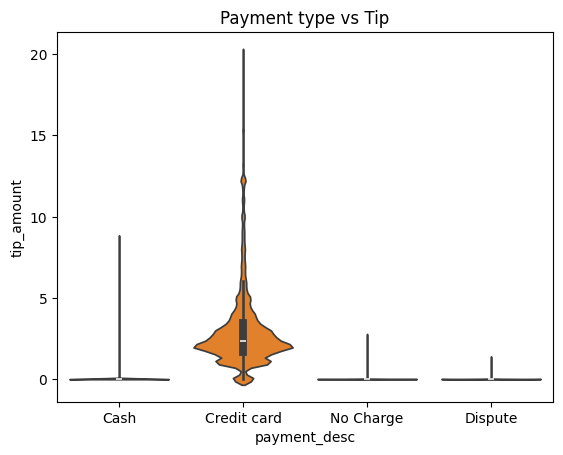

In [83]:
plt.title('Payment type vs Tip')
sns.violinplot(data=df_tip_amount,x='payment_desc',y='tip_amount',hue='payment_desc');

In [84]:
df_tip_amount.groupby('payment_desc')['tip_amount'].agg(['mean','median','count','sum'])

,mean,median,count,sum
payment_desc,,,,
Cash,0.000172,0.00,210707,36.17
Credit card,3.010248,2.36,564543,1699414.31
Dispute,0.001515,0.00,911,1.38
No Charge,0.001556,0.00,2770,4.31


In [85]:
df_tip_amount.groupby('payment_desc')['tip_amount'].agg(['mean','median','count','sum'])


,mean,median,count,sum
payment_desc,,,,
Cash,0.000172,0.00,210707,36.17
Credit card,3.010248,2.36,564543,1699414.31
Dispute,0.001515,0.00,911,1.38
No Charge,0.001556,0.00,2770,4.31


### **¿Which is the average cost per mile in the different services?**

In [86]:
display(Markdown(f"##### Mean: {df_green['totalDuration'].mean()}"))
display(Markdown(f"##### Meadian: {df_green['totalDuration'].median()}"))

##### Mean: 21.406214919889784

##### Meadian: 12.0

# **GREEN TABLE ANALYSIS**

In [87]:
df_green.head(3)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration
0,2.0,2019-01-01T00:44:28.000Z,2019-01-01T00:50:10.000Z,1,181,228,1,1.08,6.0,0.5,0.5,0.00,0.0,0.3,7.30,5,1.0,NaN,1,6
1,2.0,2019-01-01T00:20:51.000Z,2019-01-01T00:29:36.000Z,1,41,74,1,0.93,7.0,0.5,0.5,0.00,0.0,0.3,8.30,5,1.0,NaN,1,9
2,2.0,2019-01-01T00:10:00.000Z,2019-01-01T00:22:54.000Z,1,97,80,1,3.44,13.5,0.5,0.5,2.96,0.0,0.3,17.76,1,1.0,NaN,1,12


### CHANGING THE FORMAT TO MULTIPLE COLUMNS

In [88]:
df_green['lpep_pickup_datetime']=pd.to_datetime(df_green['lpep_pickup_datetime'],format='mixed')
df_green['lpep_dropoff_datetime']=pd.to_datetime(df_green['lpep_dropoff_datetime'],format='mixed')
df_green['trip_type']=df_green['trip_type'].astype('Int64') #Porque hay nulos

In [89]:
df_taxizone

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NV,NaN


### JOINING THE TAXI ZONE TABLE INTO THE GREEN TABLE

In [90]:
df_green=pd.merge(df_green,df_taxizone[['LocationID','Borough','Zone']],how='inner',
                  left_on='PULocationID',right_on='LocationID').rename(columns={'Zone':'PULocation_zone','Borough':'PULocation_borough'})
df_green=df_green.drop(columns=['LocationID'])

In [91]:
df_green=pd.merge(df_green,df_taxizone[['LocationID','Borough','Zone']],how='inner',
                  left_on='DOLocationID',right_on='LocationID').rename(columns={'Zone':'DOLocationID_zone','Borough':'DOLocationID_borough'})
df_green=df_green.drop(columns=['LocationID'])
df_green.head(3)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration,PULocation_borough,PULocation_zone,DOLocationID_borough,DOLocationID_zone
0,2.0,2019-01-01 00:44:28+00:00,2019-01-01 00:50:10+00:00,1,181,228,1,1.08,6.0,0.5,0.5,0.00,0.0,0.3,7.30,5,1,NaN,1,6,Brooklyn,Park Slope,Brooklyn,Sunset Park West
1,2.0,2019-01-01 00:20:51+00:00,2019-01-01 00:29:36+00:00,1,41,74,1,0.93,7.0,0.5,0.5,0.00,0.0,0.3,8.30,5,1,NaN,1,9,Manhattan,Central Harlem,Manhattan,East Harlem North
2,2.0,2019-01-01 00:10:00+00:00,2019-01-01 00:22:54+00:00,1,97,80,1,3.44,13.5,0.5,0.5,2.96,0.0,0.3,17.76,1,1,NaN,1,12,Brooklyn,Fort Greene,Brooklyn,East Williamsburg


## **EXPLORATORY DATA ANALYSIS (EDA)**

In [92]:
df_green.describe()

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration
count,54902.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,58794.000000,54901.0,49570.000000,58794.000000,58794.000000
mean,1.847674,7.629486,107.612767,129.021754,1.289979,3.419116,14.374026,0.546199,0.490161,1.007441,0.248418,0.273268,17.256164,3.544886,1.037176,0.411252,6.092526,21.406215
std,0.359340,24.338857,71.384822,76.251815,0.939925,3.909928,11.956901,0.845374,0.069448,1.916544,1.296401,0.085470,13.361649,1.924360,0.189195,0.980448,3.503110,87.724909
min,1.000000,1.000000,2.000000,1.000000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.000000,1.0,0.000000,1.000000,1.000000
25%,2.000000,1.000000,52.000000,65.000000,1.000000,1.120000,7.000000,0.000000,0.500000,0.000000,0.000000,0.300000,8.760000,1.000000,1.0,0.000000,3.000000,7.000000
50%,2.000000,1.000000,82.000000,129.000000,1.000000,2.020000,10.500000,0.500000,0.500000,0.000000,0.000000,0.300000,12.800000,5.000000,1.0,0.000000,6.000000,12.000000
75%,2.000000,1.000000,166.000000,193.000000,1.000000,4.017500,17.500000,1.000000,0.500000,1.700000,0.000000,0.300000,21.050000,5.000000,1.0,0.000000,9.000000,20.000000
max,2.000000,99.000000,265.000000,265.000000,6.000000,60.910000,257.000000,8.250000,0.500000,80.000000,55.980000,0.300000,269.300000,5.000000,2.0,2.750000,12.000000,1439.000000


### NULL VALUES TREATMENT

In [93]:
df_green.isnull().sum()

VendorID                 3892
lpep_pickup_datetime        0
lpep_dropoff_datetime       0
RatecodeID                  0
PULocationID                0
DOLocationID                0
passenger_count             0
trip_distance               0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
payment_type                0
trip_type                3893
congestion_surcharge     9224
month                       0
totalDuration               0
PULocation_borough          0
PULocation_zone            18
DOLocationID_borough        0
DOLocationID_zone         132
dtype: int64

In [94]:
#green_null['congestion_surcharge']=green_null.loc[green_null['PULocation_borough'] != 'Manhattan'] = 0
df_green.loc[(~df_green["PULocation_borough"].str.contains('Manhattan', na=False)) & 
    (df_green['congestion_surcharge'].isnull()),
    "congestion_surcharge"] = 0

In [95]:
df_green=df_green.loc[df_green['DOLocationID_zone'].notnull()]
df_green=df_green.loc[df_green['PULocation_zone'].notnull()]

In [96]:
df_green.isnull().sum()


VendorID                 3873
lpep_pickup_datetime        0
lpep_dropoff_datetime       0
RatecodeID                  0
PULocationID                0
DOLocationID                0
passenger_count             0
trip_distance               0
fare_amount                 0
extra                       0
mta_tax                     0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
payment_type                0
trip_type                3874
congestion_surcharge     2259
month                       0
totalDuration               0
PULocation_borough          0
PULocation_zone             0
DOLocationID_borough        0
DOLocationID_zone           0
dtype: int64

#### ANALYZING GREEN TABLE WITH AI

In [236]:
df_green_sample=df_green.sample(n=50)
df_green_dict=df_green_sample.to_dict(orient='records')
template=ChatPromptTemplate.from_messages([
    ("system","""You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."""),
    ("user","""Explain the dataset to me clearly and also tell me what mean all the columns. The dataset is: {dataset}""")
])
chain=template|llm
response=chain.invoke({"dataset":df_green_dict})
display(Markdown(response.content))

This dataset contains records of individual Green Taxi trips in New York City, likely for the year 2019, providing detailed information about each ride from pickup to dropoff, including costs, duration, and location details.

Here's a breakdown of each column:

*   **`VendorID`**: An identifier indicating the taxi service provider associated with the trip.
*   **`lpep_pickup_datetime`**: The exact date and time (in UTC) when the passenger was picked up.
*   **`lpep_dropoff_datetime`**: The exact date and time (in UTC) when the passenger was dropped off.
*   **`RatecodeID`**: The final rate code in effect at the end of the trip. (e.g., 1=Standard rate, 2=JFK, 3=Newark, 4=Nassau or Westchester, 5=Negotiated fare, 6=Group ride). `99` often indicates a custom or invalid rate.
*   **`PULocationID`**: A unique identifier for the taxi zone where the trip started (Pickup Location ID).
*   **`DOLocationID`**: A unique identifier for the taxi zone where the trip ended (Dropoff Location ID).
*   **`passenger_count`**: The number of passengers in the vehicle for the trip.
*   **`trip_distance`**: The elapsed trip distance in miles reported by the taximeter.
*   **`fare_amount`**: The time-and-distance base fare calculated by the meter.
*   **`extra`**: Miscellaneous extra charges (e.g., $0.50 and $1.00 for night/peak hours, $0.50 for a 15-cent bridge toll).
*   **`mta_tax`**: $0.50 MTA tax that is collected per trip.
*   **`tip_amount`**: The amount of tip paid by the passenger.
*   **`tolls_amount`**: Total amount of all tolls paid in the trip.
*   **`improvement_surcharge`**: $0.30 improvement surcharge assessed per trip.
*   **`total_amount`**: The total amount charged to the passenger, including all components (fare, extras, taxes, tolls, tips, surcharges).
*   **`payment_type`**: A numeric code indicating how the passenger paid for the trip (e.g., 1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown, 6=Voided trip).
*   **`trip_type`**: Indicates if the trip was a street-hail (1) or a dispatch (2).
*   **`congestion_surcharge`**: A surcharge applied for trips within congested areas of Manhattan.
*   **`month`**: The month number when the trip occurred (derived from `lpep_pickup_datetime`).
*   **`totalDuration`**: The total duration of the trip in minutes (derived from pickup and dropoff times).
*   **`PULocation_borough`**: The administrative borough (e.g., Manhattan, Queens) of the pickup location (derived from `PULocationID`).
*   **`PULocation_zone`**: The specific taxi zone name of the pickup location (derived from `PULocationID`).
*   **`DOLocationID_borough`**: The administrative borough of the dropoff location (derived from `DOLocationID`).
*   **`DOLocationID_zone`**: The specific taxi zone name of the dropoff location (derived from `DOLocationID`).

**Professional Perspective & Recommendations:**

This dataset is rich for analyzing urban mobility patterns and taxi service economics.

1.  **Demand Analysis:** The `lpep_pickup_datetime`, `PULocation_borough`, and `PULocation_zone` columns are excellent for understanding demand hotspots and temporal patterns (e.g., peak hours, monthly trends).
2.  **Pricing & Revenue Optimization:** `fare_amount`, `total_amount`, `trip_distance`, and `totalDuration` can be used to model pricing strategies, analyze revenue per mile/minute, and identify factors influencing profitability. The various surcharges (`extra`, `mta_tax`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`) offer granular insights into cost components.
3.  **Operational Efficiency:** `trip_distance` and `totalDuration` can help assess driver efficiency and identify potential routing issues or areas with high traffic congestion.
4.  **Customer Behavior:** `passenger_count` and `tip_amount` provide insights into passenger habits and satisfaction. `payment_type` can reveal preferences.
5.  **Data Quality:** Note the `NaN` values in `VendorID`, `congestion_surcharge`, and `trip_type`. These need to be addressed (imputation, removal, or specific handling) before analysis, as they represent missing information. The `RatecodeID` of `99` also suggests non-standard trips that might require special handling or filtering.

This dataset is ideal for tasks like predictive modeling (e.g., predicting trip duration or fare), anomaly detection (e.g., unusually long/short trips for the distance), and geographical analysis of taxi movements.

## **UNIVARIABLE GRAPHS**

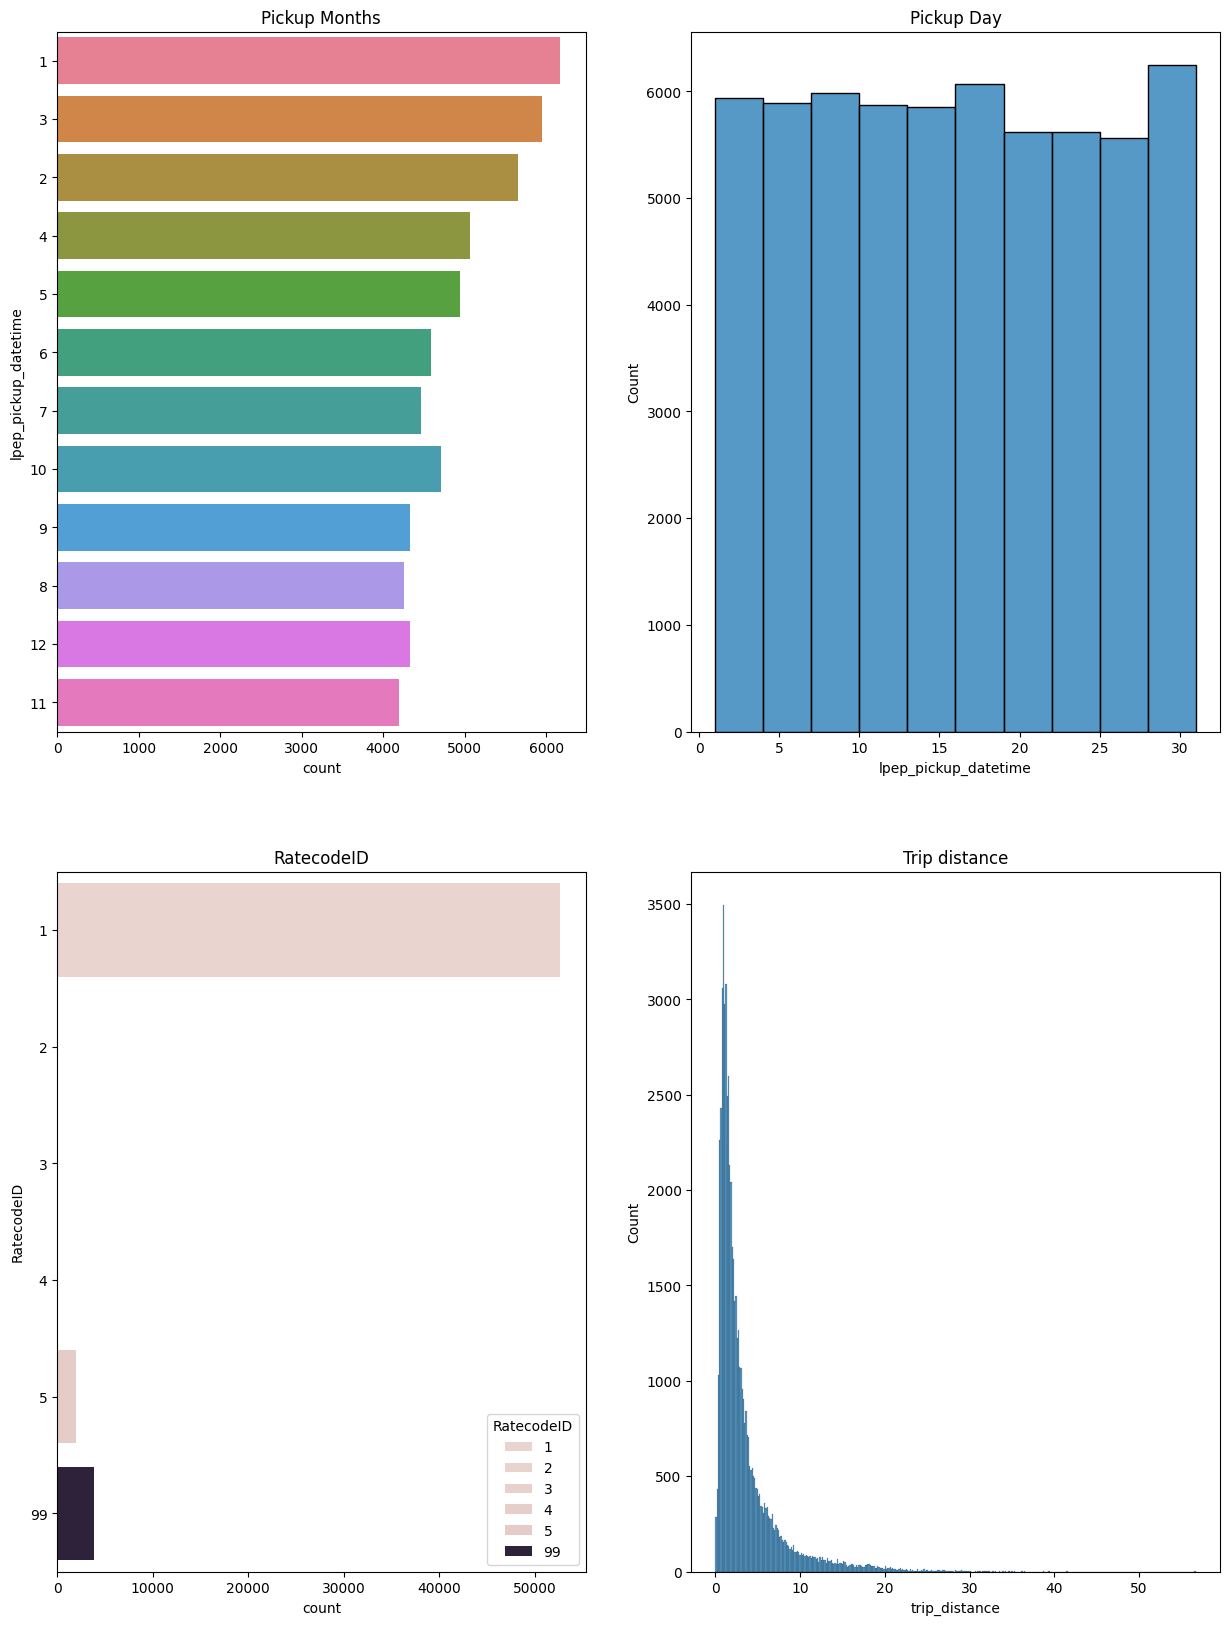

In [97]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('Pickup Months')
sns.countplot(data=df_green,y=df_green['lpep_pickup_datetime'].dt.month.astype('str'),hue=df_green['lpep_pickup_datetime'].dt.month.astype('str'),ax=ax1)

ax2.set_title('Pickup Day')
sns.histplot(data=df_green,x=df_green['lpep_pickup_datetime'].dt.day,bins=10,ax=ax2)

ax3.set_title('RatecodeID')
sns.countplot(data=df_green,y=df_green['RatecodeID'],hue='RatecodeID',ax=ax3)

ax4.set_title('Trip distance')
sns.histplot(data=df_green,x='trip_distance',ax=ax4);

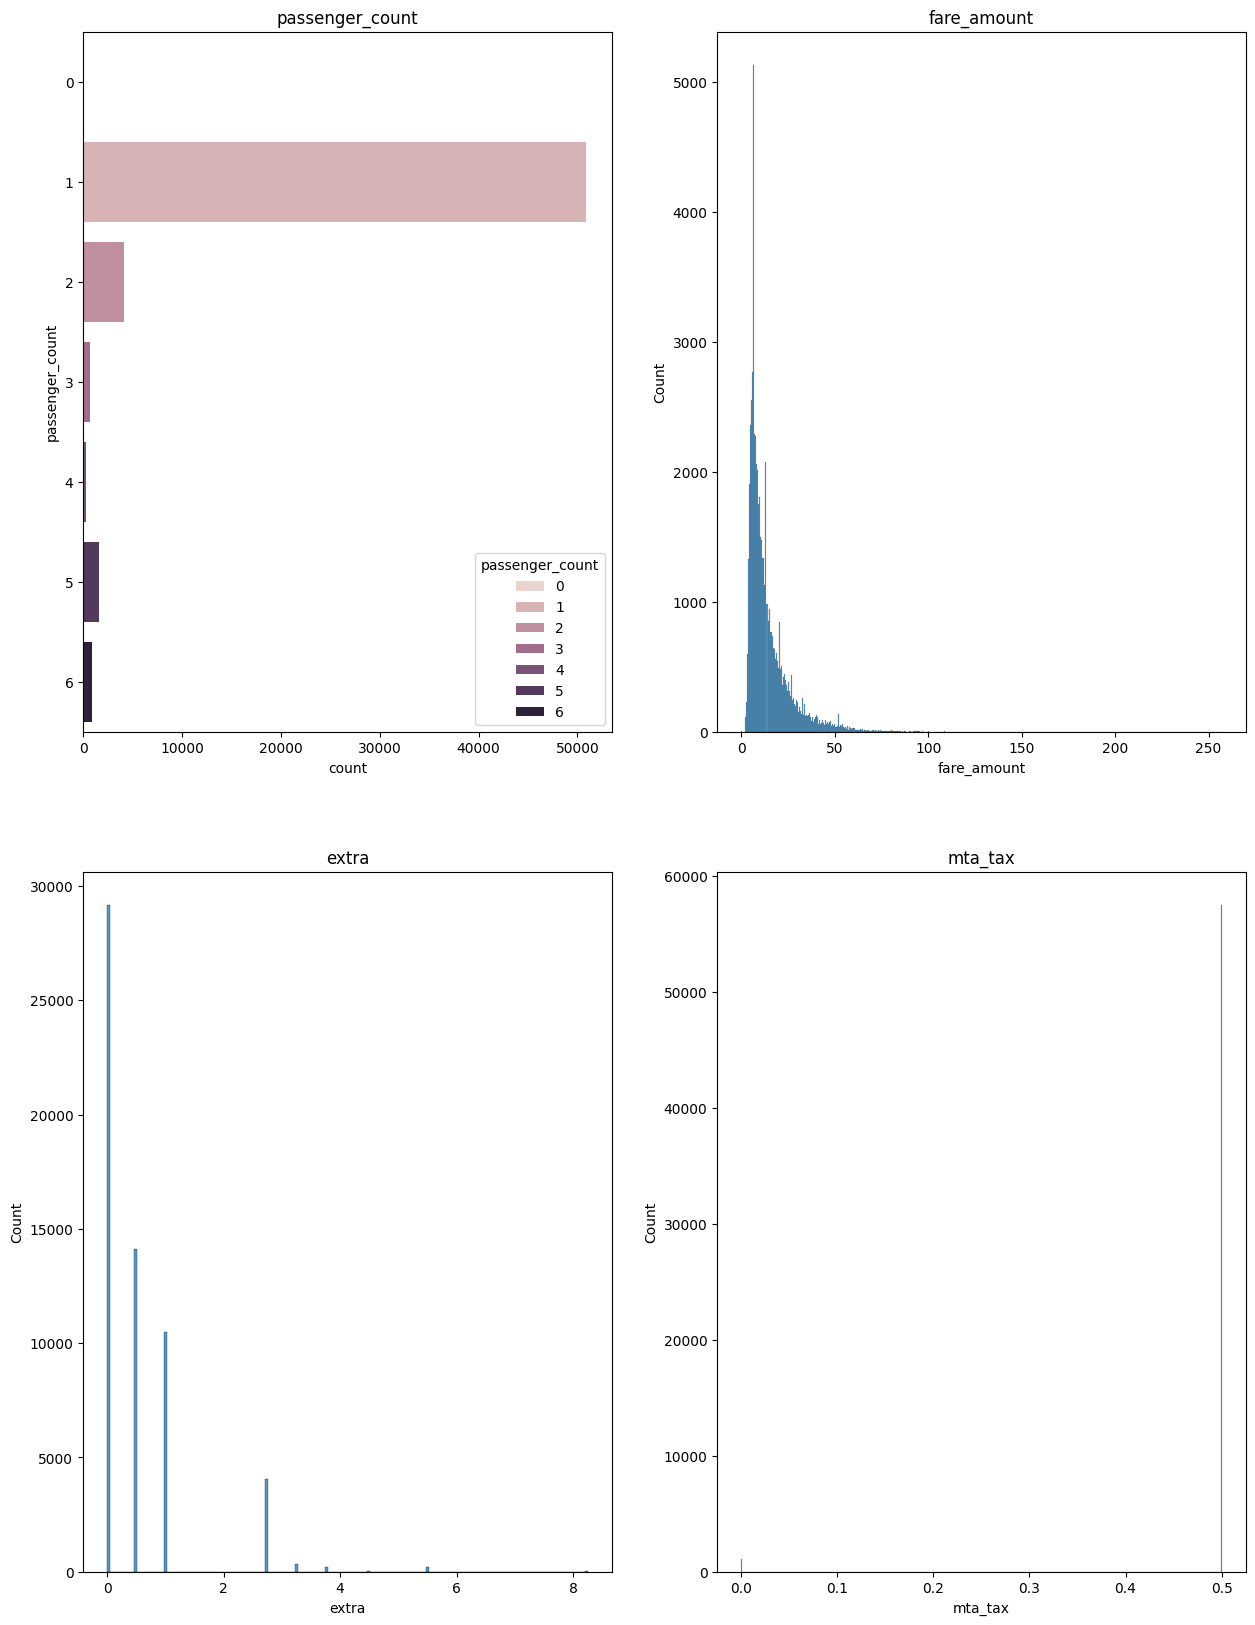

In [98]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('passenger_count')
sns.countplot(data=df_green,y='passenger_count',hue='passenger_count',ax=ax1)

ax2.set_title('fare_amount')
sns.histplot(data=df_green,x='fare_amount',ax=ax2)

ax3.set_title('extra')
sns.histplot(data=df_green,x='extra',ax=ax3)

ax4.set_title('mta_tax')
sns.histplot(data=df_green,x='mta_tax',ax=ax4);

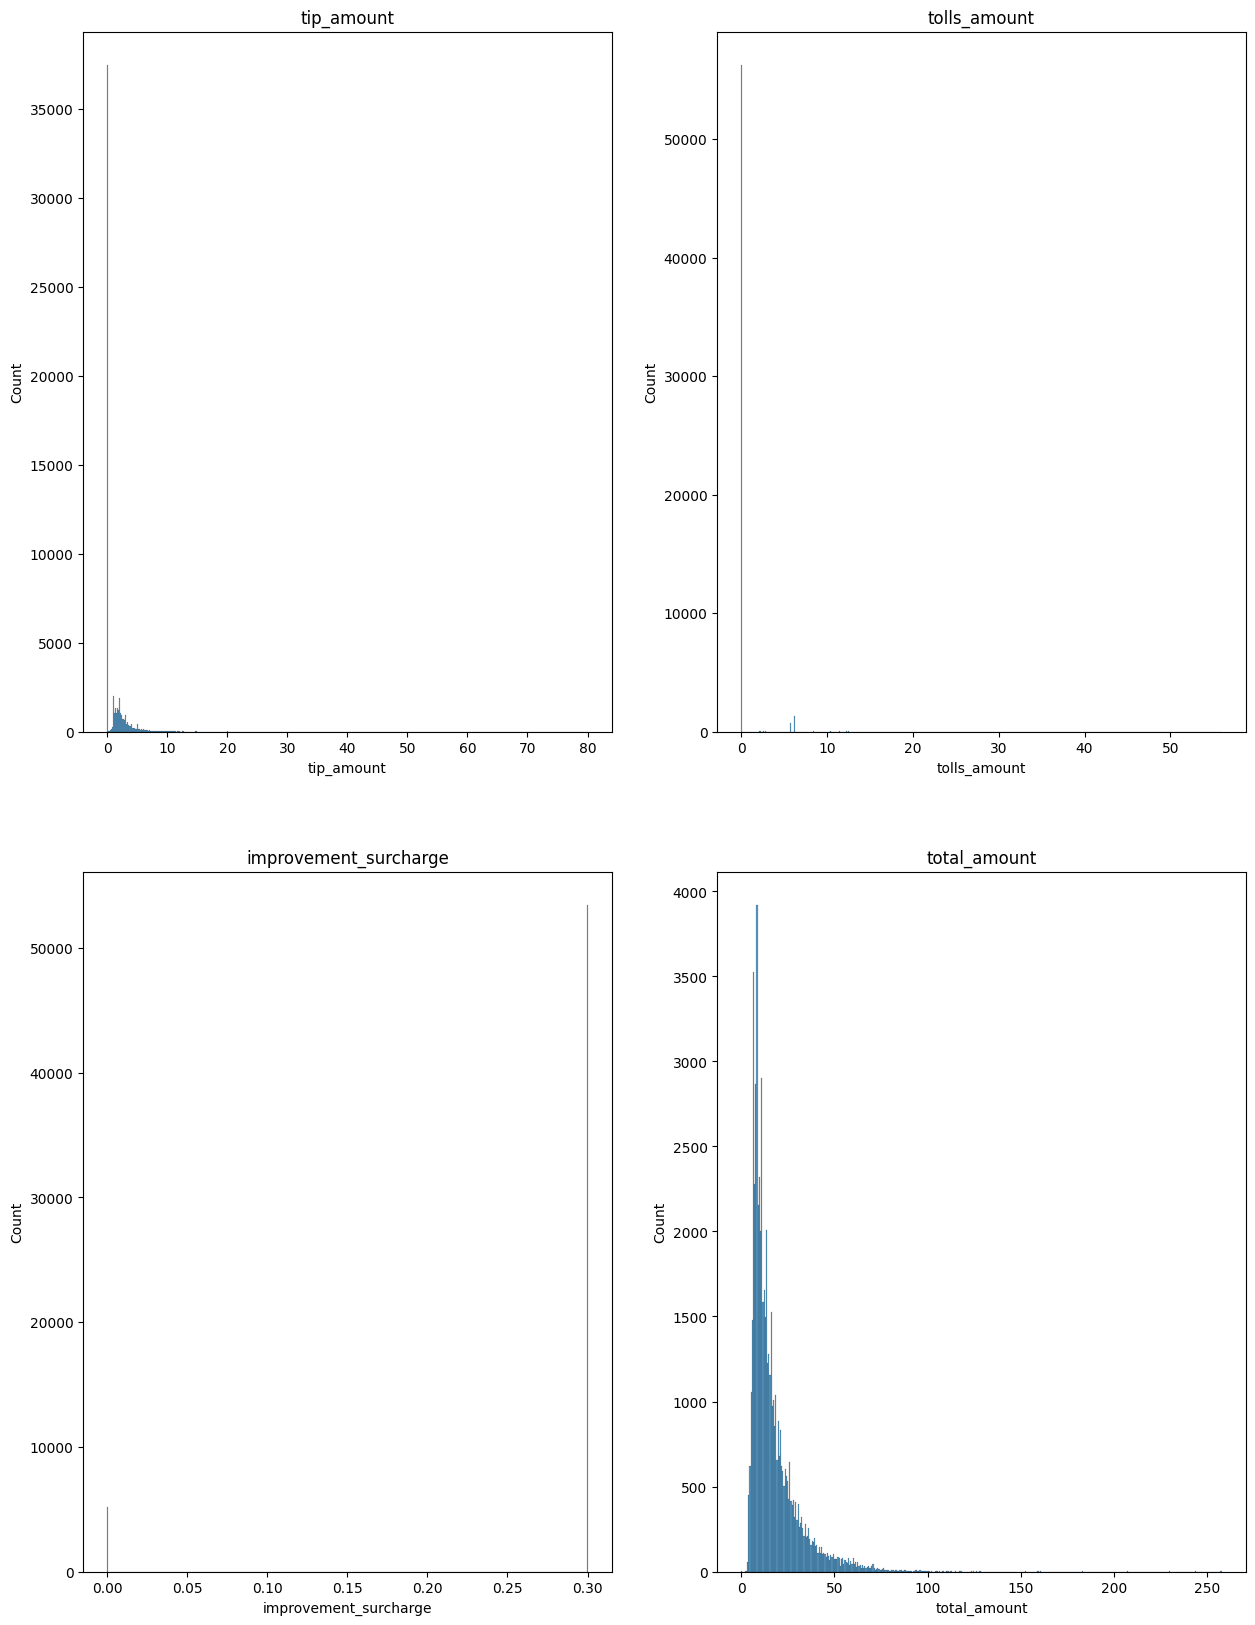

In [99]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('tip_amount')
sns.histplot(data=df_green,x='tip_amount',ax=ax1)

ax2.set_title('tolls_amount')
sns.histplot(data=df_green,x='tolls_amount',ax=ax2)

ax3.set_title('improvement_surcharge')
sns.histplot(data=df_green,x='improvement_surcharge',ax=ax3)

ax4.set_title('total_amount')
sns.histplot(data=df_green,x='total_amount',ax=ax4);

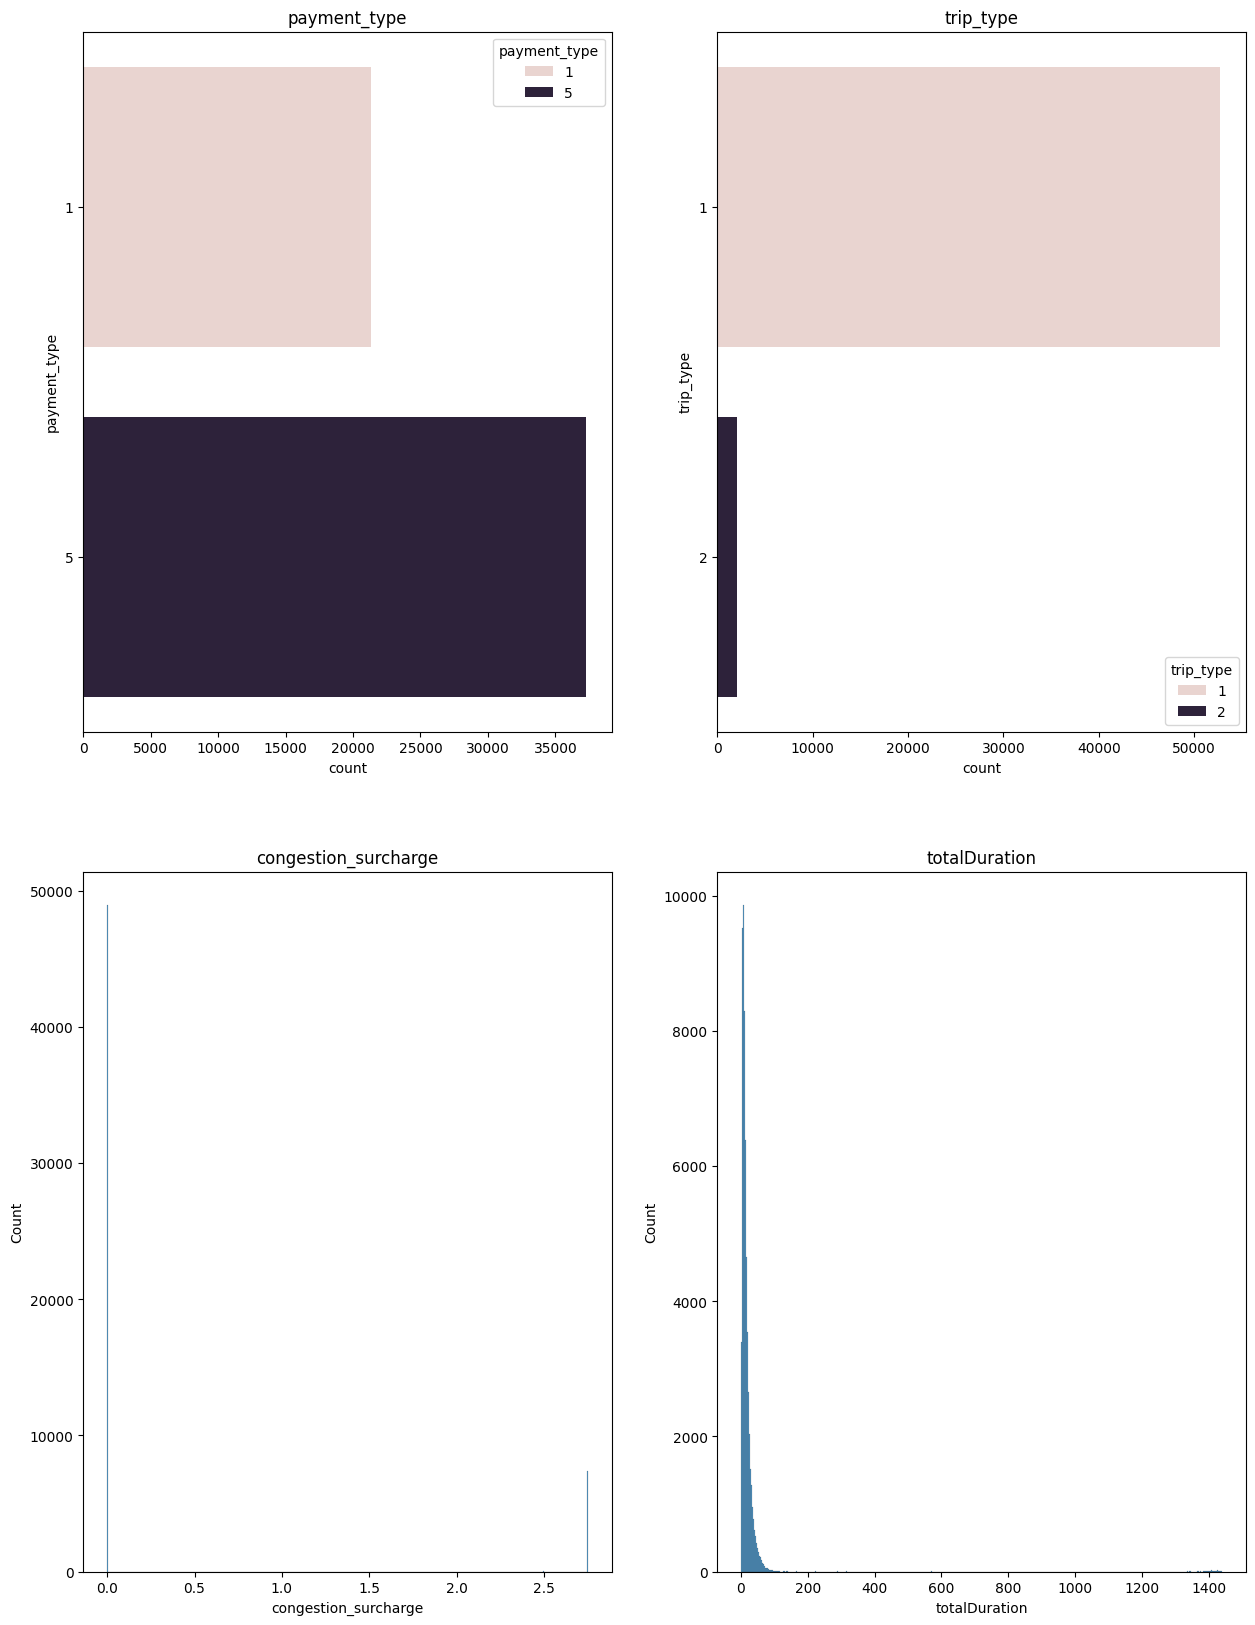

In [100]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('payment_type')
sns.countplot(data=df_green,y='payment_type',hue='payment_type',ax=ax1)

ax2.set_title('trip_type')
sns.countplot(data=df_green,y='trip_type',hue='trip_type',ax=ax2)

ax3.set_title('congestion_surcharge')
sns.histplot(data=df_green,x='congestion_surcharge',ax=ax3)

ax4.set_title('totalDuration')
sns.histplot(data=df_green,x='totalDuration',ax=ax4);

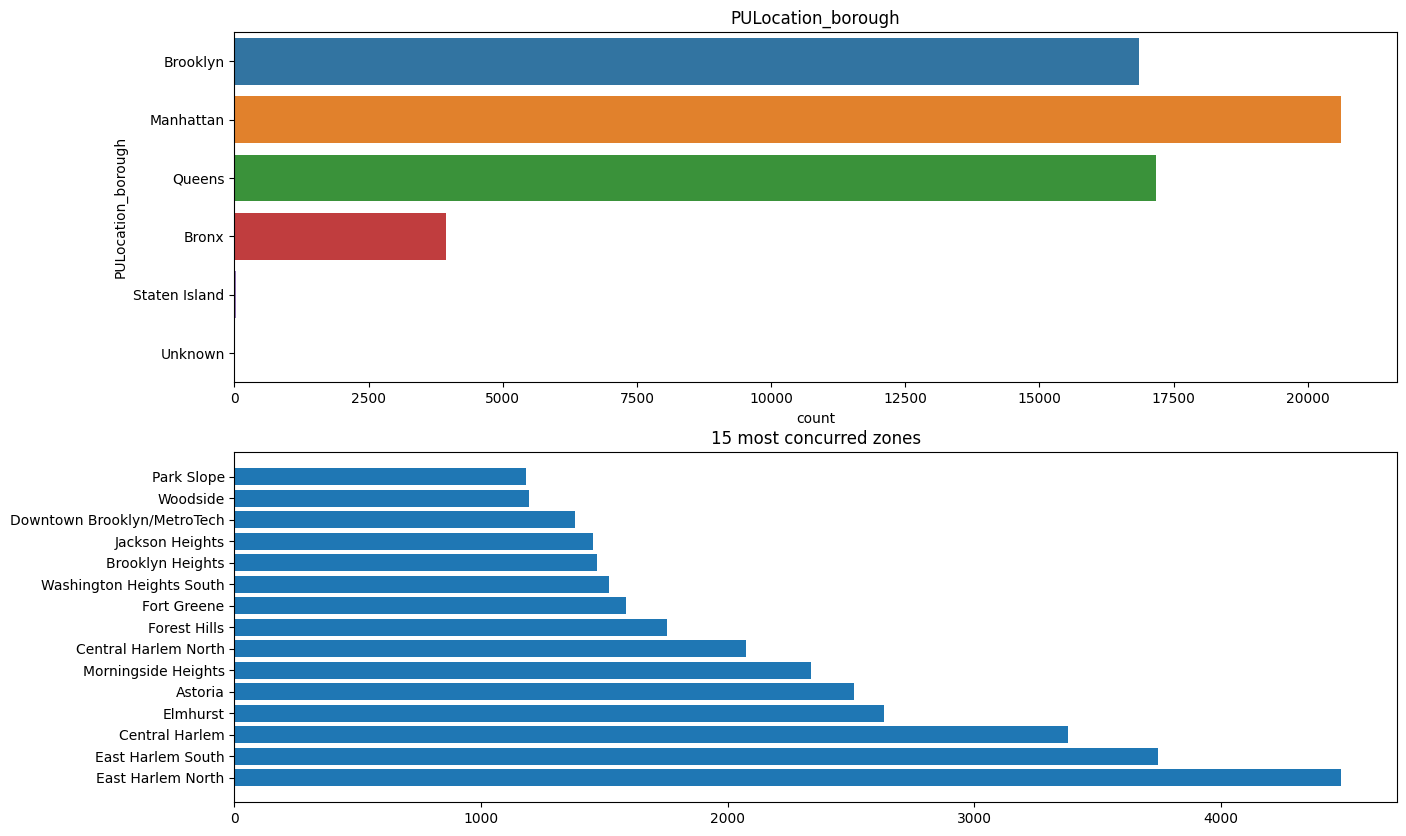

In [101]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(15,10))
ax1=ax[0];ax2=ax[1]

ax1.set_title('PULocation_borough')
sns.countplot(data=df_green,y='PULocation_borough',hue='PULocation_borough',ax=ax1)

zones=df_green['PULocation_zone'].value_counts().head(15)
ax2.set_title('15 most concurred zones')
ax2.barh(zones.index,width=zones.values);

### OUTLIERS TREATMENT

In [102]:
print(len(df_green.loc[df_green['trip_distance']>25]))
df_green=df_green.loc[df_green['trip_distance']<25]

158


In [103]:
print(len(df_green.loc[df_green['fare_amount']>68]))
df_green=df_green.loc[df_green['fare_amount']<68]


138


In [104]:
print(len(df_green.loc[df_green['extra']>6]))
df_green=df_green.loc[df_green['extra']<6]

19


In [105]:
print(len(df_green.loc[df_green['tip_amount']>13]))
df_green=df_green.loc[df_green['tip_amount']<13]

48


In [106]:
print(len(df_green.loc[df_green['tolls_amount']>12]))
df_green=df_green.loc[df_green['tolls_amount']<12]

46


In [107]:
print(len(df_green.loc[df_green['totalDuration']>150]))
df_green=df_green.loc[df_green['totalDuration']<170]


268


## **MULTIVARIABLE DATA ANALYSIS**

### **Which is the time of the day and days of the week with the highest volume of trips?**
- **Hours:** *The most concurred hours were between 16-19 (4-7pm).*
- **Days of the week:** *The most concurred days were Wednesday and Thursday.*

In [108]:
df_green['hours']=df_green['lpep_pickup_datetime'].dt.hour
time_day=df_green['hours'].value_counts().reset_index().sort_values(by='hours',ascending=True)
days=df_green['lpep_pickup_datetime'].dt.dayofweek.value_counts().reset_index().sort_values(by='lpep_pickup_datetime',ascending=True)
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
days['days']=day_names

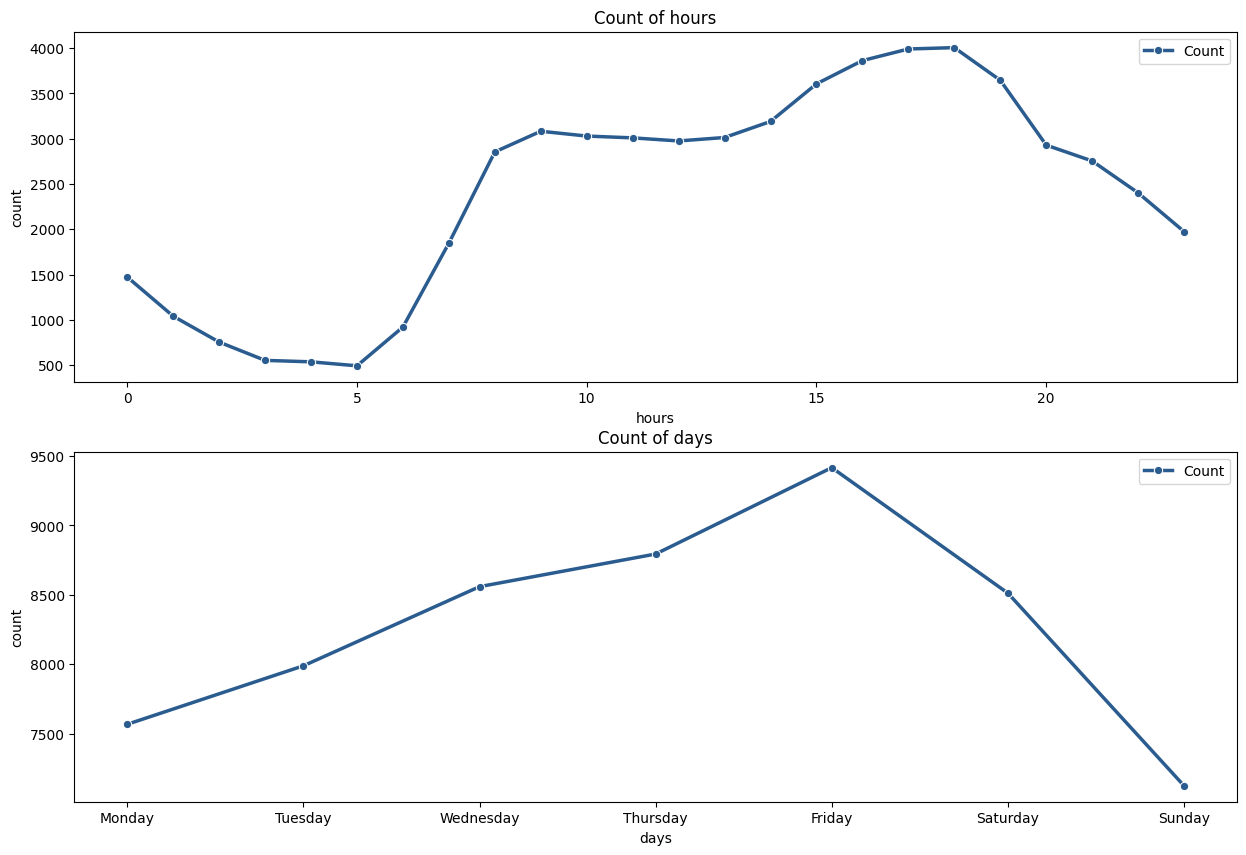

In [109]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(15,10))
ax1=ax[0];ax2=ax[1]

ax1.set_title('Count of hours')
sns.lineplot(data=time_day,x='hours',y='count',  marker='o', linewidth=2.5, color='#2b5c8f', label='Count',ax=ax1)

ax2.set_title('Count of days')
sns.lineplot(data=days,x='days',y='count',marker='o', linewidth=2.5, color='#2b5c8f', label='Count',ax=ax2);

### **¿How is the demand between laboral days and weekends?**
*There were more quantity of trips in the laboral days instead of weekends like Wednesday,Thursday and Friday. But the differences between them is that weekends had more quantity of trips in the midnight and early hours of the morning. This could be because people take a break and go to the clubs,parties,etc.*

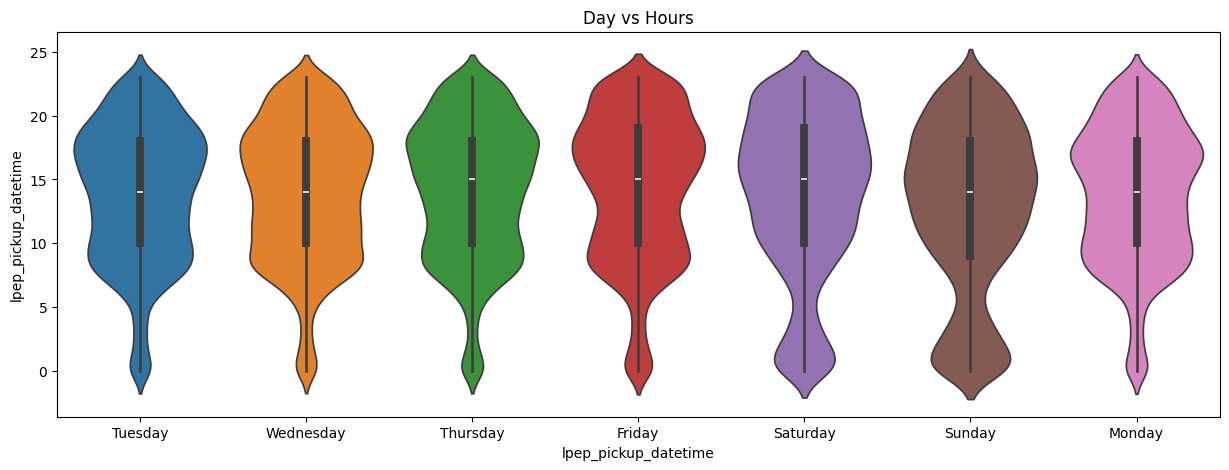

In [110]:
plt.figure(figsize=(15,5))

plt.title('Day vs Hours')
sns.violinplot(data=df_green,x=df_green['lpep_pickup_datetime'].dt.day_name(),y=df_green['lpep_pickup_datetime'].dt.hour,
              hue=df_green['lpep_pickup_datetime'].dt.day_name());

In [111]:
df_green['lpep_pickup_datetime'].dt.day_name().value_counts()

lpep_pickup_datetime
Friday       9416
Thursday     8794
Wednesday    8559
Saturday     8512
Tuesday      7989
Monday       7568
Sunday       7125
Name: count, dtype: int64

In [112]:
df_green.groupby(df_green['lpep_pickup_datetime'].dt.day_name())['hours'].agg(['mean','median'])


,mean,median
lpep_pickup_datetime,,
Friday,14.289507,15.0
Monday,13.771274,14.0
Saturday,13.793116,15.0
Sunday,12.647018,14.0
Thursday,14.158631,15.0
Tuesday,13.861434,14.0
Wednesday,13.930249,14.0


### **¿Which are the seasons or months of the year where there are more trips?**
*A difference between yellow taxis, the months with more concentration of trips were January,March and February. The graph of yellow taxis shows that January was the month with less trips in that case. The distribution of the trips along the day is similar or the same in all the months.*

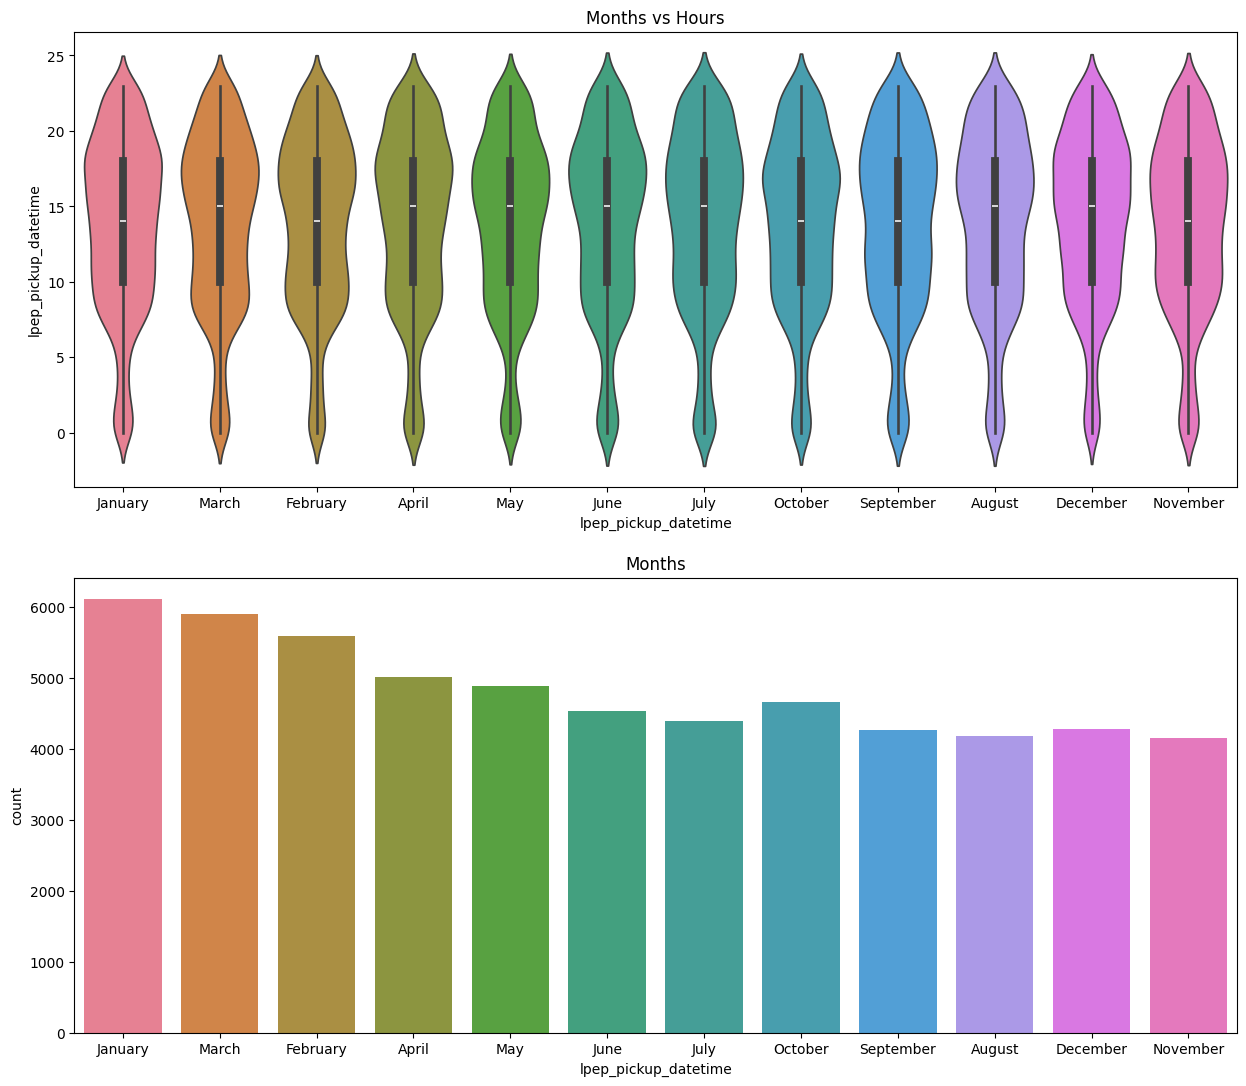

In [113]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(15,13))
ax1=ax[0];ax2=ax[1]

ax1.set_title('Months vs Hours')
sns.violinplot(data=df_green,x=df_green['lpep_pickup_datetime'].dt.month_name(),y=df_green['lpep_pickup_datetime'].dt.hour,
              hue=df_green['lpep_pickup_datetime'].dt.month_name(),ax=ax1)

ax2.set_title('Months')
sns.countplot(data=df_green,x=df_green['lpep_pickup_datetime'].dt.month_name(),hue=df_green['lpep_pickup_datetime'].dt.month_name(),ax=ax2);

### **¿Which are the 10 origin zones and destinations with more trips?**
- **Pickup zones:** *The pickup zones with more records were 'East Harlem North' in the first place, followed by 'East Harlem South', 'Central Harlem','Elmhurst',etc.*
- **Dropoff zones:** *The drop off zones with more records were 'East Harlem North' in the first place, followed by 'Central Harlem North', 'Central Harlem','Jackson Heights',etc.*

In [114]:
zones=df_green['PULocation_zone'].value_counts().head(10)
pickup_zones=df_green.loc[df_green['PULocation_zone'].isin(zones.index)]
zones_off=df_green['DOLocationID_zone'].value_counts().head(10)
dropoff_zones=df_green.loc[df_green['DOLocationID_zone'].isin(zones_off.index)]

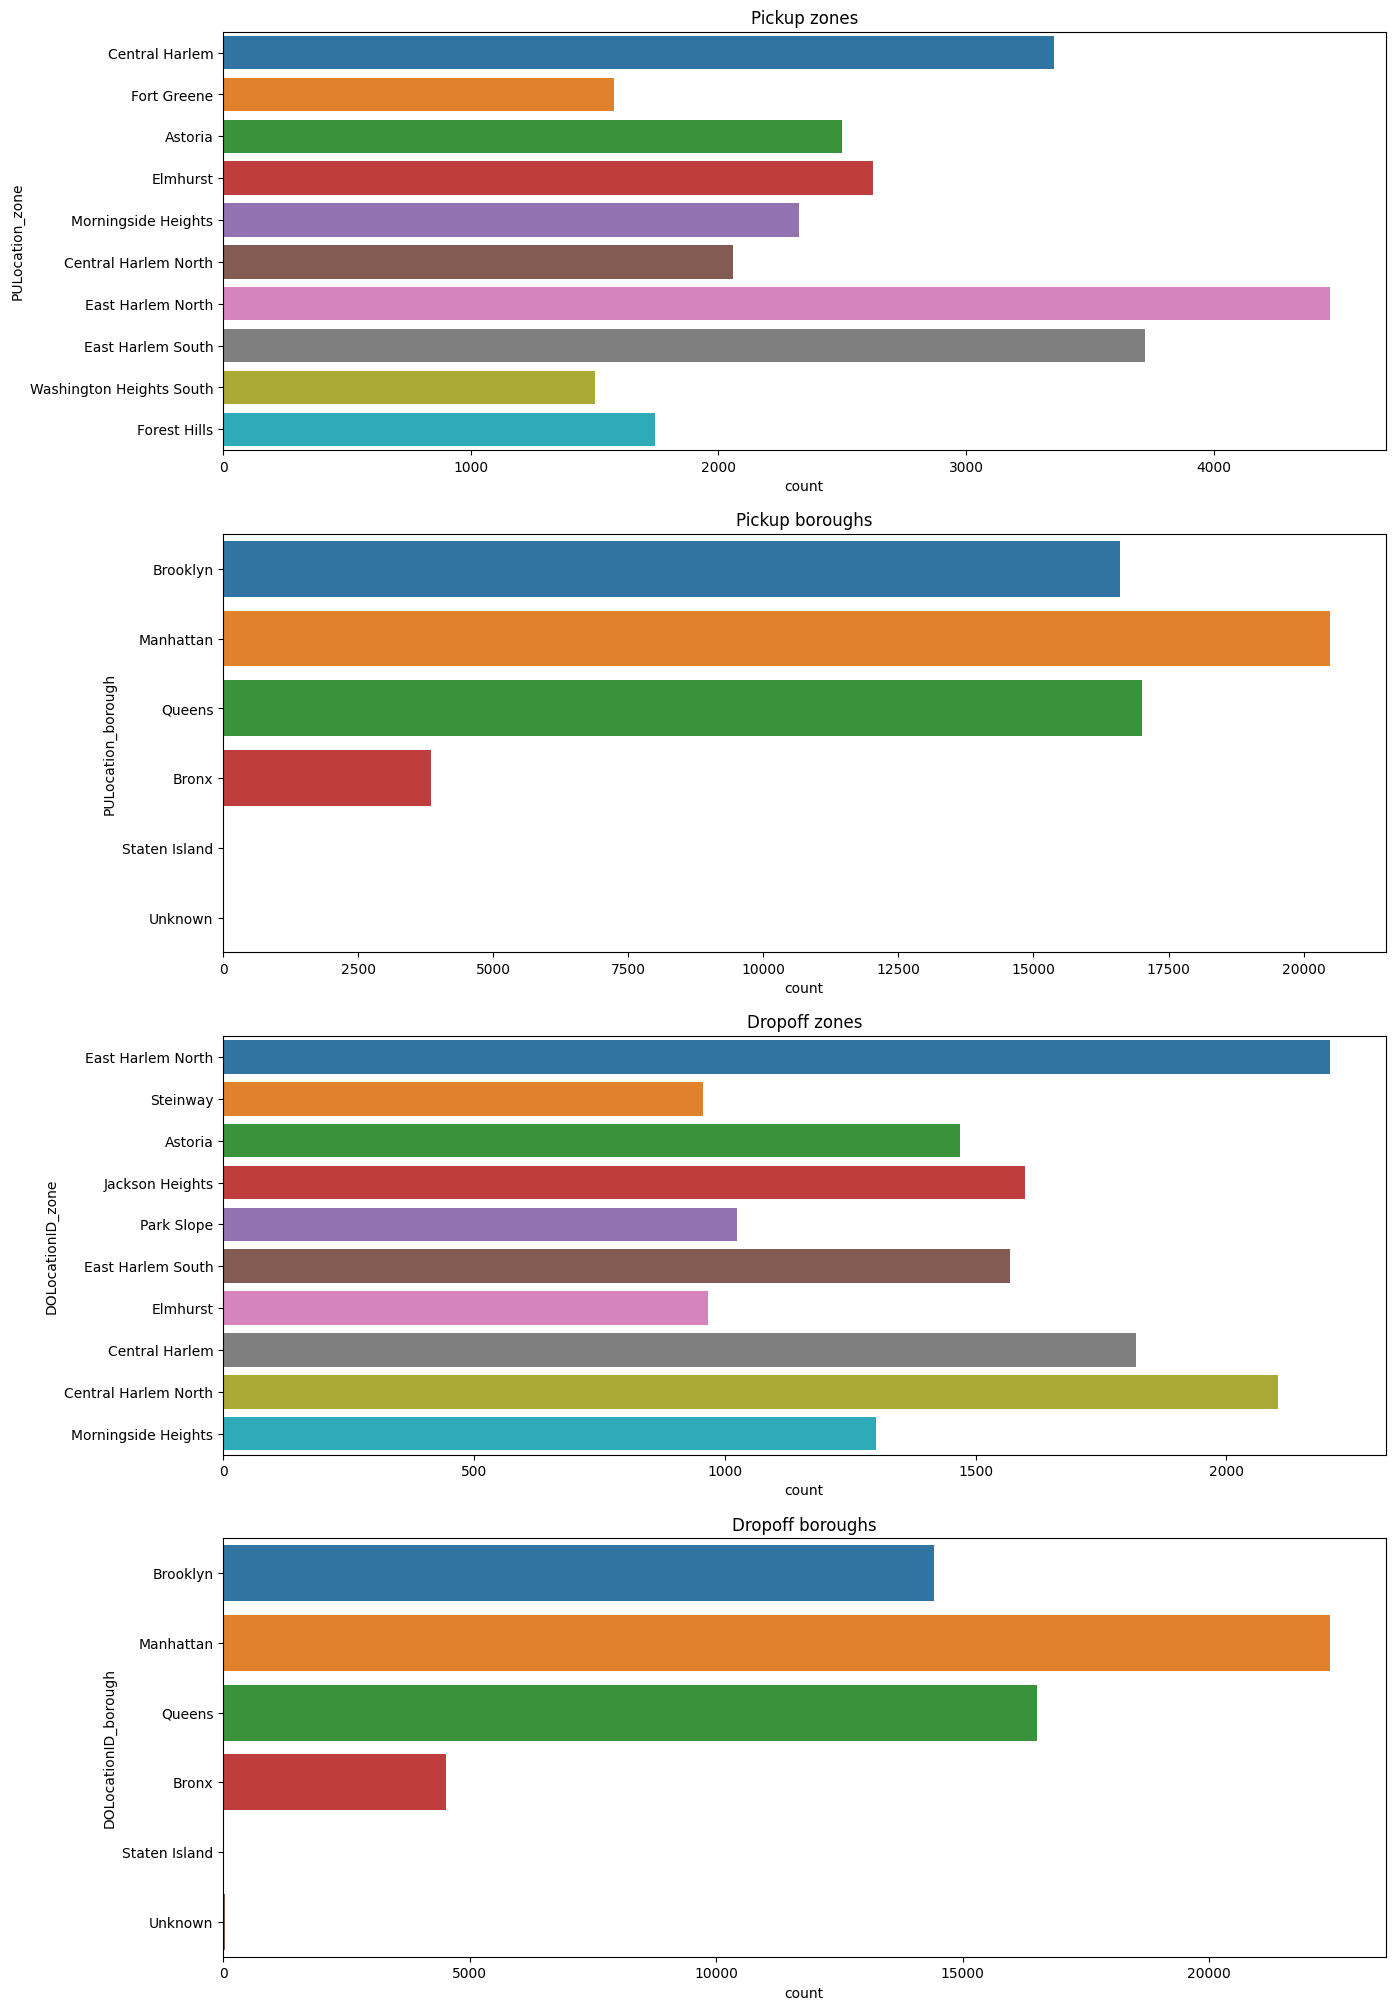

In [115]:
fig,ax=plt.subplots(nrows=4,ncols=1,figsize=(15,25))
ax1=ax[0];ax2=ax[1];ax3=ax[2];ax4=ax[3]

ax1.set_title('Pickup zones')
sns.countplot(data=pickup_zones,y='PULocation_zone',hue='PULocation_zone',ax=ax1)

ax2.set_title('Pickup boroughs')
sns.countplot(data=df_green,y='PULocation_borough',hue='PULocation_borough',ax=ax2)

ax3.set_title('Dropoff zones')
sns.countplot(data=dropoff_zones,y='DOLocationID_zone',hue='DOLocationID_zone',ax=ax3)

ax4.set_title('Dropoff boroughs')
sns.countplot(data=df_green,y='DOLocationID_borough',hue='DOLocationID_borough',ax=ax4);

In [116]:
df_green['miles_hour']=(df_green['trip_distance'])/(df_green['totalDuration']/60)
df_green.head(3)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration,PULocation_borough,PULocation_zone,DOLocationID_borough,DOLocationID_zone,hours,miles_hour
0,2.0,2019-01-01 00:44:28+00:00,2019-01-01 00:50:10+00:00,1,181,228,1,1.08,6.0,0.5,0.5,0.00,0.0,0.3,7.30,5,1,0.0,1,6,Brooklyn,Park Slope,Brooklyn,Sunset Park West,0,10.8
1,2.0,2019-01-01 00:20:51+00:00,2019-01-01 00:29:36+00:00,1,41,74,1,0.93,7.0,0.5,0.5,0.00,0.0,0.3,8.30,5,1,NaN,1,9,Manhattan,Central Harlem,Manhattan,East Harlem North,0,6.2
2,2.0,2019-01-01 00:10:00+00:00,2019-01-01 00:22:54+00:00,1,97,80,1,3.44,13.5,0.5,0.5,2.96,0.0,0.3,17.76,1,1,0.0,1,12,Brooklyn,Fort Greene,Brooklyn,East Williamsburg,0,17.2


### **¿Which routes have the highest traffic flows?**
- **Slowest routes:** *The 3 slowest routes were 'Fort Greene to Boerum Hill' with 7 miles/hour,'Boerum Hill to Fort Greene' with 7.6 miles/hour and 'Jackson Heights to Elmhurst' with 7.8 miles/hour.*
- **Fastest routes:** *The fastest routes were 'Washington Heights South to Upper West Side North' with 20.2 miles/hour,'Kew Gardens to South Ozone Park' with 18.7 miles/hour,'Elmhurst to LaGuardia Airport' with 16.7 miles/hour.*

In [117]:
routes_green = df_green[['PULocation_zone','DOLocationID_zone']].value_counts().reset_index()
routes_green= routes_green.loc[routes_green['count']>50]
routes_green['route']=routes_green['PULocation_zone'] + '-->' + routes_green['DOLocationID_zone']
routes=routes_green.head(10).copy()

In [118]:
distance=(df_green.groupby(['PULocation_zone','DOLocationID_zone'])['miles_hour']
            .agg(['mean','median']).sort_values('mean',ascending=False).reset_index())
distance['route']=distance['PULocation_zone'] + '-->' + distance['DOLocationID_zone']
distance=distance.loc[distance['route'].isin(routes_green['route'])]
distance_slow=distance.sort_values('mean',ascending=True).head(10)
distance_fast=distance.sort_values('mean',ascending=False).head(10)

In [119]:
df_green.loc[(df_green['PULocation_zone'].str.contains('Howard Beach',case=False,na=False))&(df_green['DOLocationID_zone'].str.contains('Howard Beach',case=False,na=False))]

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration,PULocation_borough,PULocation_zone,DOLocationID_borough,DOLocationID_zone,hours,miles_hour
26873,1.0,2019-05-25 04:23:25+00:00,2019-05-25 04:24:40+00:00,5,124,124,1,10.0,45.0,0.0,0.0,0.0,0.0,0.0,45.0,5,2,0.0,5,1,Queens,Howard Beach,Queens,Howard Beach,4,600.0


In [120]:
distance_fast

,PULocation_zone,DOLocationID_zone,mean,median,route
2037,Washington Heights South,Upper West Side North,20.203271,19.882418,Washington Heights South-->Upper West Side North
2587,Kew Gardens,South Ozone Park,18.648639,17.963529,Kew Gardens-->South Ozone Park
3338,Elmhurst,LaGuardia Airport,16.692778,16.918831,Elmhurst-->LaGuardia Airport
4423,Jamaica,Saint Albans,14.380683,14.500000,Jamaica-->Saint Albans
4639,Crown Heights North,Crown Heights North,14.048806,8.028571,Crown Heights North-->Crown Heights North
4663,Elmhurst,East Elmhurst,14.003245,12.771429,Elmhurst-->East Elmhurst
4677,Jamaica,South Ozone Park,13.986969,13.320000,Jamaica-->South Ozone Park
4753,Forest Hills,Briarwood/Jamaica Hills,13.849374,13.412500,Forest Hills-->Briarwood/Jamaica Hills
4767,East Harlem South,East Harlem North,13.826255,13.000000,East Harlem South-->East Harlem North
4922,Washington Heights South,Morningside Heights,13.569818,13.500000,Washington Heights South-->Morningside Heights


In [121]:
routes= distance.loc[distance['route'].isin(routes['route'])]

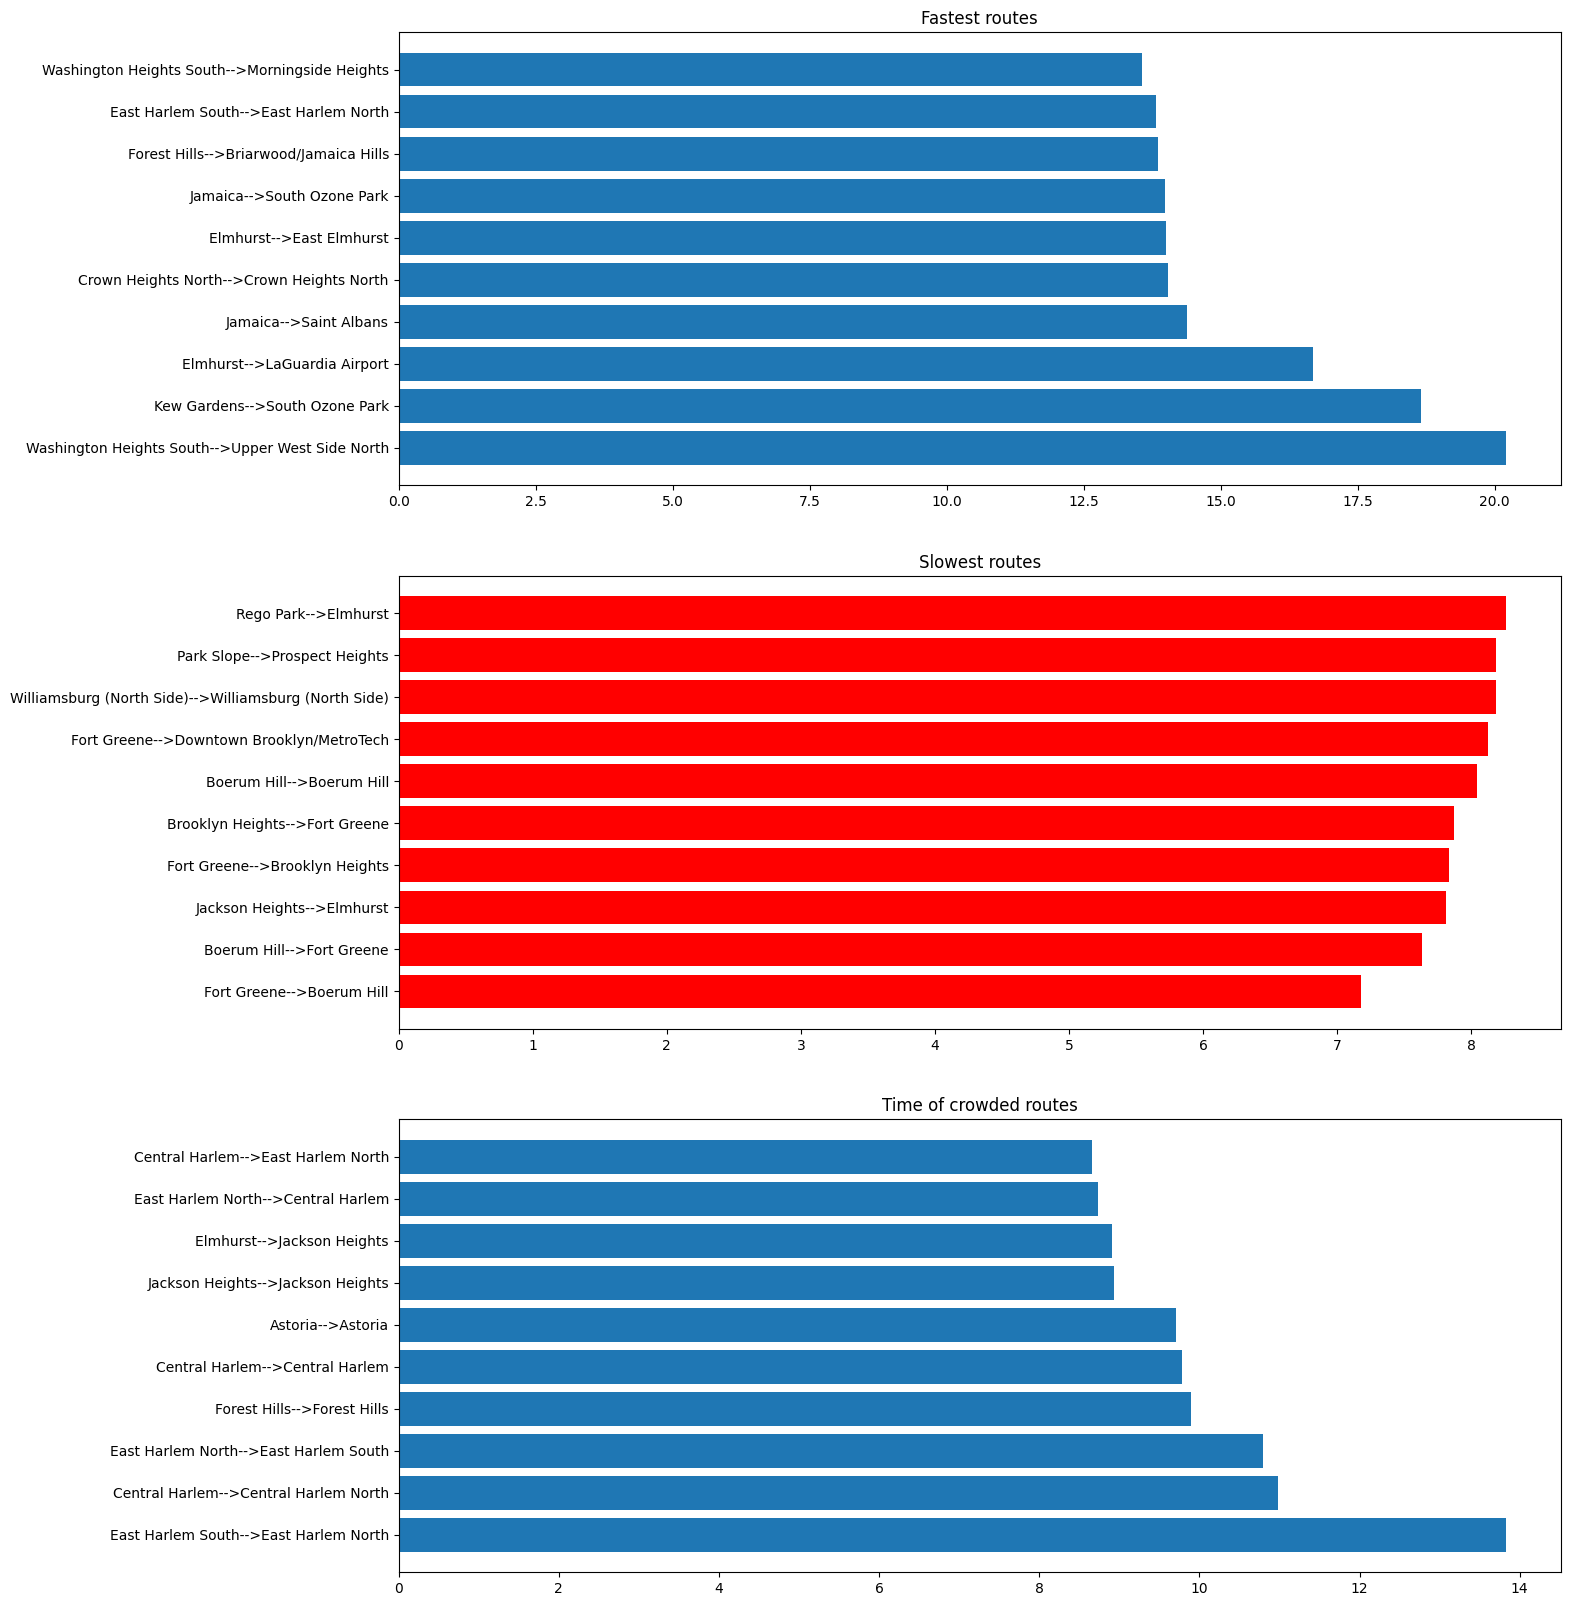

In [122]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,20))
ax1=ax[0];ax2=ax[1];ax3=ax[2]

ax1.set_title('Fastest routes')
ax1.barh(distance_fast['route'],width=distance_fast['mean'])

ax2.set_title('Slowest routes')
ax2.barh(distance_slow['route'],width=distance_slow['mean'],color='red')

ax3.set_title('Time of crowded routes')
ax3.barh(routes['route'],width=routes['mean']);

### **¿How changed the cost per mile in the different tariff?**
*The concentration of the majority of trips were in 'Standard Rate'. The highest cost was by the 'Standard Rate' with 7 dollars per mile, followed by 'Nassau or Westchester' with 4.8 dollars per mile, 'Negotiated fare' with 4.6 dollar per mile and finally 'JFK' with 4 dollars per mile.*

In [123]:
df_green=pd.merge(df_green,df_rate[['RateCodeID','RateCodeDesc']],how='inner',left_on='RatecodeID',right_on='RateCodeID')
df_green=df_green.drop(columns=['RateCodeID'])
df_green.head(3)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration,PULocation_borough,PULocation_zone,DOLocationID_borough,DOLocationID_zone,hours,miles_hour,RateCodeDesc
0,2.0,2019-01-01 00:44:28+00:00,2019-01-01 00:50:10+00:00,1,181,228,1,1.08,6.0,0.5,0.5,0.00,0.0,0.3,7.30,5,1,0.0,1,6,Brooklyn,Park Slope,Brooklyn,Sunset Park West,0,10.8,Standard Rate
1,2.0,2019-01-01 00:20:51+00:00,2019-01-01 00:29:36+00:00,1,41,74,1,0.93,7.0,0.5,0.5,0.00,0.0,0.3,8.30,5,1,NaN,1,9,Manhattan,Central Harlem,Manhattan,East Harlem North,0,6.2,Standard Rate
2,2.0,2019-01-01 00:10:00+00:00,2019-01-01 00:22:54+00:00,1,97,80,1,3.44,13.5,0.5,0.5,2.96,0.0,0.3,17.76,1,1,0.0,1,12,Brooklyn,Fort Greene,Brooklyn,East Williamsburg,0,17.2,Standard Rate


In [124]:
df_green['cost_per_mile']=df_green['total_amount']/df_green['trip_distance']

In [125]:
green_mile=df_green.loc[df_green['cost_per_mile']<50]

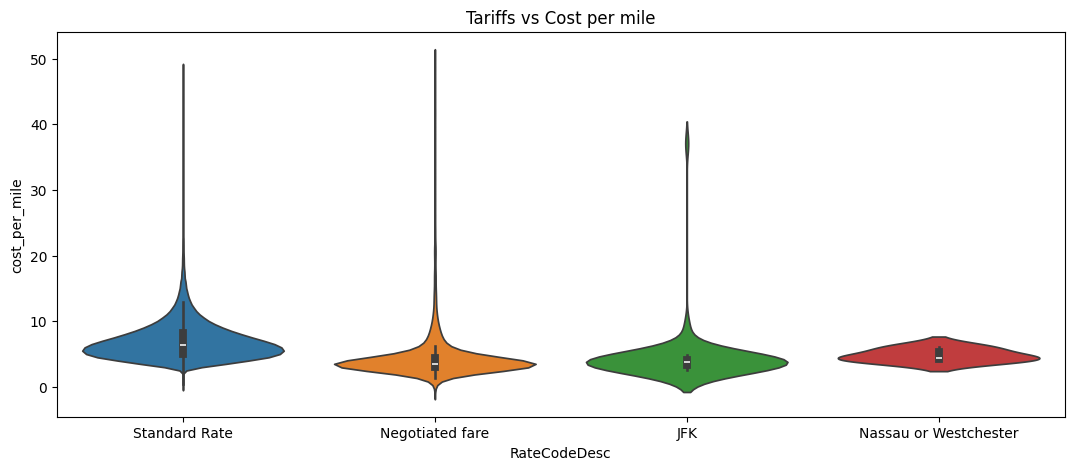

In [126]:
plt.figure(figsize=(13,5))
plt.title('Tariffs vs Cost per mile')
sns.violinplot(data=green_mile,x=green_mile['RateCodeDesc'].astype('str'),y='cost_per_mile',
               hue=green_mile['RateCodeDesc'].astype('str'));

In [127]:
display(Markdown("### The cost per mile in the different services"))
print(green_mile.groupby('RateCodeDesc')['cost_per_mile'].agg(['mean','median']))

### The cost per mile in the different services

                           mean    median
RateCodeDesc                             
JFK                    4.305185  3.778910
Nassau or Westchester  4.843792  4.469453
Negotiated fare        4.607761  3.510204
Standard Rate          7.037594  6.384615


### **¿What percentage of the total fare do tips represent?**
*The average percentage of the tip (card payment) is: 16.20%*

In [128]:

df_green['tip_percent'] = np.where(
    df_green['total_amount'] > 0,
    (df_green['tip_amount'] / df_green['total_amount']) * 100,
    0.0
)

df_card_trips = df_green[
    (df_green['payment_type'] == 1) & 
    (df_green['total_amount'] > 0)
]

promedio_propina = df_card_trips['tip_percent'].mean()
display(Markdown(f"#### The average percentage of the tip (card payment) is: *{promedio_propina:.2f}%*"))

#### The average percentage of the tip (card payment) is: *16.20%*

### **¿There are relationship in the time of the day or distance and the tips?**
- **Hour:** *Levels rose after 6:00 a.m. and stabilized at 10:00 a.m.; subsequently, they peaked at 12:00 a.m. and fell to a low at 6:00 a.m.*
- **Distance:** *Is the same situation of yellow taxis. Tips vary according to distance: they were higher for shorter distances and decreased as the distance increased.*

In [129]:

df_tips = df_green[
    (df_green['payment_type'] == 1) & 
    (df_green['fare_amount'] > 0) & 
    (df_green['trip_distance'] > 0) &
    (df_green['trip_distance'] <= 50) &
    (df_green['tip_percent'] <= 100)
].copy()

df_tips['pickup_hour'] = df_tips['lpep_pickup_datetime'].dt.hour

df_tips.head(5)

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,month,totalDuration,PULocation_borough,PULocation_zone,DOLocationID_borough,DOLocationID_zone,hours,miles_hour,RateCodeDesc,cost_per_mile,tip_percent,pickup_hour
2,2.0,2019-01-01 00:10:00+00:00,2019-01-01 00:22:54+00:00,1,97,80,1,3.44,13.5,0.5,0.5,2.96,0.0,0.3,17.76,1,1,0.0,1,12,Brooklyn,Fort Greene,Brooklyn,East Williamsburg,0,17.200000,Standard Rate,5.162791,16.666667,0
3,1.0,2019-01-01 00:48:22+00:00,2019-01-01 00:50:08+00:00,1,49,49,1,0.40,3.5,0.5,0.5,1.88,0.0,0.3,6.68,1,1,0.0,1,2,Brooklyn,Clinton Hill,Brooklyn,Clinton Hill,0,12.000000,Standard Rate,16.700000,28.143713,0
4,2.0,2019-01-01 01:53:22+00:00,2019-01-01 02:14:06+00:00,1,25,79,2,3.94,16.5,0.5,0.5,2.50,0.0,0.3,20.30,1,1,0.0,1,21,Brooklyn,Boerum Hill,Manhattan,East Village,1,11.257143,Standard Rate,5.152284,12.315271,1
5,2.0,2019-01-01 01:23:33+00:00,2019-01-01 01:36:44+00:00,1,146,223,1,1.53,10.0,0.5,0.5,2.26,0.0,0.3,13.56,1,1,0.0,1,13,Queens,Long Island City/Queens Plaza,Queens,Steinway,1,7.061538,Standard Rate,8.862745,16.666667,1
7,2.0,2019-01-01 01:06:35+00:00,2019-01-01 01:15:07+00:00,1,82,129,1,1.33,7.5,0.5,0.5,2.20,0.0,0.3,11.00,1,1,0.0,1,9,Queens,Elmhurst,Queens,Jackson Heights,1,8.866667,Standard Rate,8.270677,20.000000,1


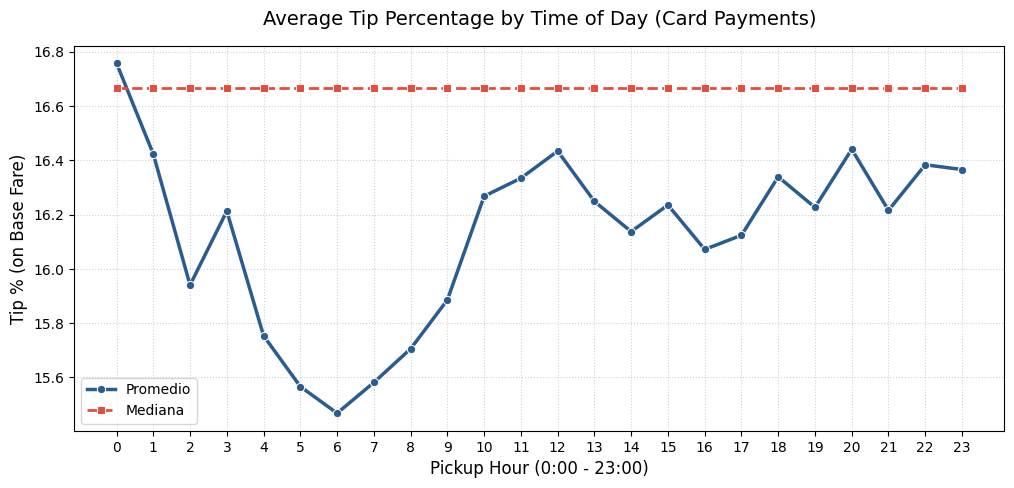

In [130]:

hourly_tips = df_tips.groupby('pickup_hour')['tip_percent'].agg(['mean', 'median', 'count']).reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_tips, x='pickup_hour', y='mean', marker='o', linewidth=2.5, color='#2b5c8f', label='Promedio')
sns.lineplot(data=hourly_tips, x='pickup_hour', y='median', marker='s', linewidth=2, color='#e74c3c', linestyle='--', label='Mediana')

plt.title('Average Tip Percentage by Time of Day (Card Payments)', fontsize=14, pad=15)
plt.xlabel('Pickup Hour (0:00 - 23:00)', fontsize=12)
plt.ylabel('Tip % (on Base Fare)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

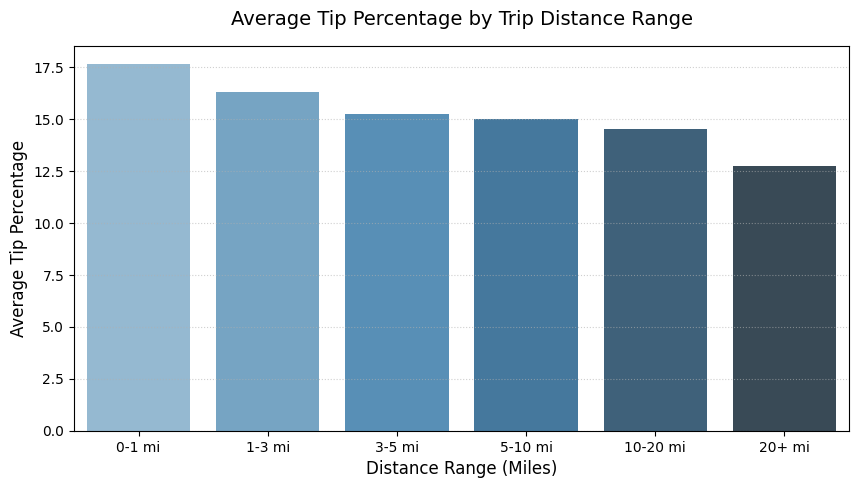

Pearson Correlation (Distance vs. Tip %): -0.1632
Spearman Correlation (Distance vs. Tip %): -0.2067


In [131]:

bins = [0, 1, 3, 5, 10, 20, 50]
labels = ['0-1 mi', '1-3 mi', '3-5 mi', '5-10 mi', '10-20 mi', '20+ mi']
df_tips['distance_group'] = pd.cut(df_tips['trip_distance'], bins=bins, labels=labels)

distance_tips = df_tips.groupby('distance_group', observed=False)['tip_percent'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=distance_tips, x='distance_group', y='mean', hue='distance_group',palette='Blues_d')

plt.title('Average Tip Percentage by Trip Distance Range', fontsize=14, pad=15)
plt.xlabel('Distance Range (Miles)', fontsize=12)
plt.ylabel('Average Tip Percentage', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

corr_pearson = df_tips['trip_distance'].corr(df_tips['tip_percent'], method='pearson')
corr_spearman = df_tips['trip_distance'].corr(df_tips['tip_percent'], method='spearman')

print(f"Pearson Correlation (Distance vs. Tip %): {corr_pearson:.4f}")
print(f"Spearman Correlation (Distance vs. Tip %): {corr_spearman:.4f}")

### **¿How influence the payment method in the tips?**
*The average tip in each trip was of 2.68 dollar. This is very similar to the case of yellow taxis that was of 3 dolar per trip.*

In [132]:
green_tip_amount=pd.merge(df_green,df_payment,
                        how='inner',on=['payment_type'])

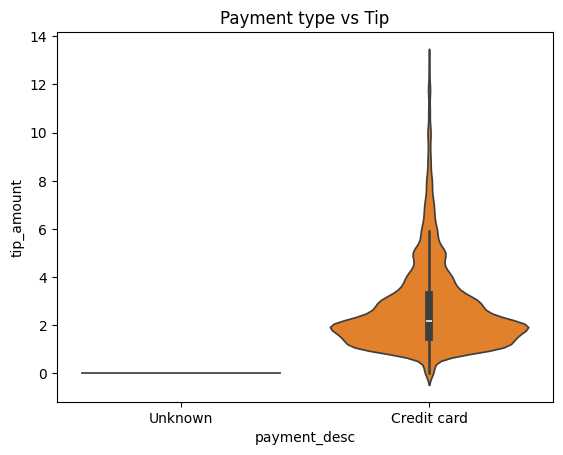

In [133]:
plt.title('Payment type vs Tip')
sns.violinplot(data=green_tip_amount,x='payment_desc',y='tip_amount',hue='payment_desc');

In [134]:
green_tip_amount.groupby('payment_desc')['tip_amount'].agg(['mean','median','count','sum'])


,mean,median,count,sum
payment_desc,,,,
Credit card,2.686824,2.15,21179,56904.24
Unknown,0.000000,0.00,33002,0.00


### **¿Which is the average cost per mile in the different services?**

In [135]:
display(Markdown(f"##### Mean: {df_yellow_total['totalDuration'].mean()}"))
display(Markdown(f"##### Meadian: {df_yellow_total['totalDuration'].median()}"))

##### Mean: 14.61390157606122

##### Meadian: 11.0

# **FHVHV TABLE ANALYSIS**

In [136]:
df_fhvhv.head(3)

,hvfhs_license_num,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag,month,totalDuration
0,HV0003,B02877,2019-10-01T00:44:38.000Z,2019-10-01T00:58:26.000Z,108,67,1.0,10,14
1,HV0003,B02682,2019-10-01T00:44:46.000Z,2019-10-01T01:09:23.000Z,100,257,NaN,10,25
2,HV0003,B02876,2019-10-01T00:37:44.000Z,2019-10-01T00:44:59.000Z,260,82,NaN,10,7


In [137]:
df_fhvhv['pickup_datetime']=pd.to_datetime(df_fhvhv['pickup_datetime'],format='mixed')
df_fhvhv['dropoff_datetime']=pd.to_datetime(df_fhvhv['dropoff_datetime'],format='mixed')

In [138]:
df_fhvhv.describe()

,PULocationID,DOLocationID,SR_Flag,month,totalDuration
count,2.346721e+06,2.346721e+06,399259.0,2.346721e+06,2.346721e+06
mean,1.387768e+02,1.415858e+02,1.0,6.974831e+00,1.924371e+01
std,7.512521e+01,7.757244e+01,0.0,3.187982e+00,1.396458e+01
min,1.000000e+00,1.000000e+00,1.0,2.000000e+00,1.000000e+00
25%,7.500000e+01,7.500000e+01,1.0,4.000000e+00,1.000000e+01
50%,1.400000e+02,1.410000e+02,1.0,7.000000e+00,1.600000e+01
75%,2.110000e+02,2.170000e+02,1.0,1.000000e+01,2.500000e+01
max,2.650000e+02,2.650000e+02,1.0,1.200000e+01,9.730000e+02


## **EXPLORATORY DATA ANALYSIS (EDA)**

In [139]:
df_fhvhv.isnull().sum()

hvfhs_license_num             0
dispatching_base_num         15
pickup_datetime               0
dropoff_datetime              0
PULocationID                  0
DOLocationID                  0
SR_Flag                 1947462
month                         0
totalDuration                 0
dtype: int64

In [140]:
df_fhvhv['sr_flag_clean']=df_fhvhv['SR_Flag'].fillna(0)

In [141]:
df_fhvhv['sr_flag_clean']=df_fhvhv['sr_flag_clean'].astype('int')

### ANALYZING FHVHV TABLE WITH AI

In [131]:
df_fhvhv_sample=df_fhvhv.sample(n=50)
df_fhvhv_dict=df_fhvhv_sample.to_dict(orient='records')
template=ChatPromptTemplate.from_messages([
    ("system","""You are an expert data scientist who analyzes charts and data frames professionally and analytically. You are concise in your answers and provide recommendations and your professional perspective."""),
    ("user","""Explain the dataset to me clearly and also tell me what mean all the columns. The dataset is: {dataset}""")
])
chain=template|llm
response=chain.invoke({"dataset":df_fhvhv_dict})
display(Markdown(response.content))

This dataset contains records of individual ride-sharing or for-hire vehicle trips, likely from a High Volume For-Hire Vehicle Service (HVFHS) in a specific geographical area (e.g., New York City). Each entry represents a single trip with details about the service provider, timing, locations, and ride type.

Here's a breakdown of each column:

*   **hvfhs_license_num**: A unique identifier for the High Volume For-Hire Vehicle Service (HVFHS) company or licensee that operated the trip.
*   **dispatching_base_num**: A unique identifier for the specific dispatching base or operational unit within the HVFHS company responsible for dispatching the vehicle for that trip.
*   **pickup_datetime**: The exact date and time (in UTC) when the passenger was picked up.
*   **dropoff_datetime**: The exact date and time (in UTC) when the passenger was dropped off.
*   **PULocationID**: Pickup Location ID. A numerical identifier corresponding to the geographical zone where the trip originated.
*   **DOLocationID**: Dropoff Location ID. A numerical identifier corresponding to the geographical zone where the trip concluded.
*   **SR_Flag**: Indicates whether the trip was a "Shared Ride". A value of `1.0` suggests a shared ride, while `nan` (Not a Number) likely indicates a non-shared ride or missing information.
*   **month**: The numerical month (1-12) in which the trip's pickup occurred, extracted from `pickup_datetime`.
*   **totalDuration**: The total duration of the trip in minutes, calculated from the difference between `dropoff_datetime` and `pickup_datetime`.
*   **sr_flag_clean**: A cleaned, binary version of `SR_Flag`. It appears to convert `nan` values to `0` (not shared) and `1.0` values to `1` (shared), providing a consistent indicator.

---

**Professional Perspective & Recommendations:**

This dataset is valuable for analyzing urban mobility patterns and the operations of HVFHS providers.

1.  **Geospatial Analysis:** To gain actionable insights, `PULocationID` and `DOLocationID` should be joined with a geographical lookup table (e.g., NYC Taxi Zone Shapefile) to identify actual neighborhoods, boroughs, or specific points of interest. This would enable heatmaps of demand, popular routes, and service area analysis.
2.  **Time-Series Insights:** Leverage `pickup_datetime` to extract more granular time features like day of the week, hour of the day, or even holidays. This can reveal peak demand periods, traffic congestion patterns, and seasonal trends.
3.  **Operational Efficiency:** Analyze `totalDuration` in conjunction with distance (if available) to assess trip efficiency, driver performance, and potential routing optimizations.
4.  **Shared Ride Impact:** Investigate the `sr_flag_clean` column to understand the prevalence of shared rides, their typical durations, and their impact on efficiency, pricing, or customer experience.
5.  **Provider Performance:** Compare `totalDuration` and trip volumes across different `hvfhs_license_num` and `dispatching_base_num` to benchmark performance and identify operational strengths or weaknesses.
6.  **Data Quality:** The `SR_Flag` and `sr_flag_clean` columns highlight a common data cleaning step. It's crucial to confirm that `nan` in `SR_Flag` unequivocally means "not a shared ride" for accurate analysis.

### **UNIVARIABLE GRAPHS**

In [142]:
print(df_fhvhv['pickup_datetime'].dt.month_name().value_counts())
print()
print(df_fhvhv['pickup_datetime'].dt.day_name().value_counts())
print()
print(df_fhvhv['PULocationID'].value_counts().head(10))
print()
print(df_fhvhv['sr_flag_clean'].value_counts())

pickup_datetime
March        239145
May          223817
December     222337
April        216766
November     216431
October      211688
June         210093
July         203434
February     201654
August       201375
September    199981
Name: count, dtype: int64

pickup_datetime
Saturday     397943
Friday       365993
Sunday       352162
Thursday     327546
Wednesday    308754
Tuesday      301989
Monday       292334
Name: count, dtype: int64

PULocationID
138    39982
79     38803
132    36233
61     33782
234    30552
161    29497
231    28562
230    27540
148    27112
48     27072
Name: count, dtype: int64

sr_flag_clean
0    1947462
1     399259
Name: count, dtype: int64


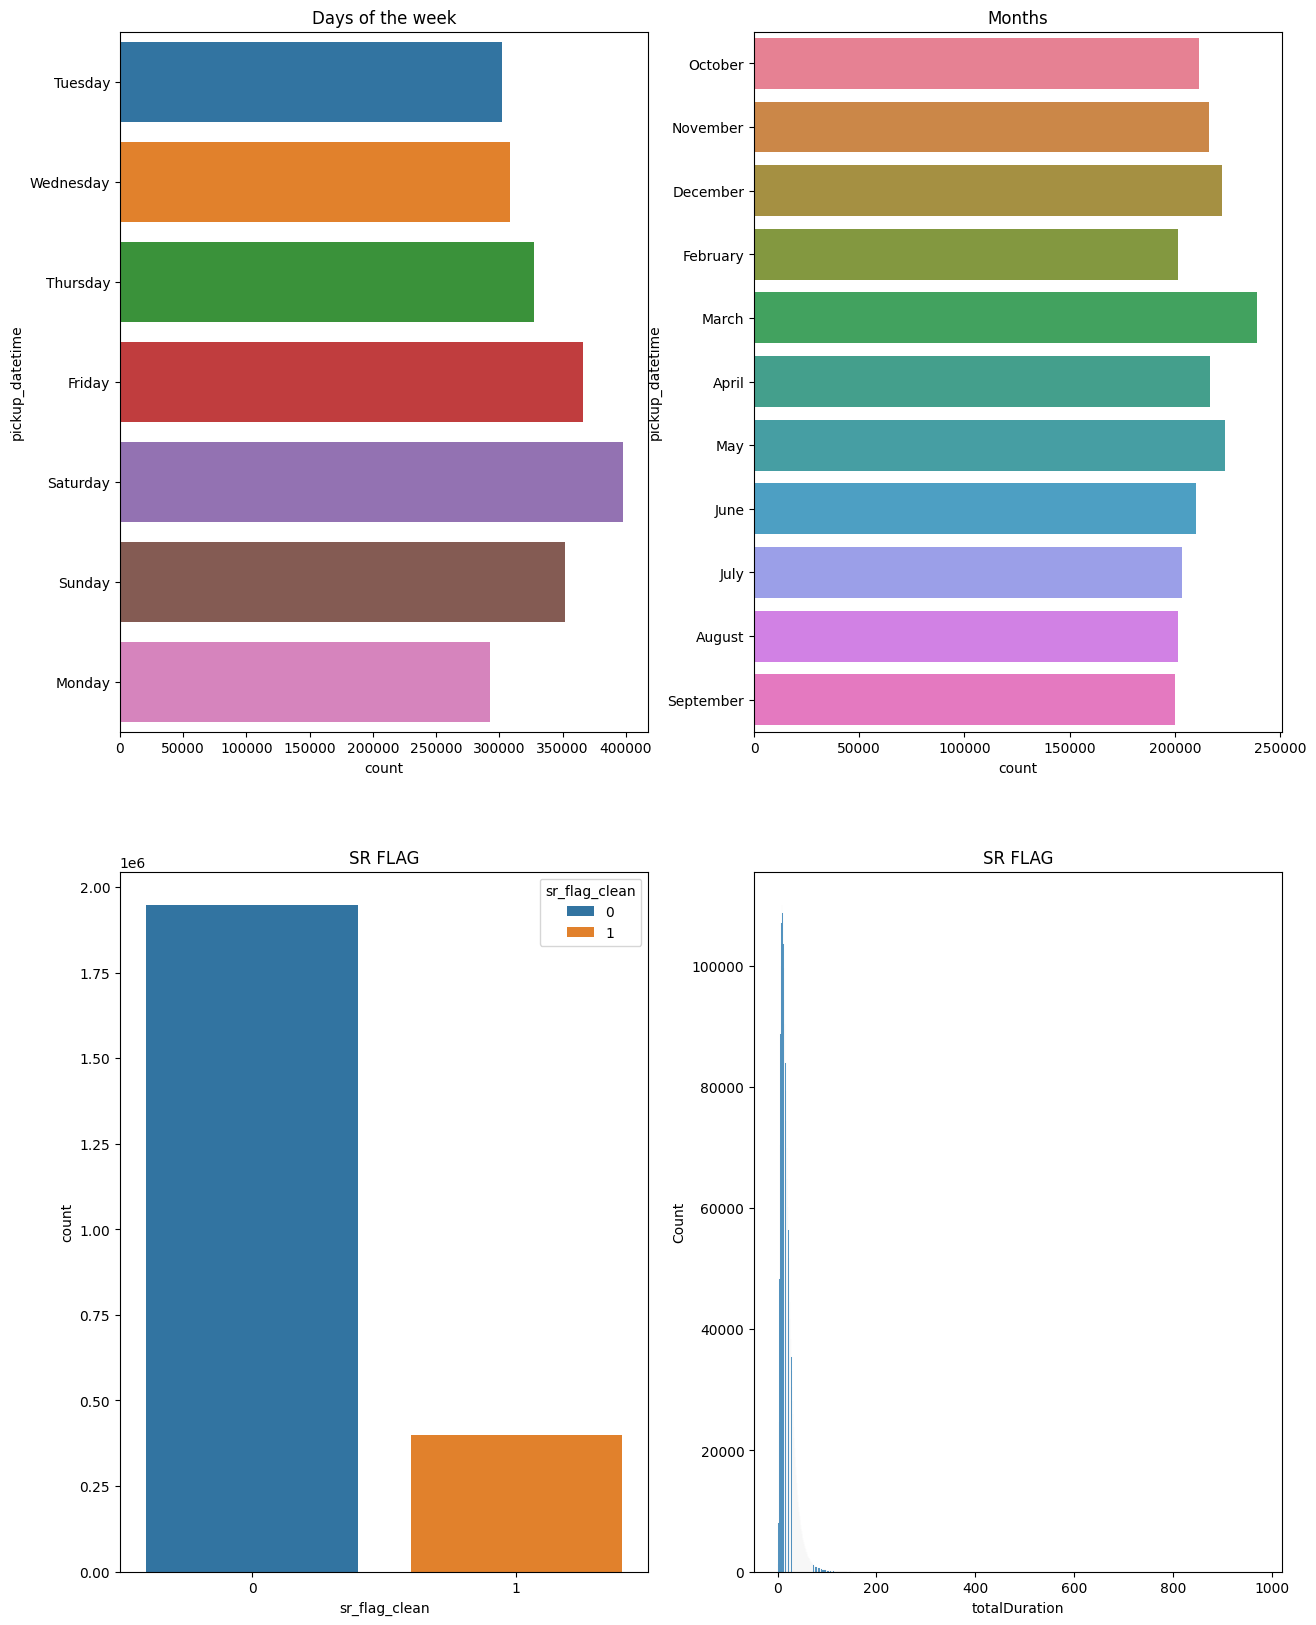

In [143]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(15,20))
ax1=ax[0,0];ax2=ax[0,1];ax3=ax[1,0];ax4=ax[1,1]

ax1.set_title('Days of the week')
sns.countplot(data=df_fhvhv,y=df_fhvhv['pickup_datetime'].dt.day_name(),hue=df_fhvhv['pickup_datetime'].dt.day_name(),ax=ax1)

ax2.set_title('Months')
sns.countplot(data=df_fhvhv,y=df_fhvhv['pickup_datetime'].dt.month_name(),hue=df_fhvhv['pickup_datetime'].dt.month_name(),ax=ax2)

ax3.set_title('SR FLAG')
sns.countplot(data=df_fhvhv,x='sr_flag_clean',hue='sr_flag_clean',ax=ax3)

ax4.set_title('SR FLAG')
sns.histplot(data=df_fhvhv,x='totalDuration',ax=ax4);

In [144]:
len(df_fhvhv.loc[df_fhvhv['totalDuration']>180])
df_fhvhv=df_fhvhv.loc[df_fhvhv['totalDuration']<180]

### **¿How is distributed the total volume of trips by hour and what days has the highest volume of trips in comparison with yellow table?**
- **Days:** *A difference to yellow table where the highest volume of trips were laboral days, here the highest volume of trips were the weekends (Saturday,Sunday and Friday).*
- **Hours:** *The volume of trips by the hour was the same in the three tables (yellow,green and fhvhv). The highest concentration in this case was between 15-20 hours (3-8PM) with the peak at 6PM.*

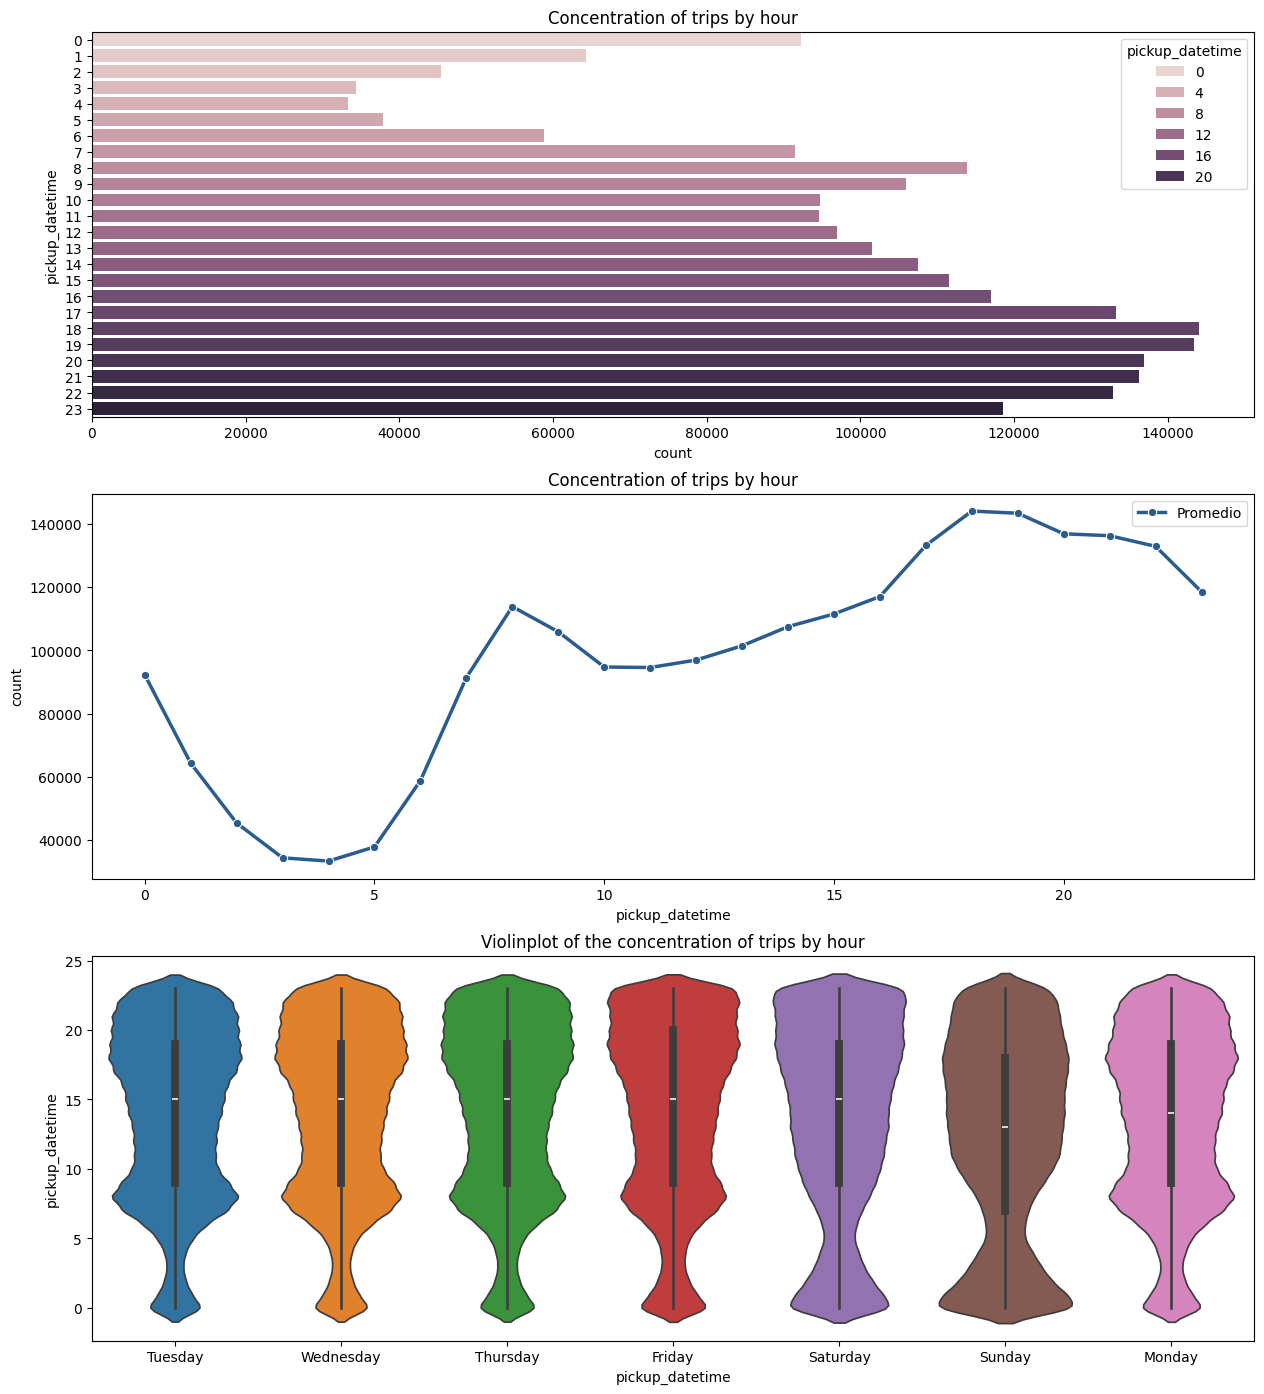

In [145]:
fig,ax=plt.subplots(nrows=3,ncols=1,figsize=(15,17))
ax1=ax[0];ax2=ax[1];ax3=ax[2]
ax1.set_title('Concentration of trips by hour')
sns.countplot(data=df_fhvhv,y=df_fhvhv['pickup_datetime'].dt.hour,hue=df_fhvhv['pickup_datetime'].dt.hour,ax=ax1)

ax2.set_title('Concentration of trips by hour')
hours=df_fhvhv['pickup_datetime'].dt.hour.value_counts().sort_index().reset_index()
sns.lineplot(data=hours, x='pickup_datetime', y='count', marker='o', linewidth=2.5, color='#2b5c8f', label='Promedio',ax=ax2);

ax3.set_title('Violinplot of the concentration of trips by hour')
sns.violinplot(data=df_fhvhv,x=df_fhvhv['pickup_datetime'].dt.day_name(),
               y=df_fhvhv['pickup_datetime'].dt.hour,hue=df_fhvhv['pickup_datetime'].dt.day_name(),ax=ax3);

### **¿Which are the 10 most concurred routes? and ¿Which routes had the most heavy traffic?**
- **Crowded rotes:** *The crowded routes (with more traffic) were 'East New York to East New York', followed by 'Borough Park to Borough Park','Canarsie to Canarsie'.*

In [146]:
df_taxizone.head(3)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone


In [147]:
df_fhvhv=pd.merge(df_fhvhv,df_taxizone[['LocationID','Zone','Borough']],how='inner',
                  left_on='PULocationID',right_on='LocationID').rename(columns={'Zone':'Zone_pul','Borough':'Borough_pul'})
df_fhvhv=df_fhvhv.drop(columns=['LocationID'])
df_fhvhv.head(3)

,hvfhs_license_num,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag,month,totalDuration,sr_flag_clean,Zone_pul,Borough_pul
0,HV0003,B02877,2019-10-01 00:44:38+00:00,2019-10-01 00:58:26+00:00,108,67,1.0,10,14,1,Gravesend,Brooklyn
1,HV0003,B02682,2019-10-01 00:44:46+00:00,2019-10-01 01:09:23+00:00,100,257,NaN,10,25,0,Garment District,Manhattan
2,HV0003,B02876,2019-10-01 00:37:44+00:00,2019-10-01 00:44:59+00:00,260,82,NaN,10,7,0,Woodside,Queens


In [148]:
df_fhvhv=pd.merge(df_fhvhv,df_taxizone[['LocationID','Zone','Borough']],how='inner',
                  left_on='DOLocationID',right_on='LocationID').rename(columns={'Zone':'Zone_dol','Borough':'Borough_dol'})
df_fhvhv=df_fhvhv.drop(columns=['LocationID'])
df_fhvhv.head(3)

,hvfhs_license_num,dispatching_base_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,SR_Flag,month,totalDuration,sr_flag_clean,Zone_pul,Borough_pul,Zone_dol,Borough_dol
0,HV0003,B02877,2019-10-01 00:44:38+00:00,2019-10-01 00:58:26+00:00,108,67,1.0,10,14,1,Gravesend,Brooklyn,Dyker Heights,Brooklyn
1,HV0003,B02682,2019-10-01 00:44:46+00:00,2019-10-01 01:09:23+00:00,100,257,NaN,10,25,0,Garment District,Manhattan,Windsor Terrace,Brooklyn
2,HV0003,B02876,2019-10-01 00:37:44+00:00,2019-10-01 00:44:59+00:00,260,82,NaN,10,7,0,Woodside,Queens,Elmhurst,Queens


In [149]:
routes=df_fhvhv[['Zone_pul','Zone_dol']].value_counts().head(10).reset_index()
routes['route']=routes['Zone_pul'] + '-->' + routes['Zone_dol']
routes

,Zone_pul,Zone_dol,count,route
0,East New York,East New York,5918,East New York-->East New York
1,Borough Park,Borough Park,4142,Borough Park-->Borough Park
2,Canarsie,Canarsie,4080,Canarsie-->Canarsie
3,Crown Heights North,Crown Heights North,3948,Crown Heights North-->Crown Heights North
4,Jackson Heights,Jackson Heights,3187,Jackson Heights-->Jackson Heights
5,Bay Ridge,Bay Ridge,3063,Bay Ridge-->Bay Ridge
6,Astoria,Astoria,3021,Astoria-->Astoria
7,Park Slope,Park Slope,2788,Park Slope-->Park Slope
8,Bushwick South,Bushwick South,2579,Bushwick South-->Bushwick South
9,Bushwick South,Bushwick North,2338,Bushwick South-->Bushwick North


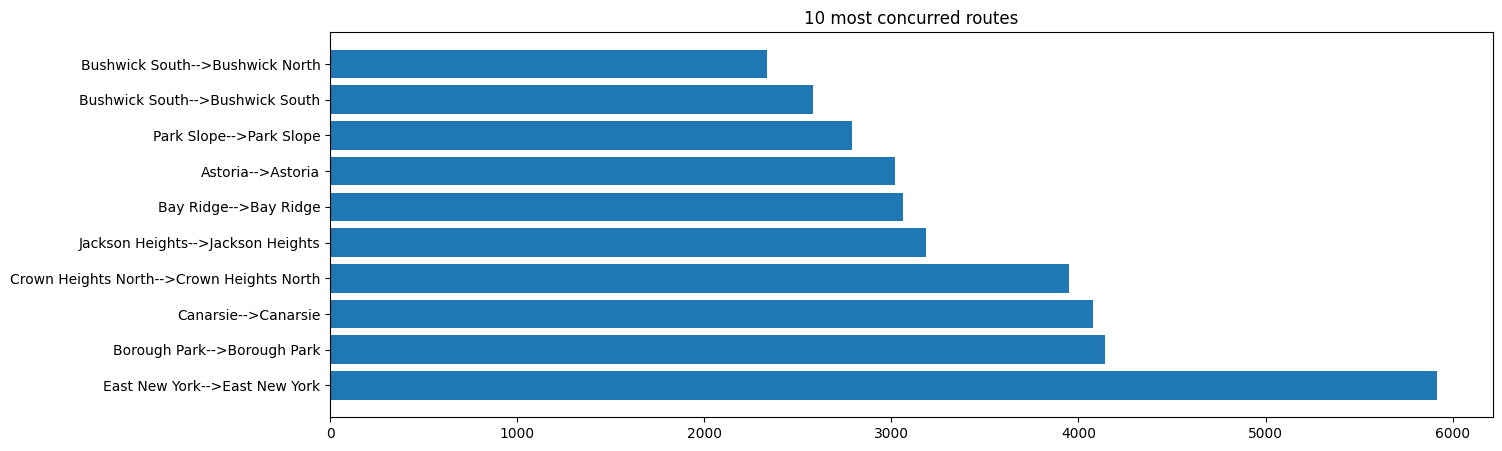

In [150]:
plt.figure(figsize=(15,5))
plt.title('10 most concurred routes')
plt.barh(routes['route'],width=routes['count']);

### **Percentage of the total trips in the different Boroughs**
*The distribution of the trips is very similar to green table because they not only priorize Manhattan over the other boroughs. In this case the 43% was realized in Manhattan, 26% in Brooklyn, 18% in Queens, 11% in Bronx. The other rest of boroughs were irrelevant.*

In [151]:

viajes_por_borough = df_fhvhv['Borough_pul'].value_counts().reset_index()
viajes_por_borough.columns = ['Borough', 'total_viajes_fhvhv']

total_viajes_global = len(df_fhvhv)
viajes_por_borough['porcentaje_del_total_fhvhv'] = (
    (viajes_por_borough['total_viajes_fhvhv'] / total_viajes_global) * 100
).round(2)

print(viajes_por_borough)

         Borough  total_viajes_fhvhv  porcentaje_del_total_fhvhv
0      Manhattan             1013031                       43.17
1       Brooklyn              618397                       26.35
2         Queens              425429                       18.13
3          Bronx              263500                       11.23
4  Staten Island               25909                        1.10
5        Unknown                 131                        0.01
6            EWR                 108                        0.00


### **¿What is the average waiting time of the user and the average duration of the trip?**

In [152]:
route_time=(df_fhvhv.groupby(['Zone_pul','Zone_dol'])['totalDuration']
    .agg(['mean','median','count']).sort_values('mean',ascending=False).reset_index())
route_time.head(5)

,Zone_pul,Zone_dol,mean,median,count
0,Brooklyn Navy Yard,Arrochar/Fort Wadsworth,174.0,174.0,1
1,Homecrest,Norwood,167.0,167.0,1
2,Financial District South,Springfield Gardens South,156.0,156.0,1
3,Brownsville,Bloomfield/Emerson Hill,150.0,150.0,1
4,Borough Park,Co-Op City,141.0,141.0,1


In [153]:
route_time['route']=route_time['Zone_pul']+'-->'+route_time['Zone_dol']
route_time.head(3)

,Zone_pul,Zone_dol,mean,median,count,route
0,Brooklyn Navy Yard,Arrochar/Fort Wadsworth,174.0,174.0,1,Brooklyn Navy Yard-->Arrochar/Fort Wadsworth
1,Homecrest,Norwood,167.0,167.0,1,Homecrest-->Norwood
2,Financial District South,Springfield Gardens South,156.0,156.0,1,Financial District South-->Springfield Gardens...


In [154]:
# AVERAGE TIME OF THE MOST POPULAR ROUTES
route_popular=route_time.sort_values('count',ascending=False).head(10).sort_values('mean',ascending=False)

In [155]:
# SLOWEST ROUTES OF THE DATASET
route_time_slow=route_time.head(10)

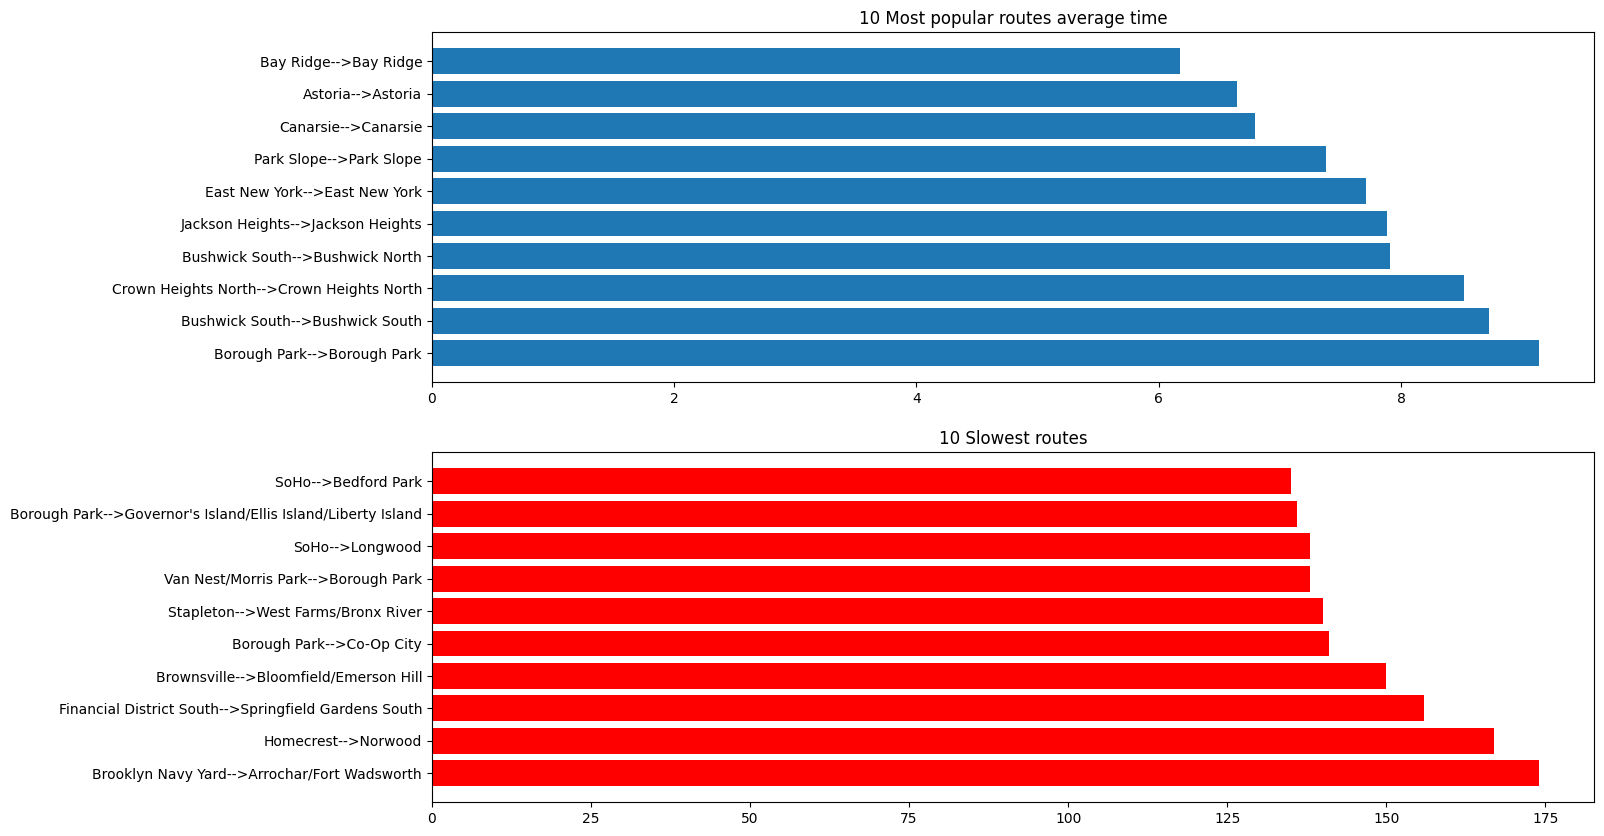

In [156]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(15,10))
ax1=ax[0];ax2=ax[1]

ax1.set_title('10 Most popular routes average time')
ax1.barh(route_popular['route'],width=route_popular['mean'])

ax2.set_title('10 Slowest routes')
ax2.barh(route_time_slow['route'],width=route_time_slow['mean'],color='red');

In [157]:

display(Markdown("#### **AVERAGE TIME OF ALL THE DATA**"))
display(Markdown(f"##### Mean: {df_fhvhv['totalDuration'].mean()}"))
display(Markdown(f"##### Meadian: {df_fhvhv['totalDuration'].median()}"))

#### **AVERAGE TIME OF ALL THE DATA**

##### Mean: 19.21933854818123

##### Meadian: 16.0

# **Insights**
### A. Market Segmentation: Business vs. Leisure
There is a clear divide in user behavior based on the type of service:
- ***Traditional Taxis (Yellow/Green) = Work-Oriented:*** Demand peaks mid-week (Wednesdays and Thursdays), indicating they are primarily used for business trips, office commutes, and work-related routines.
- ***Apps (FHVHV) = Social and Residential Focus:*** Demand surges on weekends (Saturdays and Sundays). This demonstrates that Uber and Lyft dominate the market for nightlife, social events, and leisure-time mobility.

### B. Geography and the "Battle" for the Outer Boroughs
The city does not move uniformly; services have carved out distinct territories:
- ***The Manhattan Monopoly:*** Yellow taxis are almost exclusive to Manhattan (concentrating 91% of their trips there), serving as hyper-local transport for the financial and commercial hub.
- ***The Democratization of Transport:*** Apps (FHVs) achieved what traditional taxis could not: connecting the outer boroughs. FHVs have a strong presence in Brooklyn (26%) and dominate the Bronx (11%), outperforming Green Taxis (5%)—which were specifically created to serve those areas.
- ***The Green Niche:*** Green Taxis have found their niche in the areas bordering Manhattan (such as Harlem) and specific parts of Queens (29%) and Brooklyn (27%), acting as a bridge between the city core and the outer areas.

### C. Trip Economics and User Behavior
Fares and tips reveal how users perceive the value of the service:
- ***Yellow Taxi is a "Premium" service based on convenience:*** It is the most expensive option (9 per mile standard fare vs. 7 for Green Taxis). Its high cost is justified by immediate availability in the city's densest area. Tipping Psychology (The distance effect): Riders tend to be more generous (in percentage terms) on short trips, with the tip proportion decreasing as the trip gets longer. Time of day also plays a role: tips drop during the early morning hours (before 6 AM), yet Green Taxis see an unusual spike in generous tips at midnight.
- ***Card Payment Equity:*** Despite differences in fares, when riders pay by card, the average tip amount standardizes to around $3 per trip for both Yellow and Green Taxis.

### D. Efficiency and Congestion
- ***Traffic affects everyone equally, though in different areas:*** Yellow Taxis suffer from extreme congestion in Manhattan (speeds of 8.8 to 12.5 mph). However, Green Taxis face even slower traffic (7 to 7.8 mph) on dense local routes in Brooklyn and Queens (e.g., Fort Greene and Jackson Heights), dispelling the myth that only Manhattan suffers from severe traffic flow issues.
- ***Trip Times:*** App-based service (FHV) users experience longer average trip durations (19 minutes) compared to traditional taxis (14 minutes); this makes sense, given that app-based services often handle longer, inter-borough trips.

# **SUMMARY**
**¿Which are the hours and days of the week with more trips?**\
Yellow and Green taxis have the highest concentration of trips on the laboral days like Thursday and Wednesday. But the situation is different in the case of FHVHV table because weekends have more concentration of trips like Saturday and Sunday. In the case of the hours there were more concentration of trips between 3-8PM in all the tables, and there were more concentration of trips early in the morning the weekends instead laboral days.

**Which were the seasons or months of the year where there were more trips?**\
There were a differences between yellow, green and fhvhv table. In the case of yellow there were more concentration of trips on March, May and April. In the case of Green table were January, March and Februrary.On the other hand, fhvhv table were March,May and December the months with more trips. In general, the concentration of trips were between Februaryh to May. there were more trips in all the tables.

**¿Which are the 10 origin zones and destinations with more trips?**\
The origin pickup zones are different in each case, for example, in yellow taxis the three origin locations with more trips were 'East Side South', 'Midtown Center' and 'Upper East Side North' that correspond to Manhattan borough. In the case of green taxis were 'East Harlem North', 'East Harlem South' and 'Central Harlem'.\
In the case of dropoff locations in yellow taxis were 'Upper East Side North', 'Midtown Center' and 'Upper East Side South'. In green taxis were 'East Harlem North','Central Harlem North' and 'Central Harlem'. That cases were in Manhattan borough, yellow and green taxis had more presence in Manhattan.\
The concentration of trips in the boroughts are different in the tables, for example, almost all the journeys that made it the yellow taxis were in Manhattan borough and a few in the rest of boroughs. But the in the case of fhvhv and green tables the concentration was distribuited in the other boroughs and not only in Manhattan, for example in Bronx and Queens. This makes sense because fhvhv and green table are for bring service to others boroughs and not only in Manhattan like yellow taxis.

**¿Which routes had the most heavy traffic?**\
The 3 slowest routes (with more traffic) in the case of yellow taxis were 'Central Harlem North' to 'Manhattanville' with 8.8 miles/hour, followed by 'Garment District' to 'Stuy Town/Peter Cooper Village' with 9 miles/hour,'East Village' to 'Downtown Brooklyn/MetroTech' with 12.5 miles/hour.For that data it was taken into consideration routes that had more than 50 trips. The slowest routes in the case of the green taxis were 'Fort Greene to Boerum Hill' with 7 miles/hour,'Boerum Hill to Fort Greene' with 7.6 miles/hour and 'Jackson Heights to Elmhurst' with 7.8 miles/hour.

**¿How changed the cost per mile in the different tariff?**\
In the case of yellow taxis the concentration of the majority of trips were in 'Standard Rate'. The highest cost was by the 'Standard Rate' with 9 dollars per mile, followed by 'Newark' with 5.7 dollars per mile, 'Negotiated fare' with 5 dollar per mile, 'Nassau or Westchester' with 4.6 dollars per mile and finally 'JFK' with 4 dollars per mile.\
In the case of green taxis the concentration of the majority of trips were in 'Standard Rate'. The highest cost was by the 'Standard Rate' with 7 dollars per mile, followed by 'Nassau or Westchester' with 4.8 dollars per mile, 'Negotiated fare' with 4.6 dollar per mile and finally 'JFK' with 4 dollars per mile.\
This means that in general yellow taxis had more expensive tariffs in comparison with green taxis.

**¿What percentage of the total amount represent the tips?**\
In the case of yellow taxis the average percentage of the tip (card payment) is 14.99% and in the case of green taxis was 16.20%. This mean that the green taxi users give a little bit more tips.

**¿There are relationship in the time of the day or distance and the tips?**
- **Hour:** In both cases of yellow and green taxis there was relationship between the time of the day and tips. In the case of yellow taxis, early in the morning, like before at 6am, the tips were more lower than after 6am and the tips stabilized starting at 10 a.m. On the other hand, green taxis levels rose after 6:00 a.m. and stabilized at 10:00 a.m.; subsequently, they peaked at 12:00 a.m. and fell to a low at 6:00 a.m.
- **Distance:** In both cases (green and yellow taxis) the tips vary according to distance: they were higher for shorter distances and decreased as the distance increased.


**¿How influence the payment method in the tips?**\
Green and Yellow taxis had similar tips in their payment method 'credit card', and was around 3 dollar per trip.

**Percentage of the total trips in the different Boroughs**\
The distribution of trips is very similar between green and fhvhv taxis because they not only priorize Manhattan over the other boroughs. In the case of fhvhv taxis the 43% was realized in Manhattan, 26% in Brooklyn, 18% in Queens, 11% in Bronx.\
In the case of green taxis 36% was realized in Manhattan,29% in Queens, 27% in Brooklyn and only 5% in Bronx. We can see that fhvhv taxis had more presence in Bronx than green taxis.\
Almost all the trips of Yellow taxis were in Manhattan with 91% of the trips realized in that borough, followed by Queens with only 6%.


**¿What is the average waiting time of the user and the average duration of the trip?**\
The average time is different between yellow-green taxis vs fhvhv taxis. Yellow and green had similar waiting time like 14 min, while fhvhv taxis had 19 min.